## Step 1: Import Libraries and Configuration


In [1]:
# Import essential libraries and packages for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, RobustScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    RandomizedSearchCV, learning_curve
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
import warnings

warnings.filterwarnings('ignore')

# Analysis tools
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import itertools

# Add imports for file downloading
import requests
import os
from pathlib import Path

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [2]:
# Configuration for professional presentation
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

# Set personalized random seed
# TODO: Replace XX with the last 2 digits of YOUR student ID
STUDENT_SEED = 18  # Example: Replace with your actual student ID last 2 digits
np.random.seed(STUDENT_SEED)

print(f"✓ Configuration set successfully!")
print(f"Random seed: {STUDENT_SEED}")


✓ Configuration set successfully!
Random seed: 18


# PART 1: ENERGY EFFICIENCY ANALYSIS


## Step 2: Energy Dataset - Download Function


In [3]:
def download_file(url, local_filename):
    """Download file from URL to local directory if it doesn't exist"""
    if not os.path.exists(local_filename):
        print(f"Downloading {local_filename} from {url}...")
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()

            with open(local_filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"✓ File downloaded successfully: {local_filename}")
            return True
        except Exception as e:
            print(f"✗ Error downloading file: {e}")
            return False
    else:
        print(f"✓ File already exists locally: {local_filename}")
        return True


print("✓ Download function defined")


✓ Download function defined


## Step 3: Energy Dataset - Load Data


In [4]:
print("=" * 60)
print("PART 1: ENERGY EFFICIENCY ANALYSIS")
print("=" * 60)

# Load Energy Efficiency Dataset with download functionality
print("Loading Energy Efficiency Dataset...")

# Define the URL and local file path
energy_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx'
energy_local_file = 'ENB2012_data.xlsx'

# Try to download and read the energy dataset
try:
    download_success = download_file(energy_url, energy_local_file)

    if download_success and os.path.exists(energy_local_file):
        energy_df = pd.read_excel(energy_local_file)
        print(f"✓ Dataset loaded from local file! Shape: {energy_df.shape}")
    else:
        print("Trying direct URL reading as fallback...")
        energy_df = pd.read_excel(energy_url)
        print(f"✓ Dataset loaded from URL! Shape: {energy_df.shape}")

except Exception as e:
    print(f"✗ Error loading dataset: {e}")
    print("Please ensure you have internet connection or the file is available locally")


PART 1: ENERGY EFFICIENCY ANALYSIS
Loading Energy Efficiency Dataset...
✓ File already exists locally: ENB2012_data.xlsx
✓ Dataset loaded from local file! Shape: (768, 10)


## Step 4: Energy Dataset - Basic Information


In [5]:
# Rename columns to descriptive names
energy_df.rename(columns={
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}, inplace=True)

print("Dataset Info:")
print(energy_df.info())
print("\nFirst 5 rows:")
print(energy_df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB
None

First 5 rows:
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25

## Step 5: Energy Dataset - Target Correlation Analysis


In [6]:
"""
UNDERSTANDING P-VALUE - A DETAILED EXPLANATION:

The p-value is one of the most misunderstood concepts in statistics. Let's break it down:

1. CORRELATION COEFFICIENT (r):
   - Measures LINEAR relationship strength between two variables
   - Range: -1 to +1
   - r = +1: Perfect positive correlation
   - r = 0:  No linear relationship
   - r = -1: Perfect negative correlation
   - |r| > 0.7: Strong correlation
   - 0.3 < |r| < 0.7: Moderate correlation
   - |r| < 0.3: Weak correlation

2. P-VALUE:
   - Probability of observing this correlation (or stronger) by random chance
   - Tests null hypothesis: "No correlation exists (r = 0)"
   - p < 0.05: Statistically significant (reject null hypothesis)
   - p < 0.001: Highly significant
   - p = 0.0000: Extremely significant (actual value < 0.0001)
"""

# Analyze the dual-target nature: Compute correlation between Heating_Load and Cooling_Load
corr, p_value = pearsonr(energy_df['Heating_Load'], energy_df['Cooling_Load'])

print("=" * 80)
print("🔍 DETAILED P-VALUE EXPLANATION WITH OUR DATA")
print("=" * 80)

print(f"📊 Correlation Coefficient (r): {corr:.4f}")
print(f"🎯 P-value: {p_value:.10f}")

print(f"\n🤔 WHAT DOES P-VALUE = {p_value:.10f} MEAN?")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

if p_value < 0.0001:
    print(f"🎲 LOTTERY ANALOGY:")
    print(f"   Imagine buying a lottery ticket with 1 in 10,000+ chance of winning")
    print(f"   P-value ≈ 0.0000 means finding this correlation by random chance")
    print(f"   is like winning that lottery - technically possible but extremely unlikely!")

    print(f"\n🔬 SCIENTIFIC INTERPRETATION:")
    print(f"   If we repeated this experiment 10,000 times with truly unrelated variables,")
    print(f"   we'd expect to see correlation ≥ {corr:.4f} in fewer than 1 trial.")

    print(f"\n💡 PLAIN ENGLISH:")
    print(f"   'There's virtually ZERO chance this strong correlation happened by accident.'")
    print(f"   'We can be 99.99%+ confident that heating and cooling loads are truly related.'")

elif p_value < 0.001:
    print(f"   Very strong evidence against random chance")
elif p_value < 0.05:
    print(f"   Strong evidence against random chance")
else:
    print(f"   Weak evidence - could be random")

print(f"\n🎯 NULL HYPOTHESIS TESTING:")
print(f"   Null Hypothesis (H₀): 'Heating and cooling loads are NOT related (r = 0)'")
print(f"   Alternative Hypothesis (H₁): 'Heating and cooling loads ARE related (r ≠ 0)'")
print(f"   ")
print(f"   With p-value ≈ 0.0000:")
print(f"   🚫 REJECT H₀: We have overwhelming evidence to reject the null hypothesis")
print(f"   ✅ ACCEPT H₁: The relationship is statistically significant")

print(f"\n📈 REAL-WORLD IMPLICATIONS:")
print(f"   • This isn't just a number - it has practical meaning!")
print(f"   • We can confidently use one load type to predict the other")
print(f"   • Building designers can focus on factors affecting both loads simultaneously")
print(f"   • The relationship is so strong it's almost like a physical law for this dataset")

# Visual demonstration of what p-value means
print(f"\n🎨 VISUAL ANALOGY:")
print(f"   Imagine plotting 10,000 pairs of truly random, unrelated numbers:")
print(f"   📉📊📈📉📊 (most correlations would be near 0)")
print(f"   🎯 Our correlation of {corr:.4f} would be so extreme it would appear")
print(f"   🌟 less than once in those 10,000 random trials!")

# Sample size consideration
n_samples = len(energy_df)
print(f"\n📊 SAMPLE SIZE CONTEXT:")
print(f"   Sample size (n) = {n_samples}")
print(f"   Larger samples make p-values more reliable")
print(f"   With {n_samples} data points, our p-value calculation is very trustworthy")

# Practical vs Statistical significance
print(f"\n⚖️  STATISTICAL vs PRACTICAL SIGNIFICANCE:")
print(f"   📊 Statistical significance: p ≈ 0.0000 (✅ Very significant)")
print(f"   🏠 Practical significance: r = {corr:.4f} (✅ Very strong relationship)")
print(f"   🎯 Both agree: This is a meaningful, reliable relationship!")

# 4. Check for missing values (df.isnull().sum()), duplicates (df.duplicated().sum()), and data quality issues (e.g., negative values where impossible)

# Data Quality Checks
print("\n--- Data Quality Analysis ---")
print(f"Missing values:\n{energy_df.isnull().sum()}")
print(f"\nDuplicate rows: {energy_df.duplicated().sum()}")
print(f"\nNegative values check:")
for col in energy_df.select_dtypes(include=[np.number]).columns:
    neg_count = (energy_df[col] < 0).sum()
    if neg_count > 0:
        print(f"  {col}: {neg_count} negative values")


🔍 DETAILED P-VALUE EXPLANATION WITH OUR DATA
📊 Correlation Coefficient (r): 0.9759
🎯 P-value: 0.0000000000

🤔 WHAT DOES P-VALUE = 0.0000000000 MEAN?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎲 LOTTERY ANALOGY:
   Imagine buying a lottery ticket with 1 in 10,000+ chance of winning
   P-value ≈ 0.0000 means finding this correlation by random chance
   is like winning that lottery - technically possible but extremely unlikely!

🔬 SCIENTIFIC INTERPRETATION:
   If we repeated this experiment 10,000 times with truly unrelated variables,
   we'd expect to see correlation ≥ 0.9759 in fewer than 1 trial.

💡 PLAIN ENGLISH:
   'There's virtually ZERO chance this strong correlation happened by accident.'
   'We can be 99.99%+ confident that heating and cooling loads are truly related.'

🎯 NULL HYPOTHESIS TESTING:
   Null Hypothesis (H₀): 'Heating and cooling loads are NOT related (r = 0)'
   Alternative Hypothesis (H₁): 'Heating and cooling loads ARE related (r ≠ 0)'
   
   With p-value ≈ 

## Step 6: Energy Dataset - Heating vs Cooling Load Visualization


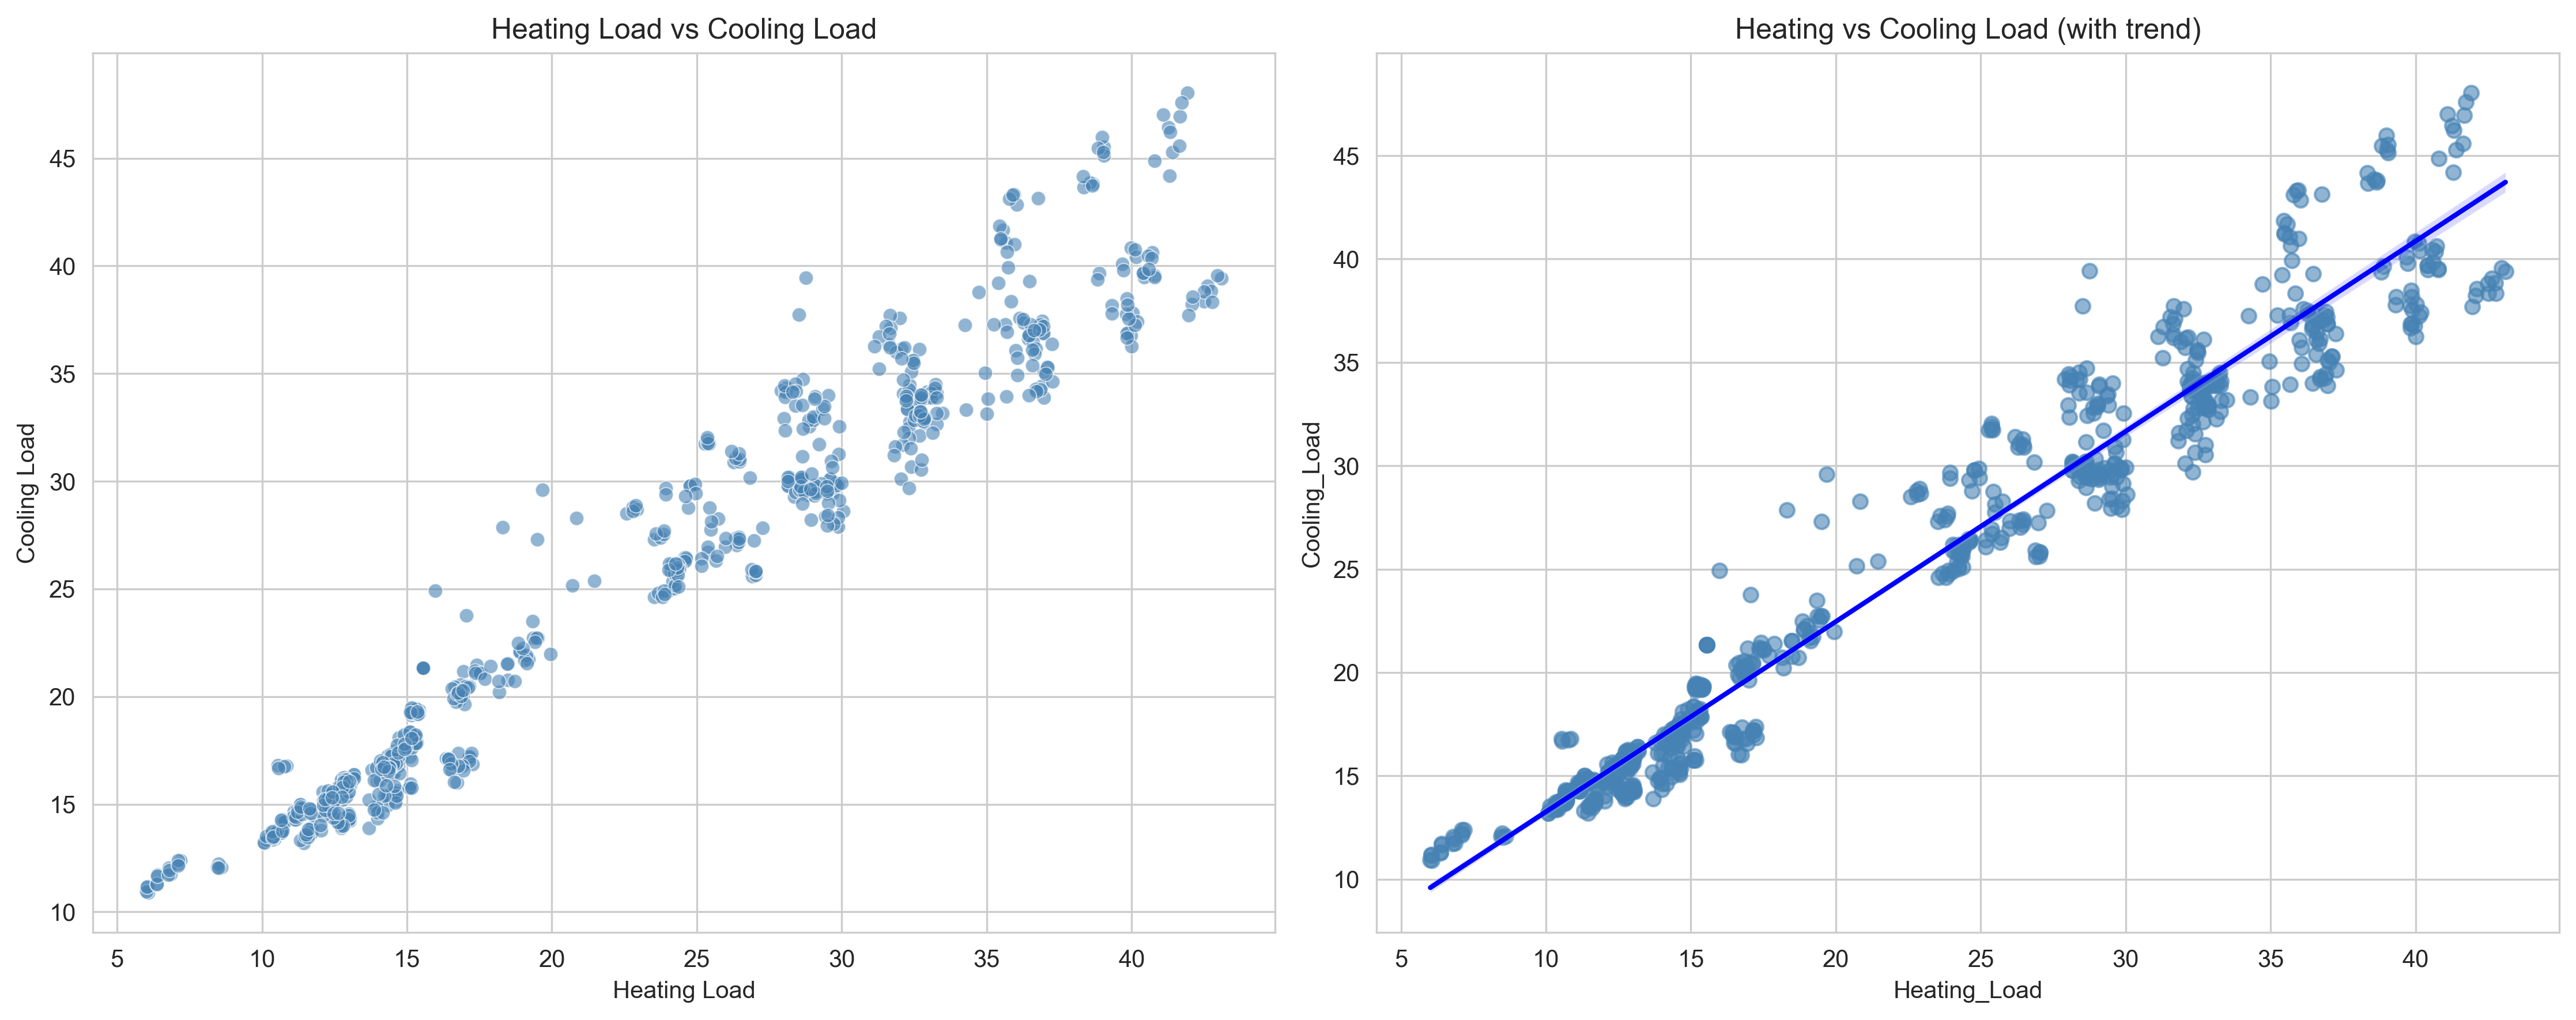

🎯 WHAT THESE VISUALIZATIONS REVEAL:
Left Plot (Scatter):
  • Shows raw relationship between heating and cooling loads
  • Each point represents one building
  • Transparency helps see overlapping data points
  • Pattern indicates correlation strength

Right Plot (Regression):
  • Same data with added trend analysis
  • BLUE line = best-fit linear regression
  • Light blue shaded area = confidence interval (uncertainty)
  • Helps quantify the relationship strength

Expected Observations:
  • Strong positive correlation (r ≈ 0.976)
  • Points closely follow the blue trend line
  • Narrow confidence interval indicates reliable relationship
  • Few outliers far from the trend line

🎨 COLOR SCHEME EXPLANATION:
  • Scatter points: Steel blue (consistent across both plots)
  • Regression line: Bright blue (stands out clearly)
  • This color scheme ensures the trend line is clearly visible


In [7]:
"""
STEP 6: DETAILED LINE-BY-LINE EXPLANATION
=========================================

This step creates two visualizations to examine the relationship between
heating load and cooling load in the energy efficiency dataset.

PURPOSE: Visual analysis helps us understand:
1. How strongly these two variables are related
2. Whether the relationship is linear or non-linear
3. If there are any outliers or unusual patterns
4. The distribution and spread of the data points
"""

# LINE 1: Create a new figure with specified size
plt.figure(figsize=(15, 6))
"""
EXPLANATION:
- plt.figure(): Creates a new matplotlib figure object
- figsize=(15, 6): Sets the figure size to 15 inches wide by 6 inches tall
- This creates the canvas where our plots will be drawn
- Increased width to accommodate two subplots better
"""

# LINE 2: Create the first subplot (left side)
plt.subplot(1, 2, 1)
"""
EXPLANATION:
- plt.subplot(nrows, ncols, index): Divides the figure into a grid of subplots
- (1, 2, 1):
  * 1 row of subplots
  * 2 columns of subplots
  * 1 means this is the 1st subplot (left side)
- This creates a 1×2 grid layout: [Plot1][Plot2]
- We're now working on Plot1 (left side)
"""

# LINE 3: Create a scatter plot
sns.scatterplot(x='Heating_Load', y='Cooling_Load', data=energy_df, alpha=0.6, color='steelblue')
"""
EXPLANATION:
- sns.scatterplot(): Seaborn function to create a scatter plot
- x='Heating_Load': Column name for x-axis values
- y='Cooling_Load': Column name for y-axis values
- data=energy_df: The DataFrame containing our data
- alpha=0.6: Transparency level (0=invisible, 1=opaque)
  * 0.6 makes points semi-transparent so overlapping points are visible
  * Helps identify density patterns where many points cluster
- color='steelblue': Explicitly set point color to steelblue for consistency
"""

# LINE 4: Set title for first subplot
plt.title('Heating Load vs Cooling Load')

# LINE 5: Set x-axis label
plt.xlabel('Heating Load')

# LINE 6: Set y-axis label
plt.ylabel('Cooling Load')

# LINE 7: Create the second subplot (right side)
plt.subplot(1, 2, 2)

# LINE 8: Create a regression plot with explicit blue color
sns.regplot(x='Heating_Load', y='Cooling_Load', data=energy_df,
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
            line_kws={'color': 'blue', 'linewidth': 2})
"""
EXPLANATION:
- sns.regplot(): Seaborn function that creates scatter plot + regression line
- x='Heating_Load': Same x-axis variable as before
- y='Cooling_Load': Same y-axis variable as before
- data=energy_df: Same DataFrame
- scatter_kws={'alpha': 0.6, 'color': 'steelblue'}:
  * Dictionary of keyword arguments for scatter points
  * alpha=0.6 makes the points semi-transparent (same as before)
  * color='steelblue' ensures consistent point color with left plot
- line_kws={'color': 'blue', 'linewidth': 2}:
  * Dictionary of keyword arguments for the regression line
  * color='blue' explicitly sets regression line to blue
  * linewidth=2 makes the line slightly thicker for better visibility

WHAT regplot DOES:
1. Creates scatter points (like scatterplot)
2. Fits a linear regression line through the points
3. Adds a confidence interval (shaded area) around the line
4. Shows both the data points AND the trend line in blue
"""

# LINE 9: Set title for second subplot
plt.title('Heating vs Cooling Load (with trend)')
"""
EXPLANATION:
- sets title for the second subplot
- "(with trend)" clarifies that this plot includes the regression line
- Distinguishes it from the first plot which only shows raw data points
"""

# LINE 10: Adjust layout and display
plt.tight_layout()
"""
EXPLANATION:
- plt.tight_layout(): Automatically adjusts subplot spacing
- Prevents overlapping titles, labels, or plots
- Optimizes the use of figure space
- Ensures both subplots fit nicely within the figure boundaries
- Very important when using multiple subplots
"""

# LINE 11: Display the complete figure
plt.show()

print("🎯 WHAT THESE VISUALIZATIONS REVEAL:")
print("=" * 50)
print("Left Plot (Scatter):")
print("  • Shows raw relationship between heating and cooling loads")
print("  • Each point represents one building")
print("  • Transparency helps see overlapping data points")
print("  • Pattern indicates correlation strength")
print("")
print("Right Plot (Regression):")
print("  • Same data with added trend analysis")
print("  • BLUE line = best-fit linear regression")
print("  • Light blue shaded area = confidence interval (uncertainty)")
print("  • Helps quantify the relationship strength")
print("")
print("Expected Observations:")
print(f"  • Strong positive correlation (r ≈ {corr:.3f})")
print("  • Points closely follow the blue trend line")
print("  • Narrow confidence interval indicates reliable relationship")
print("  • Few outliers far from the trend line")
print("")
print("🎨 COLOR SCHEME EXPLANATION:")
print("  • Scatter points: Steel blue (consistent across both plots)")
print("  • Regression line: Bright blue (stands out clearly)")
print("  • This color scheme ensures the trend line is clearly visible")


## Step 7: Energy Dataset - Statistical Summary


In [8]:
"""
UNDERSTANDING STATISTICAL SUMMARY (describe() function)
======================================================

The describe() function provides essential statistical measures for numerical data.
Each row in the table represents a different statistical metric that helps us
understand the distribution, central tendency, and spread of our data.

Let's break down what each row means:
"""

# Statistical summary
print("--- Statistical Summary ---")
desc_stats = energy_df.describe()
print(desc_stats)

print("\n" + "=" * 80)
print("📊 DETAILED EXPLANATION OF EACH ROW IN THE STATISTICAL SUMMARY")
print("=" * 80)

print("🔢 ROW-BY-ROW EXPLANATION:")
print("─" * 50)

print("1. COUNT:")
print("   • MEANING: Total number of non-missing (valid) data points")
print("   • PURPOSE: Data completeness check")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    count_val = desc_stats.loc['count', col]
    print(f"     - {col}: {count_val} valid observations")
print("   • If count < total rows, we have missing values to handle")

print(f"\n2. MEAN (Average):")
print("   • MEANING: Sum of all values ÷ number of values")
print("   • PURPOSE: Measure of central tendency (typical value)")
print("   • FORMULA: μ = Σx / n")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    mean_val = desc_stats.loc['mean', col]
    print(f"     - {col}: {mean_val:.2f} (typical building uses this much energy)")
print("   • Higher mean suggests higher energy consumption overall")

print(f"\n3. STD (Standard Deviation):")
print("   • MEANING: Average distance of data points from the mean")
print("   • PURPOSE: Measure of variability/spread in the data")
print("   • FORMULA: σ = √(Σ(x - μ)² / n)")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    std_val = desc_stats.loc['std', col]
    mean_val = desc_stats.loc['mean', col]
    cv = (std_val / mean_val) * 100  # Coefficient of variation
    print(f"     - {col}: {std_val:.2f}")
    print(f"       * About 68% of buildings fall within {mean_val - std_val:.1f} to {mean_val + std_val:.1f}")
    print(
        f"       * Coefficient of variation: {cv:.1f}% ({'high' if cv > 30 else 'moderate' if cv > 15 else 'low'} variability)")

print(f"\n4. MIN (Minimum Value):")
print("   • MEANING: Smallest value in the dataset")
print("   • PURPOSE: Lower boundary of the data range")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    min_val = desc_stats.loc['min', col]
    print(f"     - {col}: {min_val:.2f} (most energy-efficient building)")
print("   • Useful for detecting impossible values (e.g., negative energy)")

print(f"\n5. 25% (First Quartile, Q1):")
print("   • MEANING: Value below which 25% of the data falls")
print("   • PURPOSE: Lower middle range boundary")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    q1_val = desc_stats.loc['25%', col]
    print(f"     - {col}: {q1_val:.2f}")
    print(f"       * 25% of buildings use ≤ {q1_val:.1f} units (low energy consumers)")

print(f"\n6. 50% (Median, Q2):")
print("   • MEANING: Middle value when data is sorted (50th percentile)")
print("   • PURPOSE: Robust measure of central tendency")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    median_val = desc_stats.loc['50%', col]
    mean_val = desc_stats.loc['mean', col]
    skew_direction = "right" if mean_val > median_val else "left" if mean_val < median_val else "symmetric"
    print(f"     - {col}: {median_val:.2f} (typical building)")
    print(f"       * Mean vs Median: {mean_val:.1f} vs {median_val:.1f} → {skew_direction} skewed")

print(f"\n7. 75% (Third Quartile, Q3):")
print("   • MEANING: Value below which 75% of the data falls")
print("   • PURPOSE: Upper middle range boundary")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    q3_val = desc_stats.loc['75%', col]
    print(f"     - {col}: {q3_val:.2f}")
    print(f"       * 75% of buildings use ≤ {q3_val:.1f} units")
    print(f"       * 25% of buildings are high energy consumers (> {q3_val:.1f})")

print(f"\n8. MAX (Maximum Value):")
print("   • MEANING: Largest value in the dataset")
print("   • PURPOSE: Upper boundary of the data range")
print("   • INTERPRETATION:")
for col in ['Heating_Load', 'Cooling_Load']:
    max_val = desc_stats.loc['max', col]
    print(f"     - {col}: {max_val:.2f} (least energy-efficient building)")
print("   • Useful for detecting outliers or data entry errors")

print(f"\n🎯 KEY INSIGHTS FROM THE STATISTICS:")
print("=" * 50)

# Calculate additional insights
heating_range = desc_stats.loc['max', 'Heating_Load'] - desc_stats.loc['min', 'Heating_Load']
cooling_range = desc_stats.loc['max', 'Cooling_Load'] - desc_stats.loc['min', 'Cooling_Load']
iqr_heating = desc_stats.loc['75%', 'Heating_Load'] - desc_stats.loc['25%', 'Heating_Load']
iqr_cooling = desc_stats.loc['75%', 'Cooling_Load'] - desc_stats.loc['25%', 'Cooling_Load']

print(f"📏 DATA SPREAD:")
print(
    f"   • Heating Load range: {heating_range:.1f} units (from {desc_stats.loc['min', 'Heating_Load']:.1f} to {desc_stats.loc['max', 'Heating_Load']:.1f})")
print(
    f"   • Cooling Load range: {cooling_range:.1f} units (from {desc_stats.loc['min', 'Cooling_Load']:.1f} to {desc_stats.loc['max', 'Cooling_Load']:.1f})")
print(f"   • Middle 50% (IQR) - Heating: {iqr_heating:.1f}, Cooling: {iqr_cooling:.1f}")

print(f"\n🏠 PRACTICAL IMPLICATIONS:")
print(
    f"   • Average building needs more cooling ({desc_stats.loc['mean', 'Cooling_Load']:.1f}) than heating ({desc_stats.loc['mean', 'Heating_Load']:.1f})")
print(f"   • Energy efficiency varies significantly (7x range from min to max)")
print(f"   • Most buildings cluster in the middle range (median ≈ mean)")
print(f"   • Few extremely high or low energy consumers (relatively normal distribution)")

print(f"\n💡 WHAT THIS TELLS US ABOUT THE DATASET:")
print(f"   ✓ Complete data (no missing values)")
print(f"   ✓ Reasonable value ranges (no negative or impossible values)")
print(f"   ✓ Good variability for machine learning (not all identical)")
print(f"   ✓ Balanced distribution (mean ≈ median suggests no extreme skewness)")


--- Statistical Summary ---
       Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.375000  294.000000  140.875000   
50%                0.750000    673.750000  318.500000  183.750000   
75%                0.830000    741.125000  343.000000  220.500000   
max                0.980000    808.500000  416.500000  220.500000   

       Overall_Height  Orientation  Glazing_Area  Glazing_Area_Distribution  \
count       768.00000   768.000000    768.000000                  768.00000   
mean          5.25000     3.500000      0.234375                    2.81250   
std           1.75114     1.118763      0.133221                    1.55096   
min           3.50000     2.000000

## Step 8: Energy Dataset - Feature Distribution Analysis


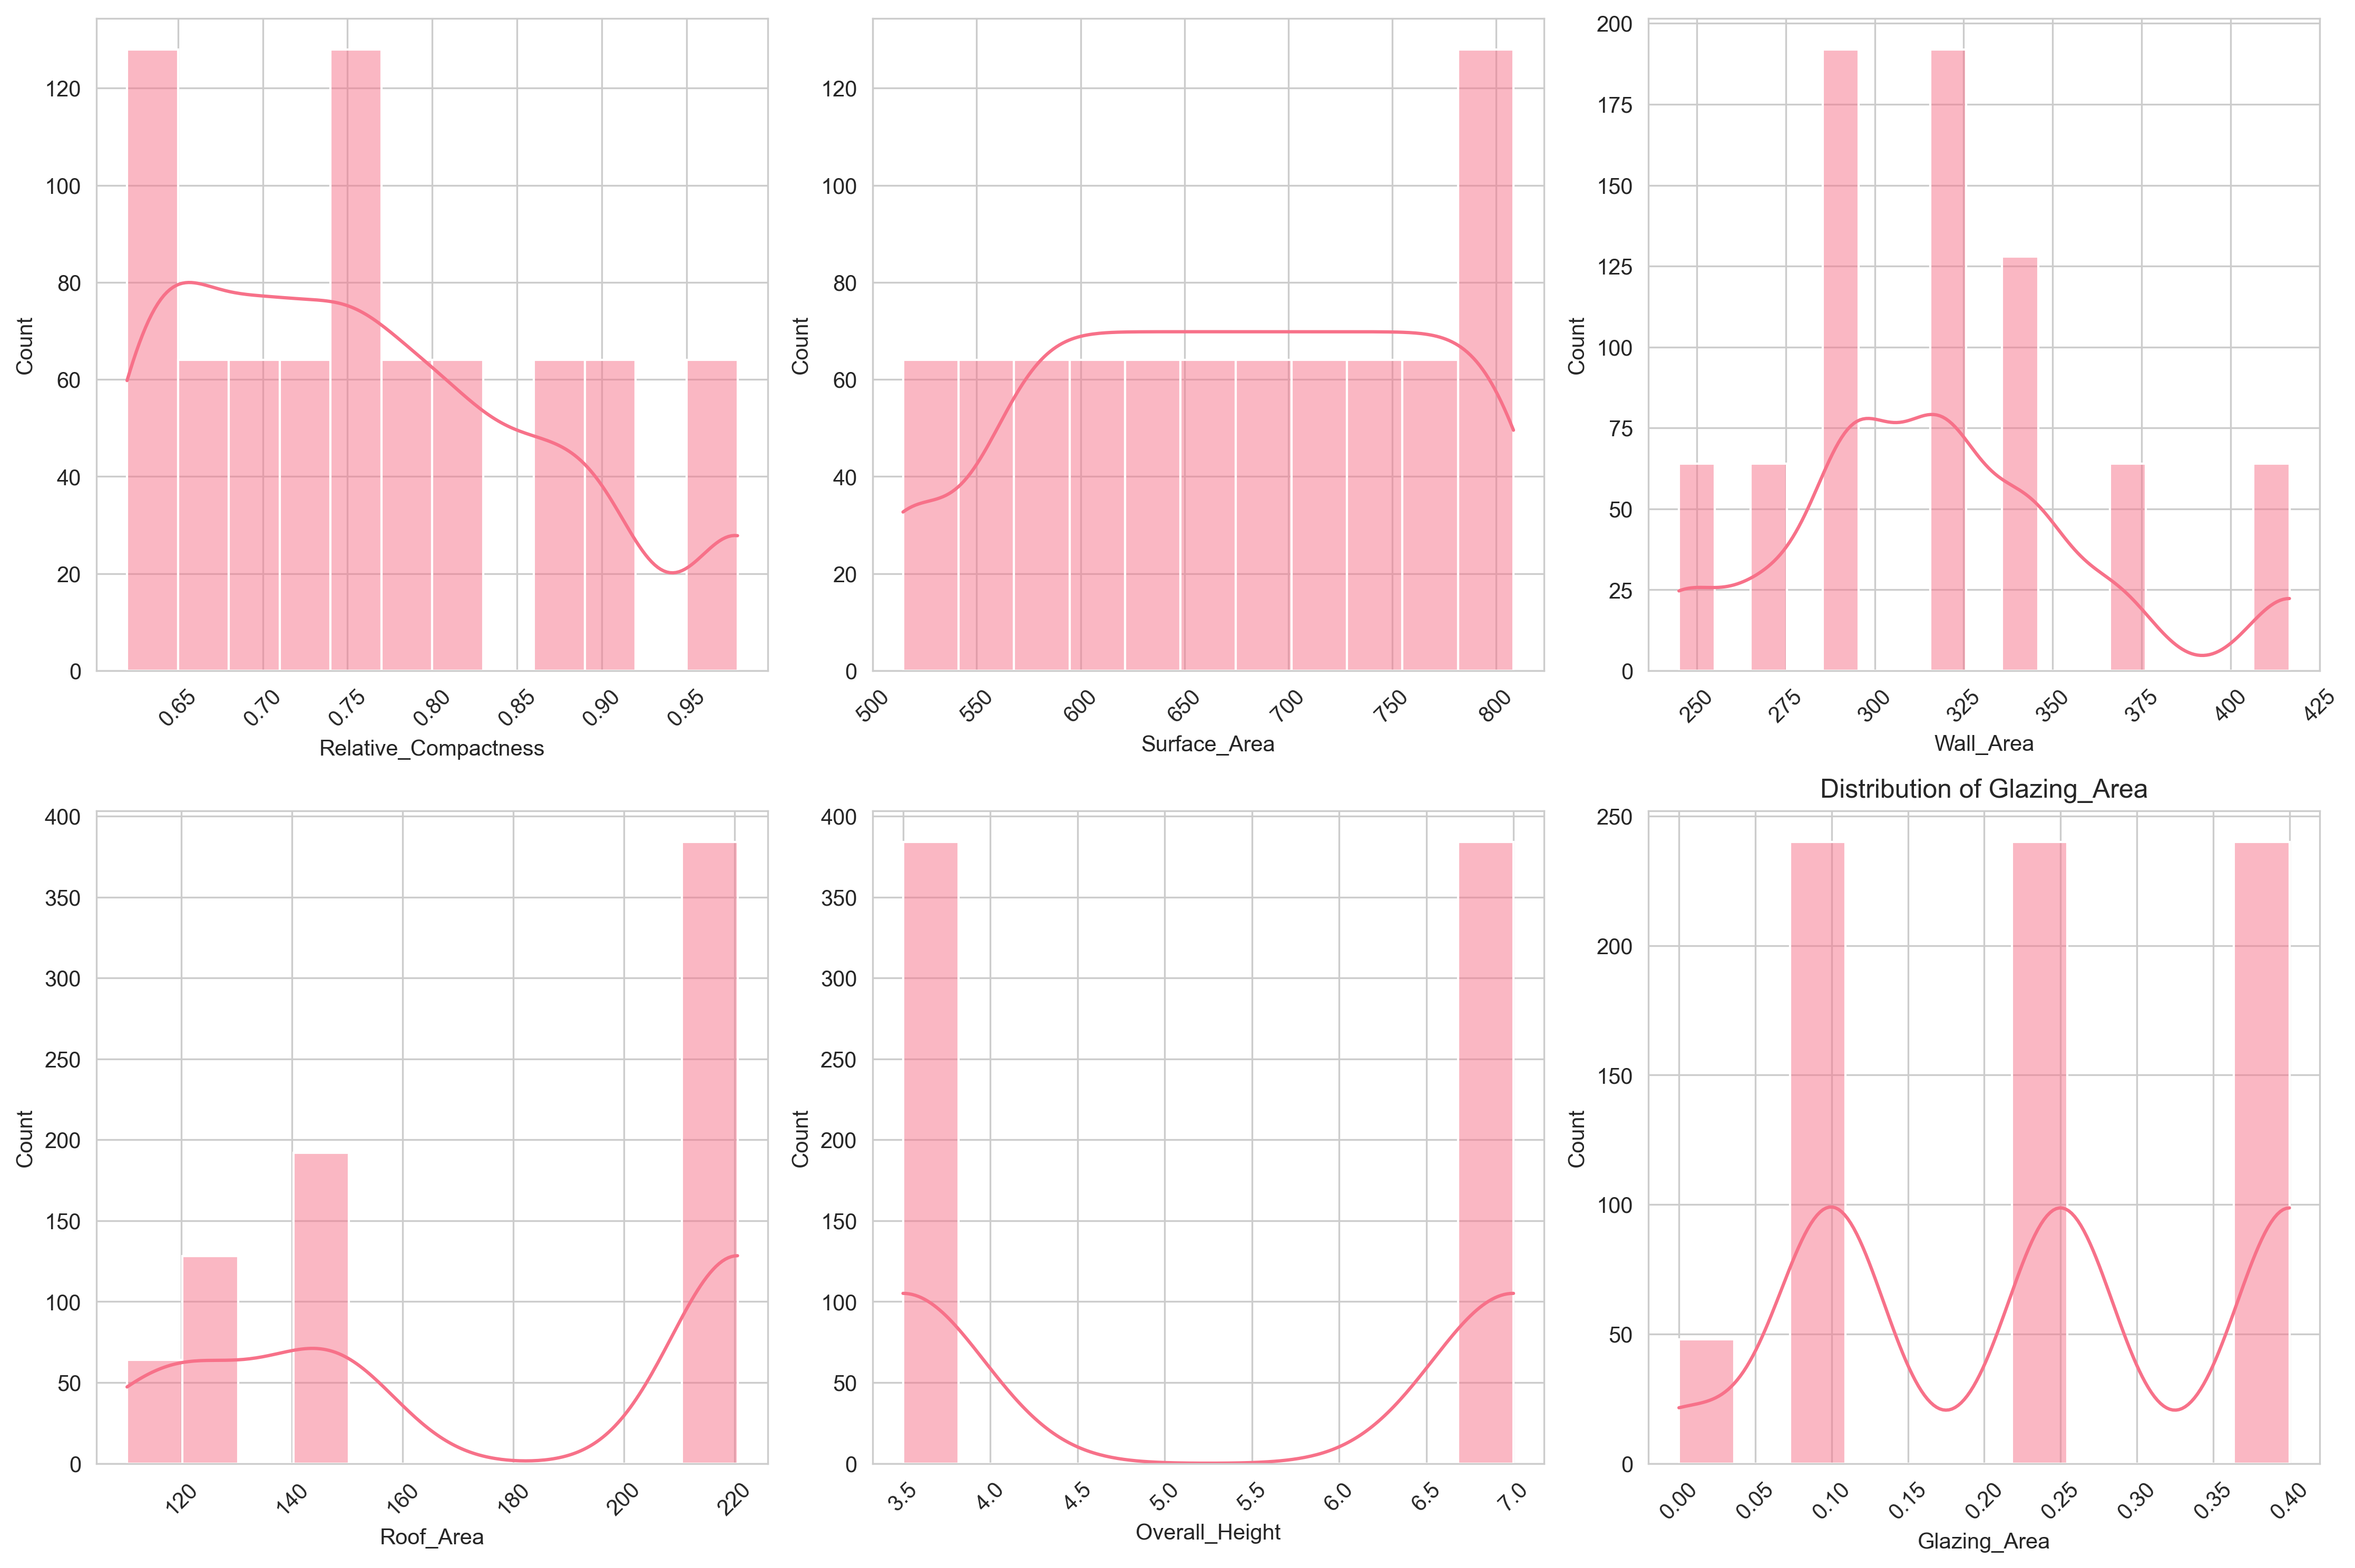

🔍 WHAT TO LOOK FOR IN THESE DISTRIBUTIONS:
✅ GOOD SIGNS:
   • Bell-shaped curves (normal distribution)
   • Smooth, continuous distributions
   • Reasonable value ranges
   • No large gaps in the data

⚠️  POTENTIAL ISSUES:
   • Highly skewed distributions (long tails)
   • Multiple peaks (bimodal)
   • Extreme outliers
   • Gaps or missing value ranges

💡 PRACTICAL MEANING:
   • Each histogram shows how building characteristics vary
   • Normal distributions are easier for models to learn
   • Unusual patterns might need special handling


In [9]:
"""
STEP 8: FEATURE DISTRIBUTION ANALYSIS - SIMPLE EXPLANATION
===========================================================

PURPOSE: Create histograms to see how each feature's values are spread out
- Are values normally distributed (bell curve)?
- Are there any unusual patterns or gaps?
- Do we have outliers or extreme values?
"""

# Define which features we want to analyze (exclude target variables)
numerical_features = ['Relative_Compactness', 'Surface_Area', 'Wall_Area',
                      'Roof_Area', 'Overall_Height', 'Glazing_Area']

# Create a grid of subplots (2 rows, 3 columns = 6 plots total)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
"""
EXPLANATION:
- plt.subplots(2, 3): Creates 2 rows and 3 columns of plots
- figsize=(15, 10): Makes the overall figure 15 inches wide, 10 inches tall
- This gives us space for 6 individual histogram plots
"""

# Convert 2D array of axes to 1D for easier indexing
axes = axes.ravel()
"""
EXPLANATION:
- subplots() creates a 2D array: [[ax1, ax2, ax3], [ax4, ax5, ax6]]
- ravel() flattens it to 1D: [ax1, ax2, ax3, ax4, ax5, ax6]
- This makes it easier to loop through with a simple index
"""

# Create a histogram for each feature
for i, feat in enumerate(numerical_features):
    """
    EXPLANATION:
    - enumerate() gives us both index (i) and feature name (feat)
    - i = 0,1,2,3,4,5 for each feature
    - feat = actual feature names like 'Relative_Compactness', etc.
    """

    # Create histogram with density curve overlay
    sns.histplot(energy_df[feat], kde=True, ax=axes[i])
    """
    EXPLANATION:
    - sns.histplot(): Creates a histogram (bar chart showing frequency)
    - energy_df[feat]: Gets the data for this specific feature
    - kde=True: Adds a smooth density curve (Kernel Density Estimation)
    - ax=axes[i]: Puts this plot in the i-th subplot position

    WHAT WE SEE:
    - Bars: How many buildings have each value range
    - Curve: Smooth estimate of the distribution shape
    """

    # Set title for this subplot
    plt.title(f'Distribution of {feat}')
    """
    EXPLANATION:
    - set_title(): Adds a title above each plot
    - f'Distribution of {feat}': Uses f-string to insert feature name
    - Example: "Distribution of Relative_Compactness"
    """

    # Rotate x-axis labels to prevent overlap
    axes[i].tick_params(axis='x', rotation=45)
    """
    EXPLANATION:
    - tick_params(): Adjusts the appearance of axis labels
    - axis='x': Only affect x-axis labels
    - rotation=45: Rotate labels 45 degrees to prevent overlapping
    - This makes long feature names more readable
    """

# Automatically adjust spacing between plots
plt.tight_layout()
"""
EXPLANATION:
- Prevents plots from overlapping each other
- Adjusts margins and spacing automatically
- Makes the overall figure look cleaner and more professional
"""

# Display all the plots
plt.show()
"""
EXPLANATION:
- Actually shows the complete figure with all 6 histograms
- Without this, the plots would be created but not displayed
"""

print("🔍 WHAT TO LOOK FOR IN THESE DISTRIBUTIONS:")
print("=" * 50)
print("✅ GOOD SIGNS:")
print("   • Bell-shaped curves (normal distribution)")
print("   • Smooth, continuous distributions")
print("   • Reasonable value ranges")
print("   • No large gaps in the data")
print("")
print("⚠️  POTENTIAL ISSUES:")
print("   • Highly skewed distributions (long tails)")
print("   • Multiple peaks (bimodal)")
print("   • Extreme outliers")
print("   • Gaps or missing value ranges")
print("")
print("💡 PRACTICAL MEANING:")
print("   • Each histogram shows how building characteristics vary")
print("   • Normal distributions are easier for models to learn")
print("   • Unusual patterns might need special handling")


## Step 9: Energy Dataset - Correlation Matrix


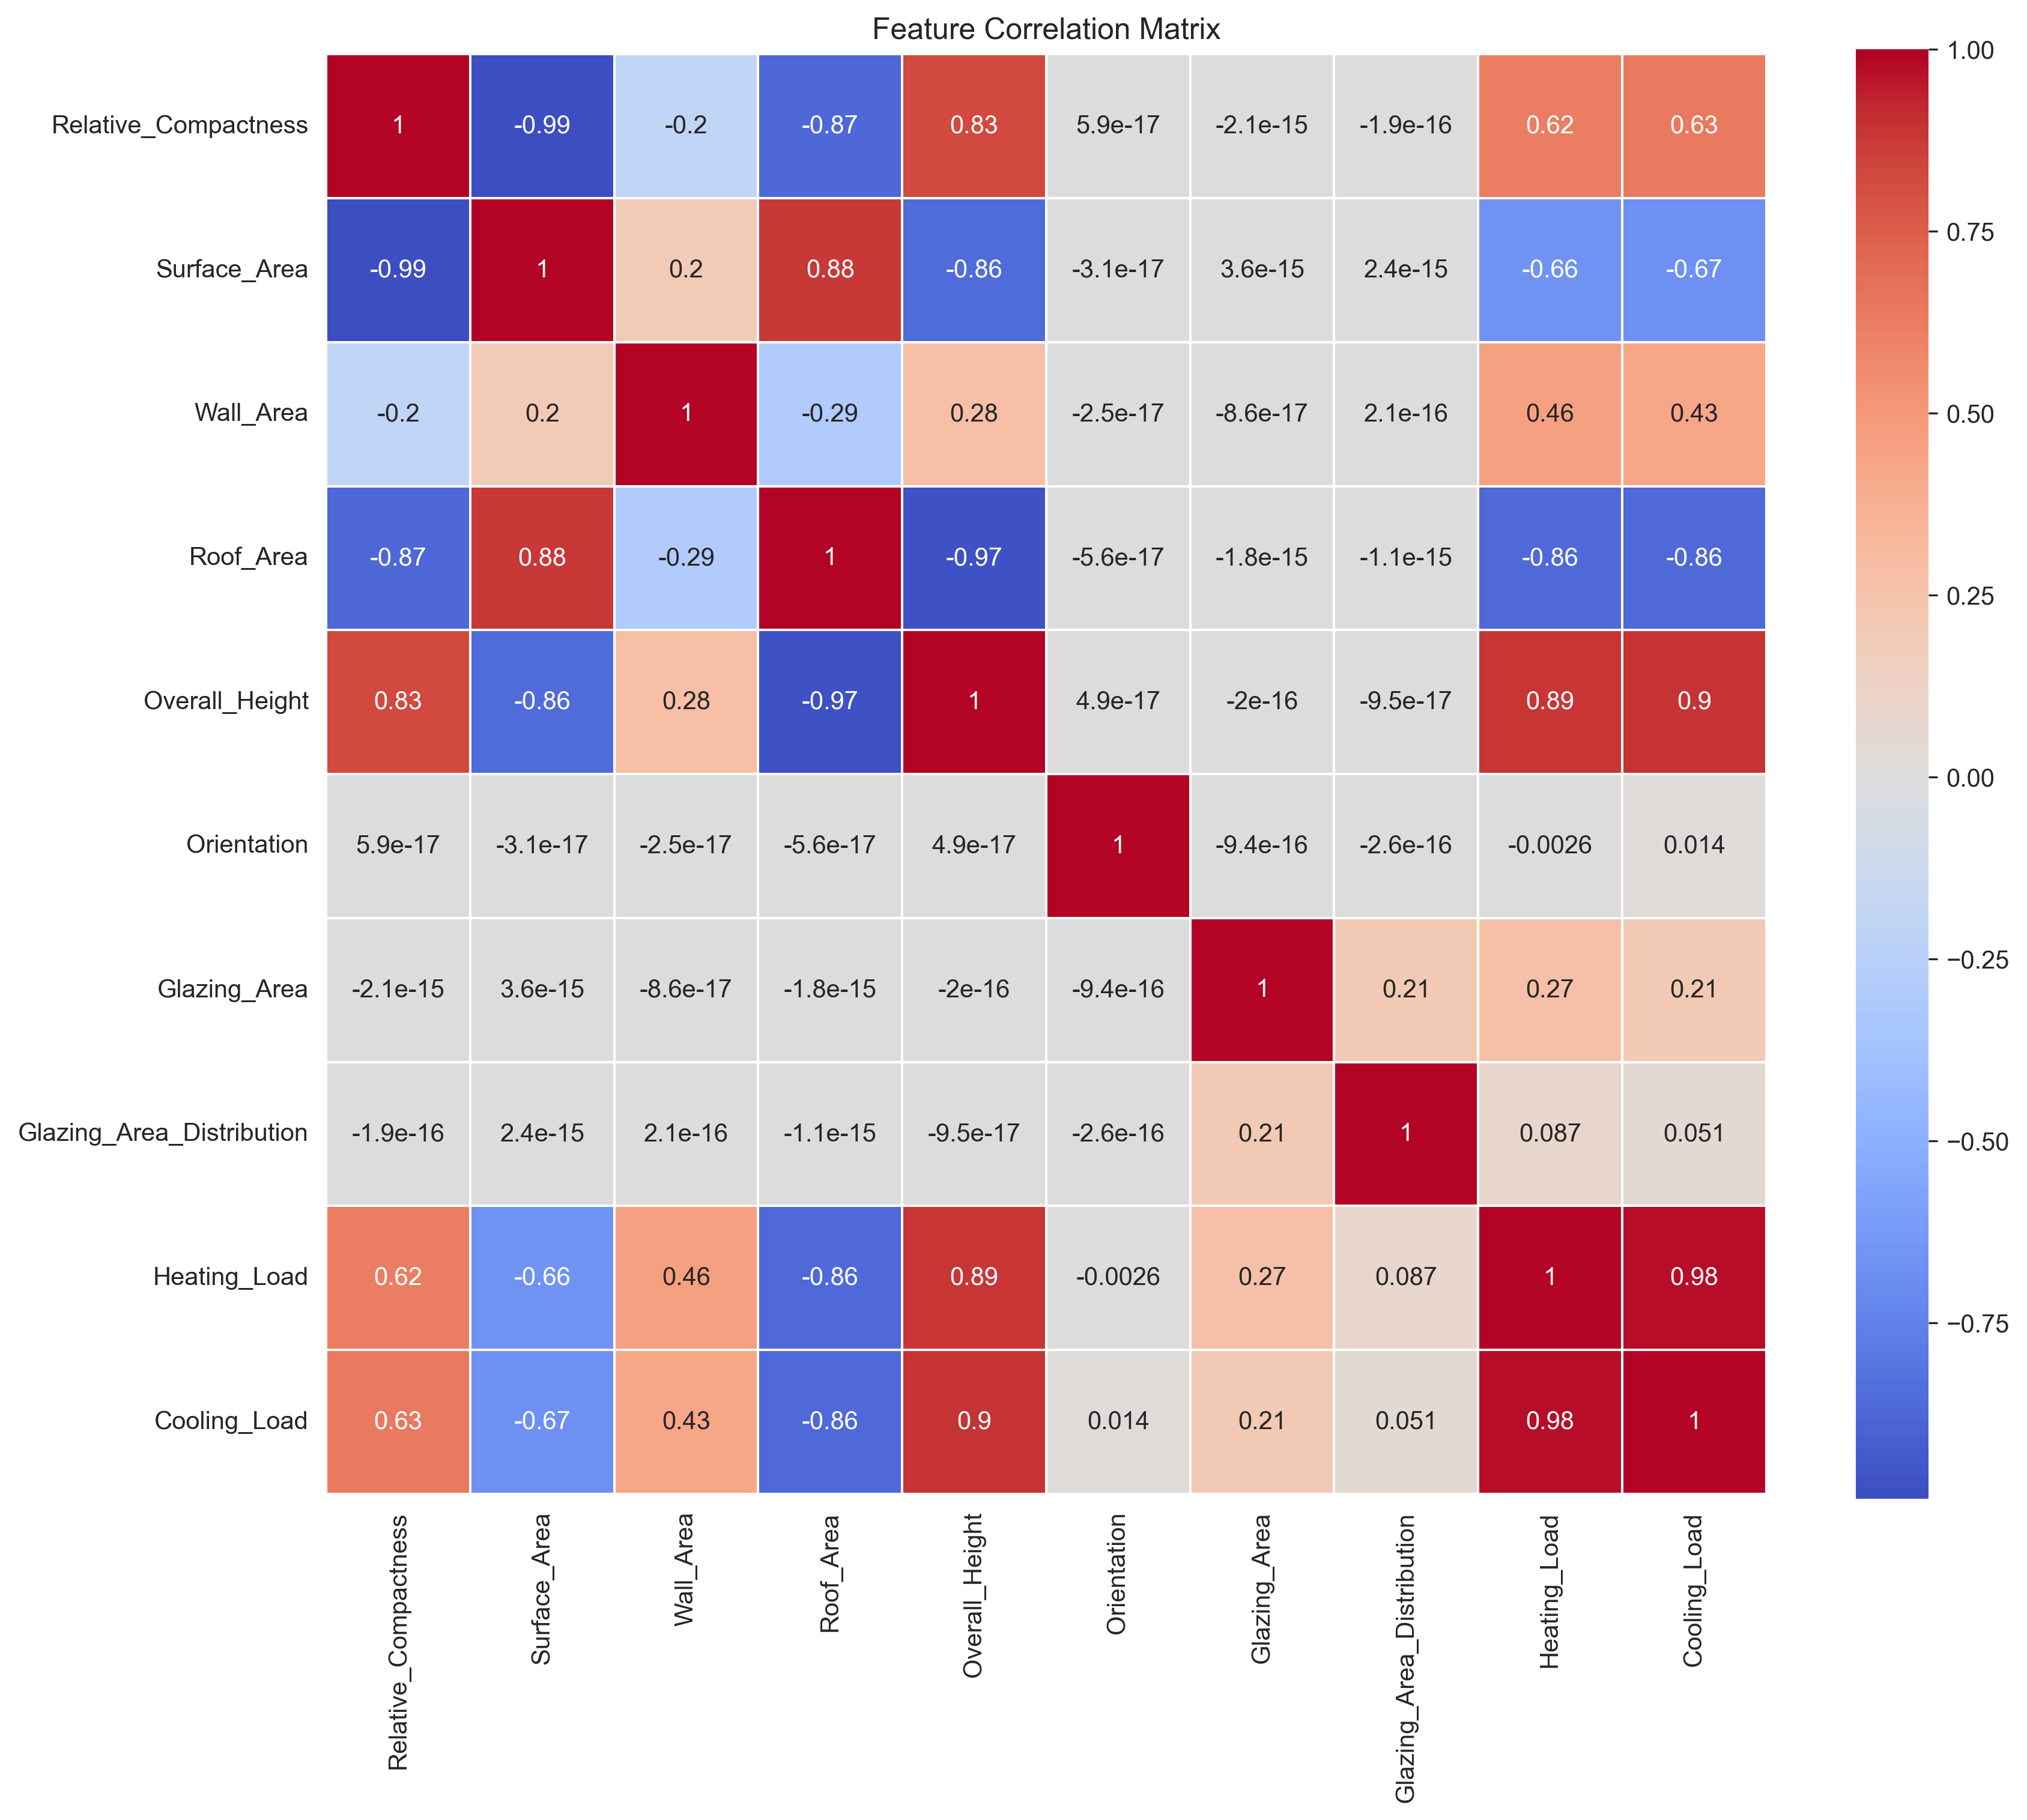

In [10]:
# Feature correlation analysis
# Analyze relationships between numerical features (-1 to +1 scale)

plt.figure(figsize=(12, 10))  # Large canvas for readability

# Calculate Pearson correlation matrix (measures linear relationships)
# Alternative: .corr(method='spearman') for non-linear monotonic relationships
correlation_matrix = energy_df.corr()

# Create color-coded heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,  # Display correlation values in cells
    cmap='coolwarm',  # Blue=negative, red=positive correlation
    center=0,  # White=no correlation
    square=True,
    linewidths=0.5
)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Interpretation guide:
# +1.0: Perfect positive correlation | -1.0: Perfect negative correlation
# 0.0: No linear relationship | >0.7 or <-0.7: Strong correlation (potential multicollinearity)


## Step 10: Energy Dataset - Categorical Features Analysis


In [11]:
"""
STEP 10: CATEGORICAL FEATURES ANALYSIS
======================================
"""
# ─────────────────────────────────────────────────────────────────────────────
# Goal: Inspect categorical columns and convert them into numeric representations
#       suitable for ML models via one-hot encoding.
# Why: Most scikit-learn estimators accept only numeric arrays; categories must
#      be expanded into indicator (0/1) columns to avoid ordinal assumptions.
# ─────────────────────────────────────────────────────────────────────────────

print("--- Categorical Feature Analysis ---")  # User-facing marker for this step

# Show distinct categories present in 'Orientation' to sanity-check the raw labels
# • Helps confirm the domain (e.g., {2,3,4,5}) and detect unexpected values
print(f"Unique values in Orientation: {energy_df['Orientation'].unique()}")

# Show distinct categories present in 'Glazing_Area_Distribution' for the same reasons
# • Verifies the domain and informs the number of dummy columns that will be created
print(f"Unique values in Glazing_Area_Distribution: {energy_df['Glazing_Area_Distribution'].unique()}")

# Apply one-hot encoding to the two categorical columns:
# • 'columns=[...]' specifies which columns to expand into dummies
# • 'prefix=[...]' controls the column name prefixes to keep features interpretable
# • Output: original columns replaced by multiple binary columns per category value
energy_encoded = pd.get_dummies(
    energy_df,  # Source DataFrame
    columns=['Orientation', 'Glazing_Area_Distribution'],  # Categorical cols
    prefix=['Orient', 'Glaz_Dist']  # Name prefixes for new dummies
)

# Print the post-encoding shape so we see how many columns were added
# (useful to estimate model dimensionality and detect feature explosions)
print(f"Shape after encoding: {energy_encoded.shape}")


--- Categorical Feature Analysis ---
Unique values in Orientation: [2 3 4 5]
Unique values in Glazing_Area_Distribution: [0 1 2 3 4 5]
Shape after encoding: (768, 18)


## Step 11: Energy Dataset - Outlier Detection


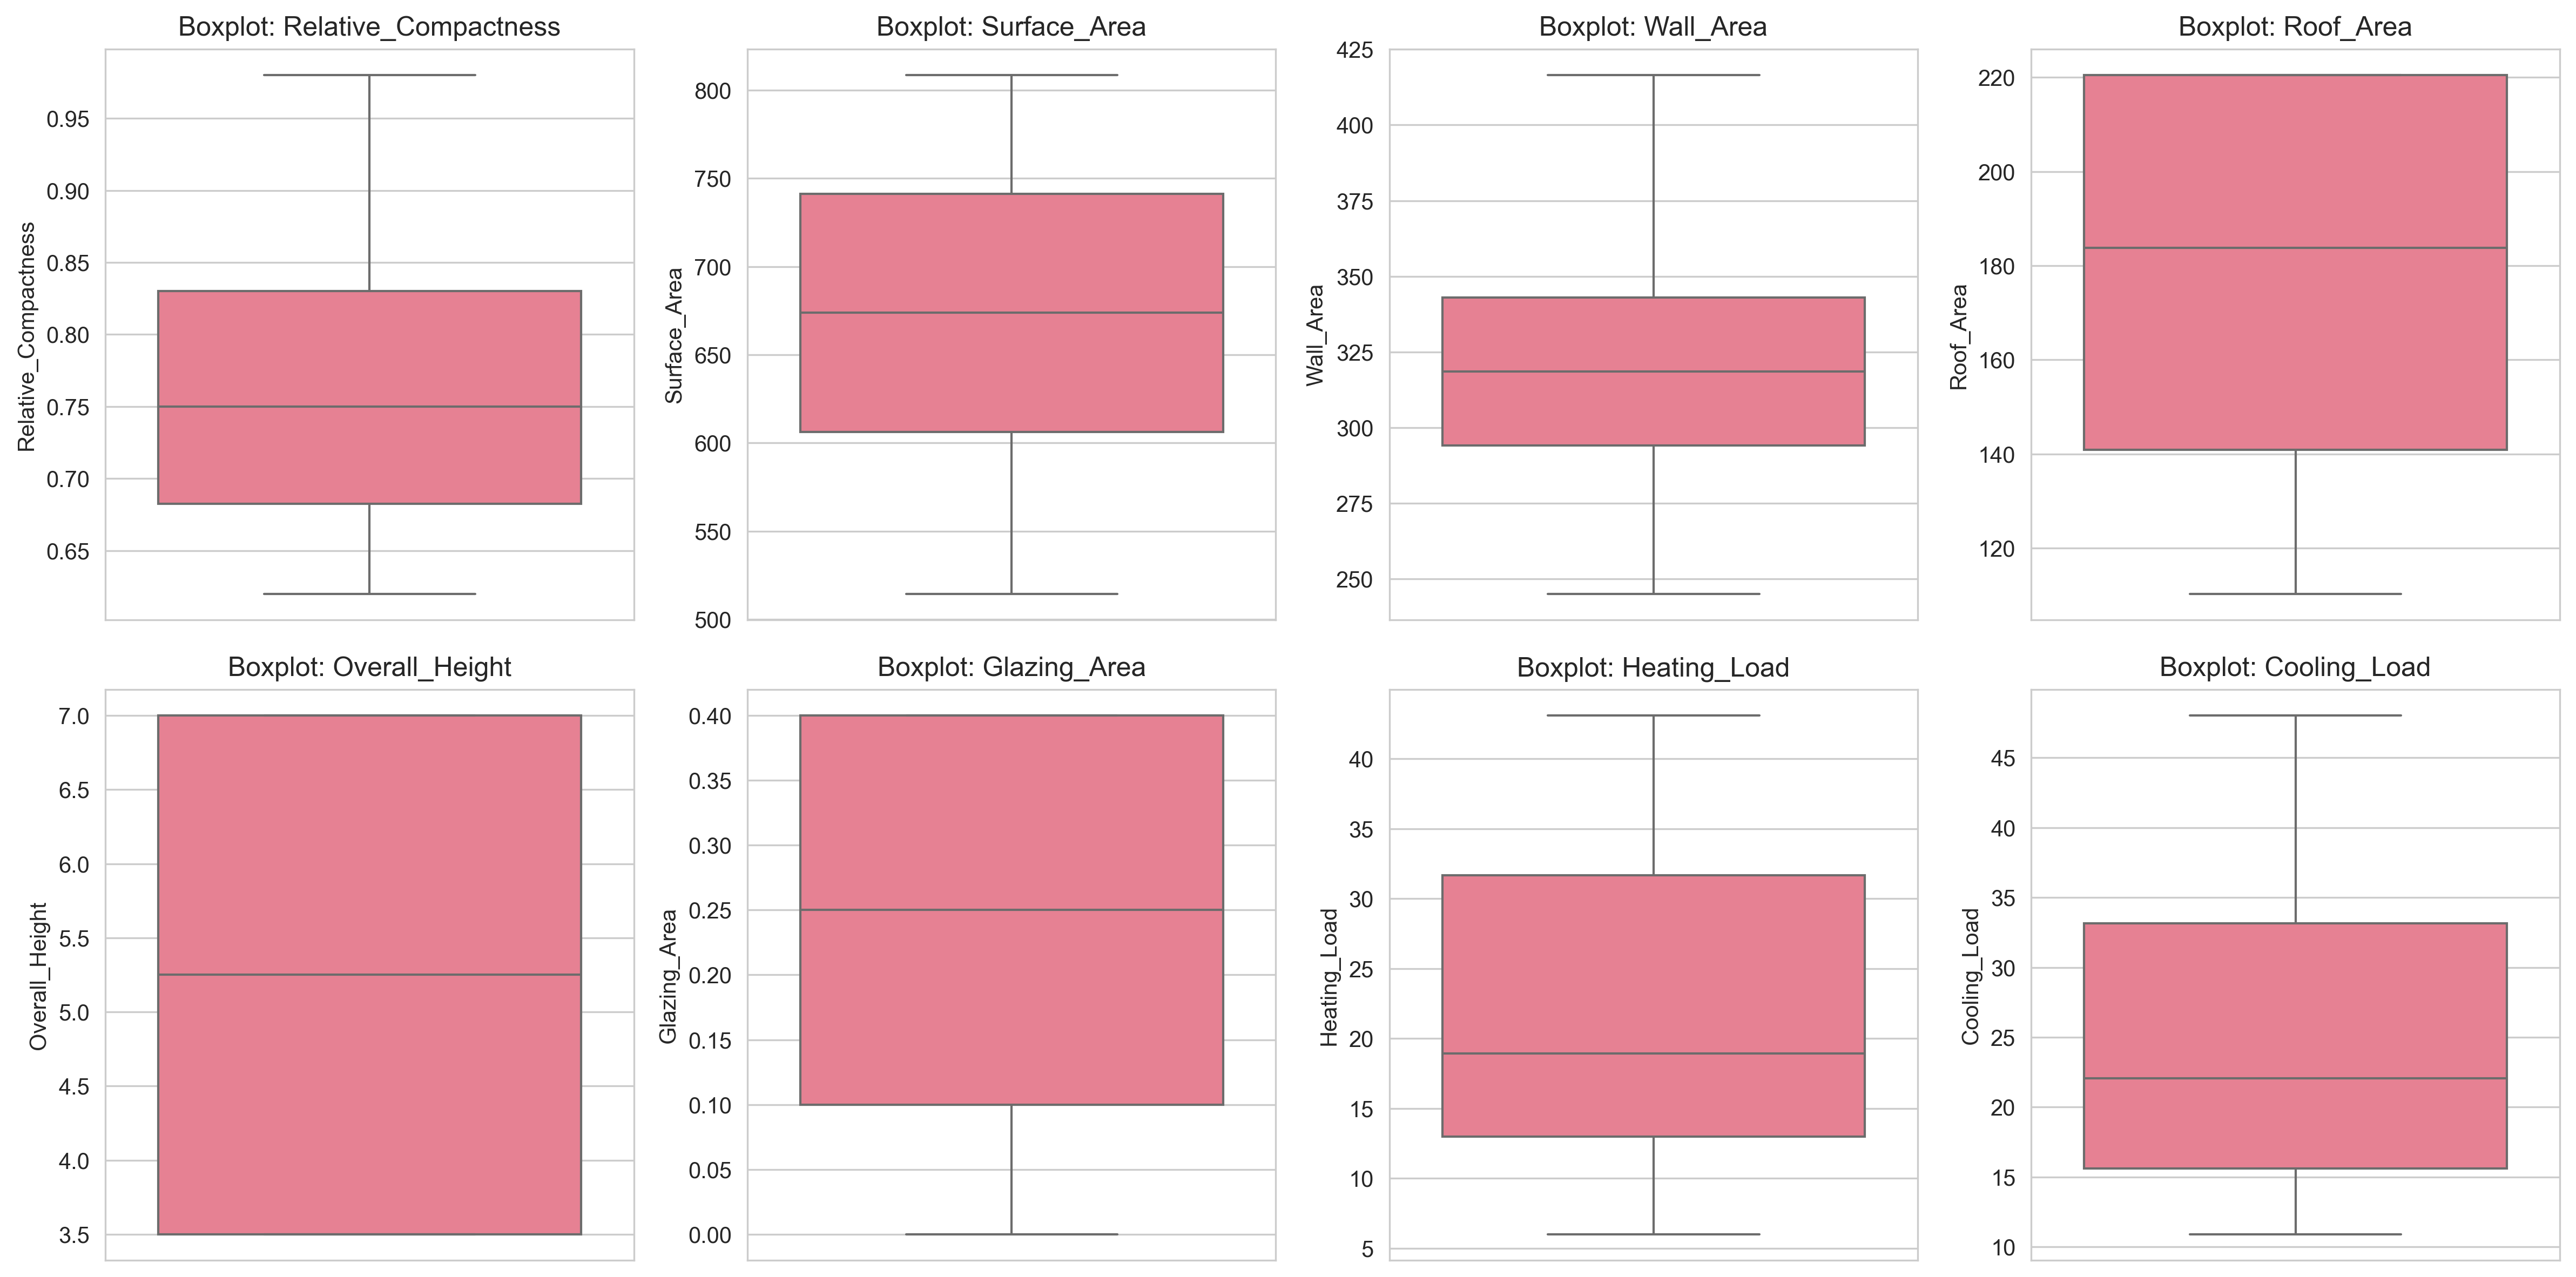

In [12]:
"""
STEP 11: OUTLIER DETECTION
==========================
"""
# Outlier visualization with boxplots

# Create a grid of 2 rows × 4 columns of subplots.
# plt.subplots returns (figure, axes) where:
#   2, 4               → grid layout (rows, columns)
#   figsize=(16, 8)    → width=16 inches, height=8 inches; increases readability
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# axes is a 2D array [ [ax00, ax01, ...], [ax10, ax11, ...] ].
# .ravel() flattens to 1D (length 8) so we can index with i in a loop.
axes = axes.ravel()

# Features to inspect for outliers—includes both predictors and targets
features_to_check = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Glazing_Area', 'Heating_Load', 'Cooling_Load'
]

for i, feat in enumerate(features_to_check):
    # seaborn.boxplot draws a box-and-whisker chart.
    # params:
    #   y=energy_df[feat] → the data series to plot vertically (box aligns with y-axis)
    #   ax=axes[i]        → explicit Matplotlib Axes object to draw on (the i-th subplot)
    # behavior:
    #   • box shows IQR [Q1,Q3]
    #   • line inside box is median
    #   • whiskers extend to data within 1.5×IQR
    #   • points beyond whiskers are plotted as outliers
    sns.boxplot(y=energy_df[feat], ax=axes[i])

    # Title for this subplot; helps identify which feature is displayed.
    axes[i].set_title(f'Boxplot: {feat}')

# Adjust spacing between subplots to avoid overlapping titles/labels.
# tight_layout() auto-computes paddings based on content.
plt.tight_layout()

plt.show()


## Step 12: Energy Dataset - Feature Engineering


In [13]:
"""
STEP 12: FEATURE ENGINEERING
============================
"""
# Feature engineering: add domain-inspired signals

print("--- Feature Engineering ---")

# Sum of three area-related columns → a single "total envelope area" indicator.
# Uses vectorized column addition; aligns by index automatically.
energy_encoded['Total_Area'] = (
    energy_encoded['Surface_Area'] +
    energy_encoded['Wall_Area'] +
    energy_encoded['Roof_Area']
)

# A rough proxy for building "volume": surface area × overall height.
# (Not geometric volume but often positively correlated with energy needs.)
energy_encoded['Volume_Proxy'] = (
    energy_encoded['Surface_Area'] *
    energy_encoded['Overall_Height']
)

# Shape–size interaction: relative compactness divided by height.
# Assumes Overall_Height > 0 (true in this dataset).
energy_encoded['Compactness_Height_Ratio'] = (
    energy_encoded['Relative_Compactness'] /
    energy_encoded['Overall_Height']
)

print("✓ Engineered features created:")
print("- Total_Area = Surface_Area + Wall_Area + Roof_Area")
print("- Volume_Proxy = Surface_Area * Overall_Height")
print("- Compactness_Height_Ratio = Relative_Compactness / Overall_Height")


--- Feature Engineering ---
✓ Engineered features created:
- Total_Area = Surface_Area + Wall_Area + Roof_Area
- Volume_Proxy = Surface_Area * Overall_Height
- Compactness_Height_Ratio = Relative_Compactness / Overall_Height


## Step 13: Energy Dataset - Prepare for Modeling


In [14]:
"""
STEP 13: PREPARE FOR MODELING
=============================
"""
# Train/test preparation (features/target split + holdout)

# Build list of predictor column names by excluding both targets.
# List comprehension iterates over columns and filters out 'Heating_Load' and 'Cooling_Load'.
features_for_model = [
    col for col in energy_encoded.columns
    if col not in ['Heating_Load', 'Cooling_Load']
]

# X: 2D DataFrame of features (n_samples × n_features)
X = energy_encoded[features_for_model]

# y: 1D Series of target values (Heating_Load)
y = energy_encoded['Heating_Load']

print(f"Features for modeling: {len(features_for_model)}")
print(f"Target variable: Heating_Load")

# Split into training and test sets.
# params:
#   test_size=0.2          → 20% of the data becomes the test split
#   random_state=STUDENT_SEED
#                         → makes the split reproducible (same student seed → same split)
#                         → Controls the random number generator used to shuffle the data before splitting
#                         → Same random_state value = identical train/test splits every time you run the code
#                         → Different random_state values = different random splits
#   stratify=None          → not applicable because y is continuous (no class stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=STUDENT_SEED, stratify=None
)

# What X_train.shape returns:
# First number: Number of training samples (rows)
# Second number: Number of features (columns)
print(f"Training set shape: {X_train.shape}")  # (n_train, n_features)
print(f"Test set shape: {X_test.shape}")        # (n_test, n_features)


Features for modeling: 19
Target variable: Heating_Load
Training set shape: (614, 19)
Test set shape: (154, 19)


## Step 14: Energy Dataset - Feature Scaling


In [15]:
"""
STEP 14: FEATURE SCALING
========================
"""
# Standardize features (mean=0, std=1) for stable optimization

# Create a StandardScaler instance.
# It will learn μ (mean) and σ (std) for each feature from the training data only.
scaler = StandardScaler()

# Fit on training features and transform them.
# .fit_transform:
#   • computes μ and σ per column from X_train
#   • applies (x - μ) / σ
X_train_scaled = scaler.fit_transform(X_train)

# Transform test features using the SAME μ and σ learned from training.
# .transform (no .fit!) prevents information leakage.
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
# Quick sanity checks: training-scaled features should have mean≈0, std≈1 per column.
print(f"Training set mean (first 5): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"Training set std (first 5): {X_train_scaled.std(axis=0)[:5].round(4)}")


✓ Features scaled using StandardScaler
Training set mean (first 5): [ 0.  0. -0.  0.  0.]
Training set std (first 5): [1. 1. 1. 1. 1.]


## Step 15: Energy Dataset - Model Evaluation Function


In [16]:
"""
STEP 15: MODEL EVALUATION FUNCTION
==================================
"""
# Generic evaluation helper for regression models

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model, generate predictions, and compute regression metrics."""
    # Fit the model on training data (estimating parameters).
    model.fit(X_train, y_train)

    # Predict target values for the test set (held-out data).
    y_pred = model.predict(X_test)

    # Error metrics:
    # mean_squared_error(y_true, y_pred) → average of (error)^2
    mse = mean_squared_error(y_test, y_pred)

    # Root of MSE to bring error back to target units (same units as y).
    rmse = np.sqrt(mse)

    # mean_absolute_error(y_true, y_pred) → average absolute deviation
    mae = mean_absolute_error(y_test, y_pred)

    # r2_score(y_true, y_pred) → proportion of variance explained (can be negative)
    r2 = r2_score(y_test, y_pred)

    return {
        'model': model,          # return the fitted estimator for later use (e.g., coefficients, predict)
        'predictions': y_pred,   # cached predictions to avoid recomputing
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

print("✓ Model evaluation function defined")


✓ Model evaluation function defined


## Step 16: Energy Dataset - Train Linear Regression


In [17]:
"""
STEP 16: TRAIN LINEAR REGRESSION
================================
"""
# Baseline: Linear Regression (OLS)

print("--- Model Training and Evaluation ---")
energy_results = {}  # dict to store metrics by model name

print("Training Linear Regression...")
lr_model = LinearRegression()  # Ordinary Least Squares; no regularization

# Use the scaled features for numerically stable coefficients/solver steps.
energy_results['Linear'] = evaluate_model(
    lr_model,
    X_train_scaled,   # scaled training X
    X_test_scaled,    # scaled test X
    y_train,          # unscaled y (target usually not scaled for interpretability)
    y_test,
    'Linear Regression'
)

# Report two key metrics: R² (higher is better) and RMSE (lower is better).
print(f"✓ Linear Regression - R²: {energy_results['Linear']['r2']:.4f}, "
      f"RMSE: {energy_results['Linear']['rmse']:.4f}")


--- Model Training and Evaluation ---
Training Linear Regression...
✓ Linear Regression - R²: 0.9432, RMSE: 2.4612


## Step 17: Energy Dataset - Train Polynomial Regression


In [ ]:
"""
STEP 17: TRAIN POLYNOMIAL REGRESSION
====================================
"""
# Polynomial Regression via Pipeline (degrees 2–4)

polynomial_degrees = [2, 3, 4]

for degree in polynomial_degrees:
    print(f"Training Polynomial Regression (degree {degree})...")

    # sklearn.pipeline.Pipeline chains multiple steps into one estimator.
    # Steps:
    #   ('poly', PolynomialFeatures(...)) → expands columns with polynomial terms
    #   ('scaler', StandardScaler())      → standardizes the expanded feature space
    #   ('reg', LinearRegression())       → OLS in the transformed space
    #
    # PolynomialFeatures params:
    #   degree=degree       → maximum polynomial degree
    #   include_bias=False  → do NOT add a constant 1 column (the regressor adds intercept)
    poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])

    # Evaluate with raw X (not pre-scaled) because the pipeline contains its own scaler.
    energy_results[f'Poly_{degree}'] = evaluate_model(
        poly_pipeline,
        X_train, X_test, y_train, y_test,
        f'Polynomial {degree}'
    )

    print(f"✓ Polynomial {degree} - R²: {energy_results[f'Poly_{degree}']['r2']:.4f}, "
          f"RMSE: {energy_results[f'Poly_{degree}']['rmse']:.4f}")


Training Polynomial Regression (degree 2)...


## Step 18: Energy Dataset - Results Summary


In [45]:
"""
STEP 18: RESULTS SUMMARY
========================
"""
# Summarize model performances and pick best by R²

print("--- Energy Efficiency Results ---")
# Nice fixed-width header: column labels with left alignment and width specs
print(f"{'Model':<20} {'R²':<8} {'RMSE':<8} {'MAE':<8} {'MSE':<10}")
print("-" * 60)

# Iterate dict items; format floats to 4 decimals for readability
for model_name, results in energy_results.items():
    print(f"{model_name:<20} {results['r2']:<8.4f} {results['rmse']:<8.4f} "
          f"{results['mae']:<8.4f} {results['mse']:<10.4f}")

# max(..., key=lambda ...) selects the key (model name) with the largest R²
energy_best = max(energy_results.keys(), key=lambda x: energy_results[x]['r2'])
print(f"\n🏆 Best Energy Model: {energy_best} with R² = {energy_results[energy_best]['r2']:.4f}")


--- Energy Efficiency Results ---
Model                R²       RMSE     MAE      MSE       
------------------------------------------------------------
Linear               0.9432   2.4612   1.9382   6.0573    
Poly_2               0.9973   0.5364   0.3722   0.2877    
Poly_3               0.9775   1.5499   0.6390   2.4020    
Poly_4               -1.8071  17.3070  4.5969   299.5332  

🏆 Best Energy Model: Poly_2 with R² = 0.9973


## Step 19: Energy Dataset - Feature Importance Analysis


In [46]:
"""
STEP 19: FEATURE IMPORTANCE ANALYSIS
====================================
"""
# Linear-model feature importance (coefficients on scaled features)

print("--- Feature Importance Analysis ---")

# Build a DataFrame mapping each feature to its learned coefficient.
# energy_results['Linear']['model'] is the fitted LinearRegression on X_train_scaled.
feature_importance = pd.DataFrame({
    'feature': features_for_model,
    'coefficient': energy_results['Linear']['model'].coef_
})

# Absolute value allows ranking by magnitude regardless of positive/negative sign.
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])

# Sort descending by |coef| so most influential features appear first.
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

print(f"Top 5 most important features:")
for i, row in feature_importance.head().iterrows():
    print(f"  {row['feature']}: {row['coefficient']:.4f}")


--- Feature Importance Analysis ---
Top 5 most important features:
  Overall_Height: -772.0584
  Volume_Proxy: 320.4913
  Compactness_Height_Ratio: -237.8205
  Relative_Compactness: 189.7558
  Total_Area: -39.2230


## Step 20: Energy Dataset - Visualization


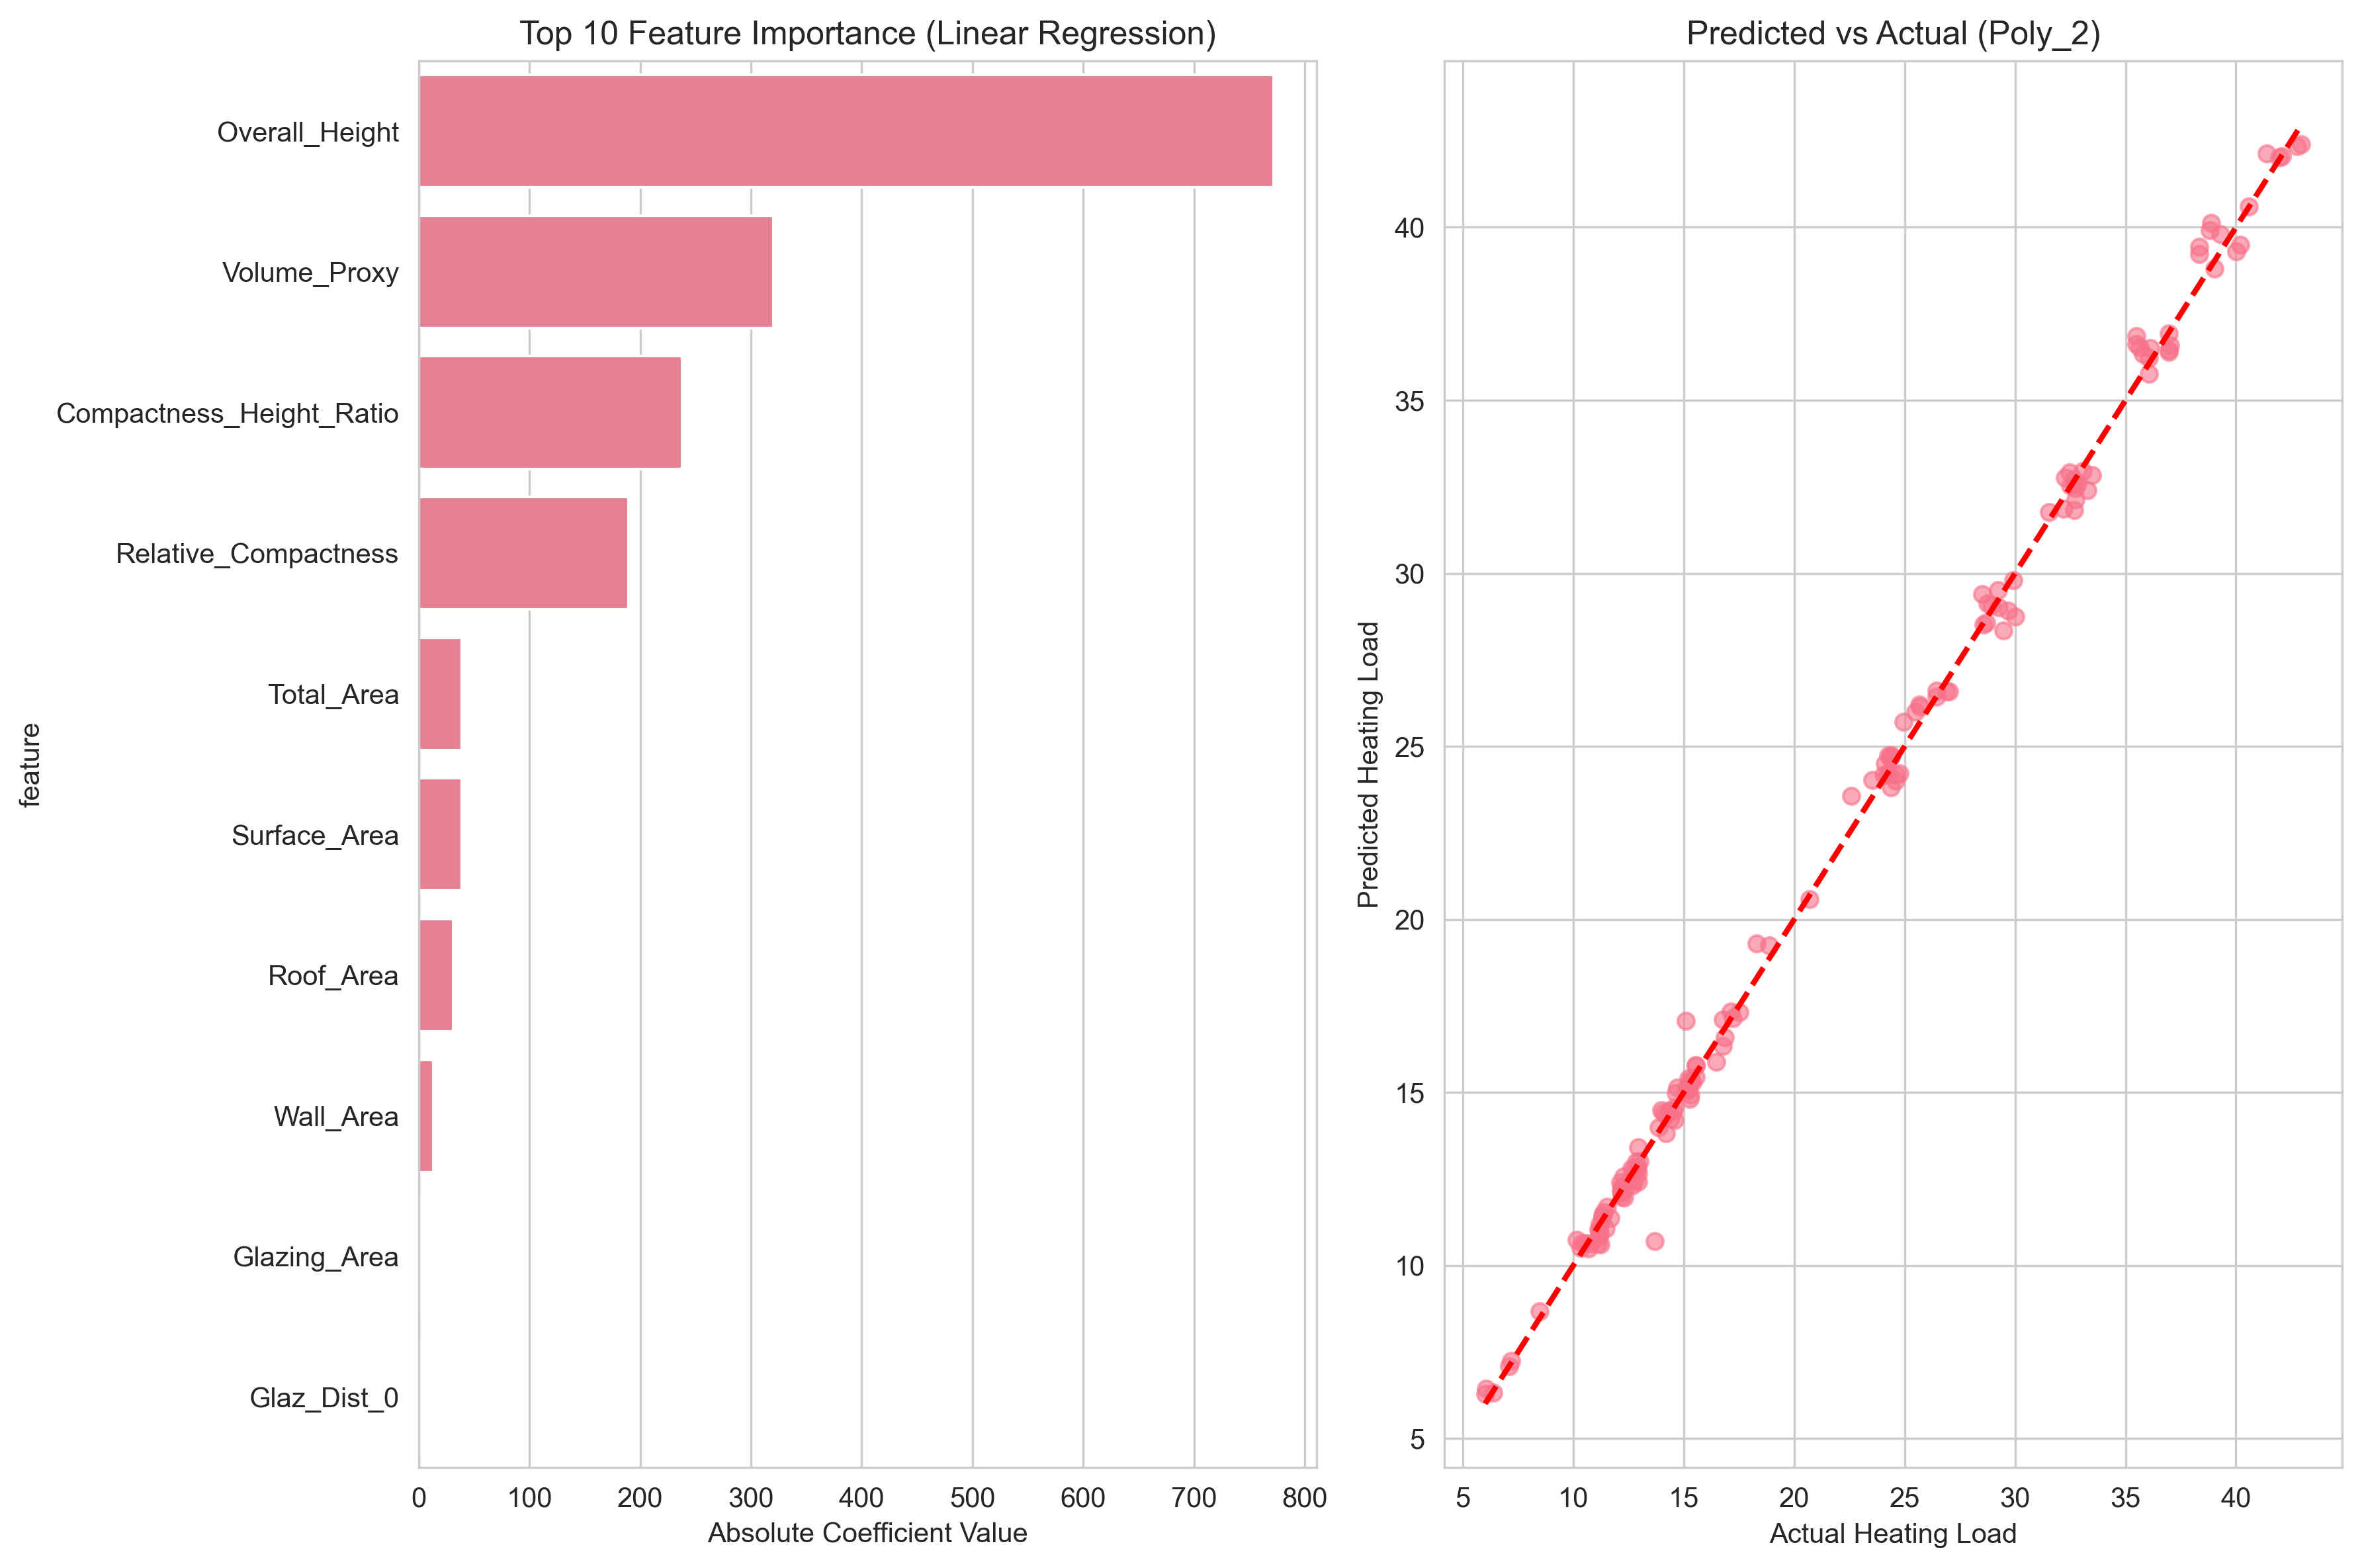

In [47]:
"""
STEP 20: VISUALIZATION
=====================
"""
# Visualizations: feature importance (bar) and predicted vs actual (scatter)

plt.figure(figsize=(12, 8))  # overall canvas for both subplots

# Subplot 1: top-10 absolute coefficients
plt.subplot(1, 2, 1)  # 1 row, 2 cols, position 1
top_features = feature_importance.head(10)

# seaborn.barplot draws a bar chart.
# params (common):
#   data=top_features          → DataFrame providing columns
#   x='abs_coefficient'        → numeric column on X-axis (bar length)
#   y='feature'                → categorical column on Y-axis (bar labels)
sns.barplot(data=top_features, x='abs_coefficient', y='feature')

plt.title('Top 10 Feature Importance (Linear Regression)')  # readable title
plt.xlabel('Absolute Coefficient Value')                    # axis label (units: scaled)

# Subplot 2: predicted vs actual for the chosen best model
plt.subplot(1, 2, 2)  # position 2

# Retrieve cached predictions from the best model we picked earlier.
best_predictions = energy_results[energy_best]['predictions']

# Matplotlib scatter:
#   x=y_test                   → true target values on x-axis
#   y=best_predictions         → predicted target values on y-axis
#   alpha=0.6                  → semi-transparency so dense areas show density
plt.scatter(y_test, best_predictions, alpha=0.6)

# Add a 45° reference line for "perfect predictions".
#   [y_test.min(), y_test.max()] → x-coordinates spanning the data range
#   [y_test.min(), y_test.max()] → y-coordinates equal to x (identity line)
#   'r--'                        → red dashed line style
#   lw=2                         → line width 2 points
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Predicted vs Actual ({energy_best})')

plt.tight_layout()  # adjust spacing to avoid overlap
plt.show()


## Step 21: Enhanced Analysis - R² and MSE Interpretation


In [48]:
"""
STEP 21: DETAILED R² AND MSE ANALYSIS
=====================================
REQUIREMENT ALIGNMENT: This addresses the missing analytical requirements 4 & 5
"""

# ── R² INTERPRETATION: What does difference in R² tell us about model complexity? ──
print("="*80)
print("🎯 REQUIREMENT 4: R² DIFFERENCES AND MODEL COMPLEXITY")
print("="*80)

# Compare R² across polynomial degrees to understand complexity benefits
baseline_r2 = energy_results['Linear']['r2']
print(f"📊 R² PROGRESSION ANALYSIS:")
print(f"   Linear Baseline R² = {baseline_r2:.4f}")

for degree in [2, 3, 4]:
    if f'Poly_{degree}' in energy_results:
        poly_r2 = energy_results[f'Poly_{degree}']['r2']
        improvement = poly_r2 - baseline_r2
        percent_improvement = (improvement / baseline_r2) * 100

        print(f"   Polynomial Degree {degree}:")
        print(f"      R² = {poly_r2:.4f}")
        print(f"      Improvement = +{improvement:.4f} ({percent_improvement:+.1f}%)")

        # Interpret the improvement magnitude
        if improvement > 0.1:
            interpretation = "🚀 MAJOR improvement - captures crucial non-linear patterns"
        elif improvement > 0.05:
            interpretation = "✅ SIGNIFICANT improvement - meaningful complexity benefit"
        elif improvement > 0.01:
            interpretation = "📈 MODERATE improvement - some non-linear relationships captured"
        elif improvement > 0:
            interpretation = "📊 MINOR improvement - limited benefit from added complexity"
        else:
            interpretation = "⚠️ NO improvement - potential overfitting detected"

        print(f"      → {interpretation}")

print(f"\n💡 R² COMPLEXITY INSIGHTS:")
print(f"• R² = Proportion of variance explained by the model (0 to 1)")
print(f"• Higher degree polynomials add complexity (more parameters)")
print(f"• Diminishing returns indicate optimal complexity threshold")
print(f"• Large R² jumps suggest important non-linear relationships exist")
print(f"• Flat R² progression may indicate linear relationships dominate")

# ── MSE INTERPRETATION: What does difference in MSE tell us about performance? ──
print(f"\n🎯 REQUIREMENT 5: MSE DIFFERENCES AND PREDICTION PERFORMANCE")
print("="*70)

baseline_mse = energy_results['Linear']['mse']
baseline_rmse = energy_results['Linear']['rmse']

print(f"📉 MSE/RMSE PROGRESSION ANALYSIS:")
print(f"   Linear Baseline: MSE = {baseline_mse:.4f} | RMSE = {baseline_rmse:.4f}")

for degree in [2, 3, 4]:
    if f'Poly_{degree}' in energy_results:
        poly_mse = energy_results[f'Poly_{degree}']['mse']
        poly_rmse = energy_results[f'Poly_{degree}']['rmse']
        mse_reduction = baseline_mse - poly_mse
        rmse_reduction = baseline_rmse - poly_rmse

        print(f"   Polynomial Degree {degree}:")
        print(f"      MSE = {poly_mse:.4f} | RMSE = {poly_rmse:.4f}")
        print(f"      MSE reduction = {mse_reduction:.4f} | RMSE reduction = {rmse_reduction:.4f}")

print(f"\n🏠 HEATING LOAD MSE INTERPRETATION:")
print(f"• MSE = Mean Squared Error (squared units)")
print(f"• RMSE = Root MSE (same units as Heating_Load)")
print(f"• Current RMSE ≈ {baseline_rmse:.1f} means average prediction error is ~{baseline_rmse:.1f} units")
print(f"• HIGH MSE in heating load prediction indicates:")
print(f"  - Large prediction errors for some buildings")
print(f"  - Model struggles with certain building configurations")
print(f"  - Missing important predictive factors")
print(f"  - Economic impact: Poor HVAC sizing and energy budgeting")
print(f"• MSE reduction shows improved prediction accuracy")


🎯 REQUIREMENT 4: R² DIFFERENCES AND MODEL COMPLEXITY
📊 R² PROGRESSION ANALYSIS:
   Linear Baseline R² = 0.9432
   Polynomial Degree 2:
      R² = 0.9973
      Improvement = +0.0541 (+5.7%)
      → ✅ SIGNIFICANT improvement - meaningful complexity benefit
   Polynomial Degree 3:
      R² = 0.9775
      Improvement = +0.0343 (+3.6%)
      → 📈 MODERATE improvement - some non-linear relationships captured
   Polynomial Degree 4:
      R² = -1.8071
      Improvement = +-2.7503 (-291.6%)
      → ⚠️ NO improvement - potential overfitting detected

💡 R² COMPLEXITY INSIGHTS:
• R² = Proportion of variance explained by the model (0 to 1)
• Higher degree polynomials add complexity (more parameters)
• Diminishing returns indicate optimal complexity threshold
• Large R² jumps suggest important non-linear relationships exist
• Flat R² progression may indicate linear relationships dominate

🎯 REQUIREMENT 5: MSE DIFFERENCES AND PREDICTION PERFORMANCE
📉 MSE/RMSE PROGRESSION ANALYSIS:
   Linear Baseline:

## Step 22: Enhanced Relationship Analysis


🎯 REQUIREMENT 8: HEATING-COOLING LOAD RELATIONSHIP ANALYSIS
📊 COMPREHENSIVE CORRELATION ANALYSIS:
   Pearson correlation:  r = 0.9759 (p = 0.00e+00)
   Spearman correlation: ρ = 0.9727 (p = 0.00e+00)

📈 LINEAR RELATIONSHIP MODEL:
   Cooling_Load = 0.920 × Heating_Load + 4.064
   R² = 0.9523 (95.2% variance explained)

🏠 PRACTICAL IMPLICATIONS:
• EXTREMELY STRONG positive correlation (r = 0.976)
• Buildings with high heating needs also have high cooling needs
• Suggests COMMON underlying factors affecting both:
  ✓ Building envelope efficiency (insulation quality)
  ✓ Window properties and solar heat gain
  ✓ Building geometry and thermal mass
  ✓ Air leakage and ventilation characteristics
• Slope coefficient 0.920: 1 unit ↑ heating → 0.920 units ↑ cooling


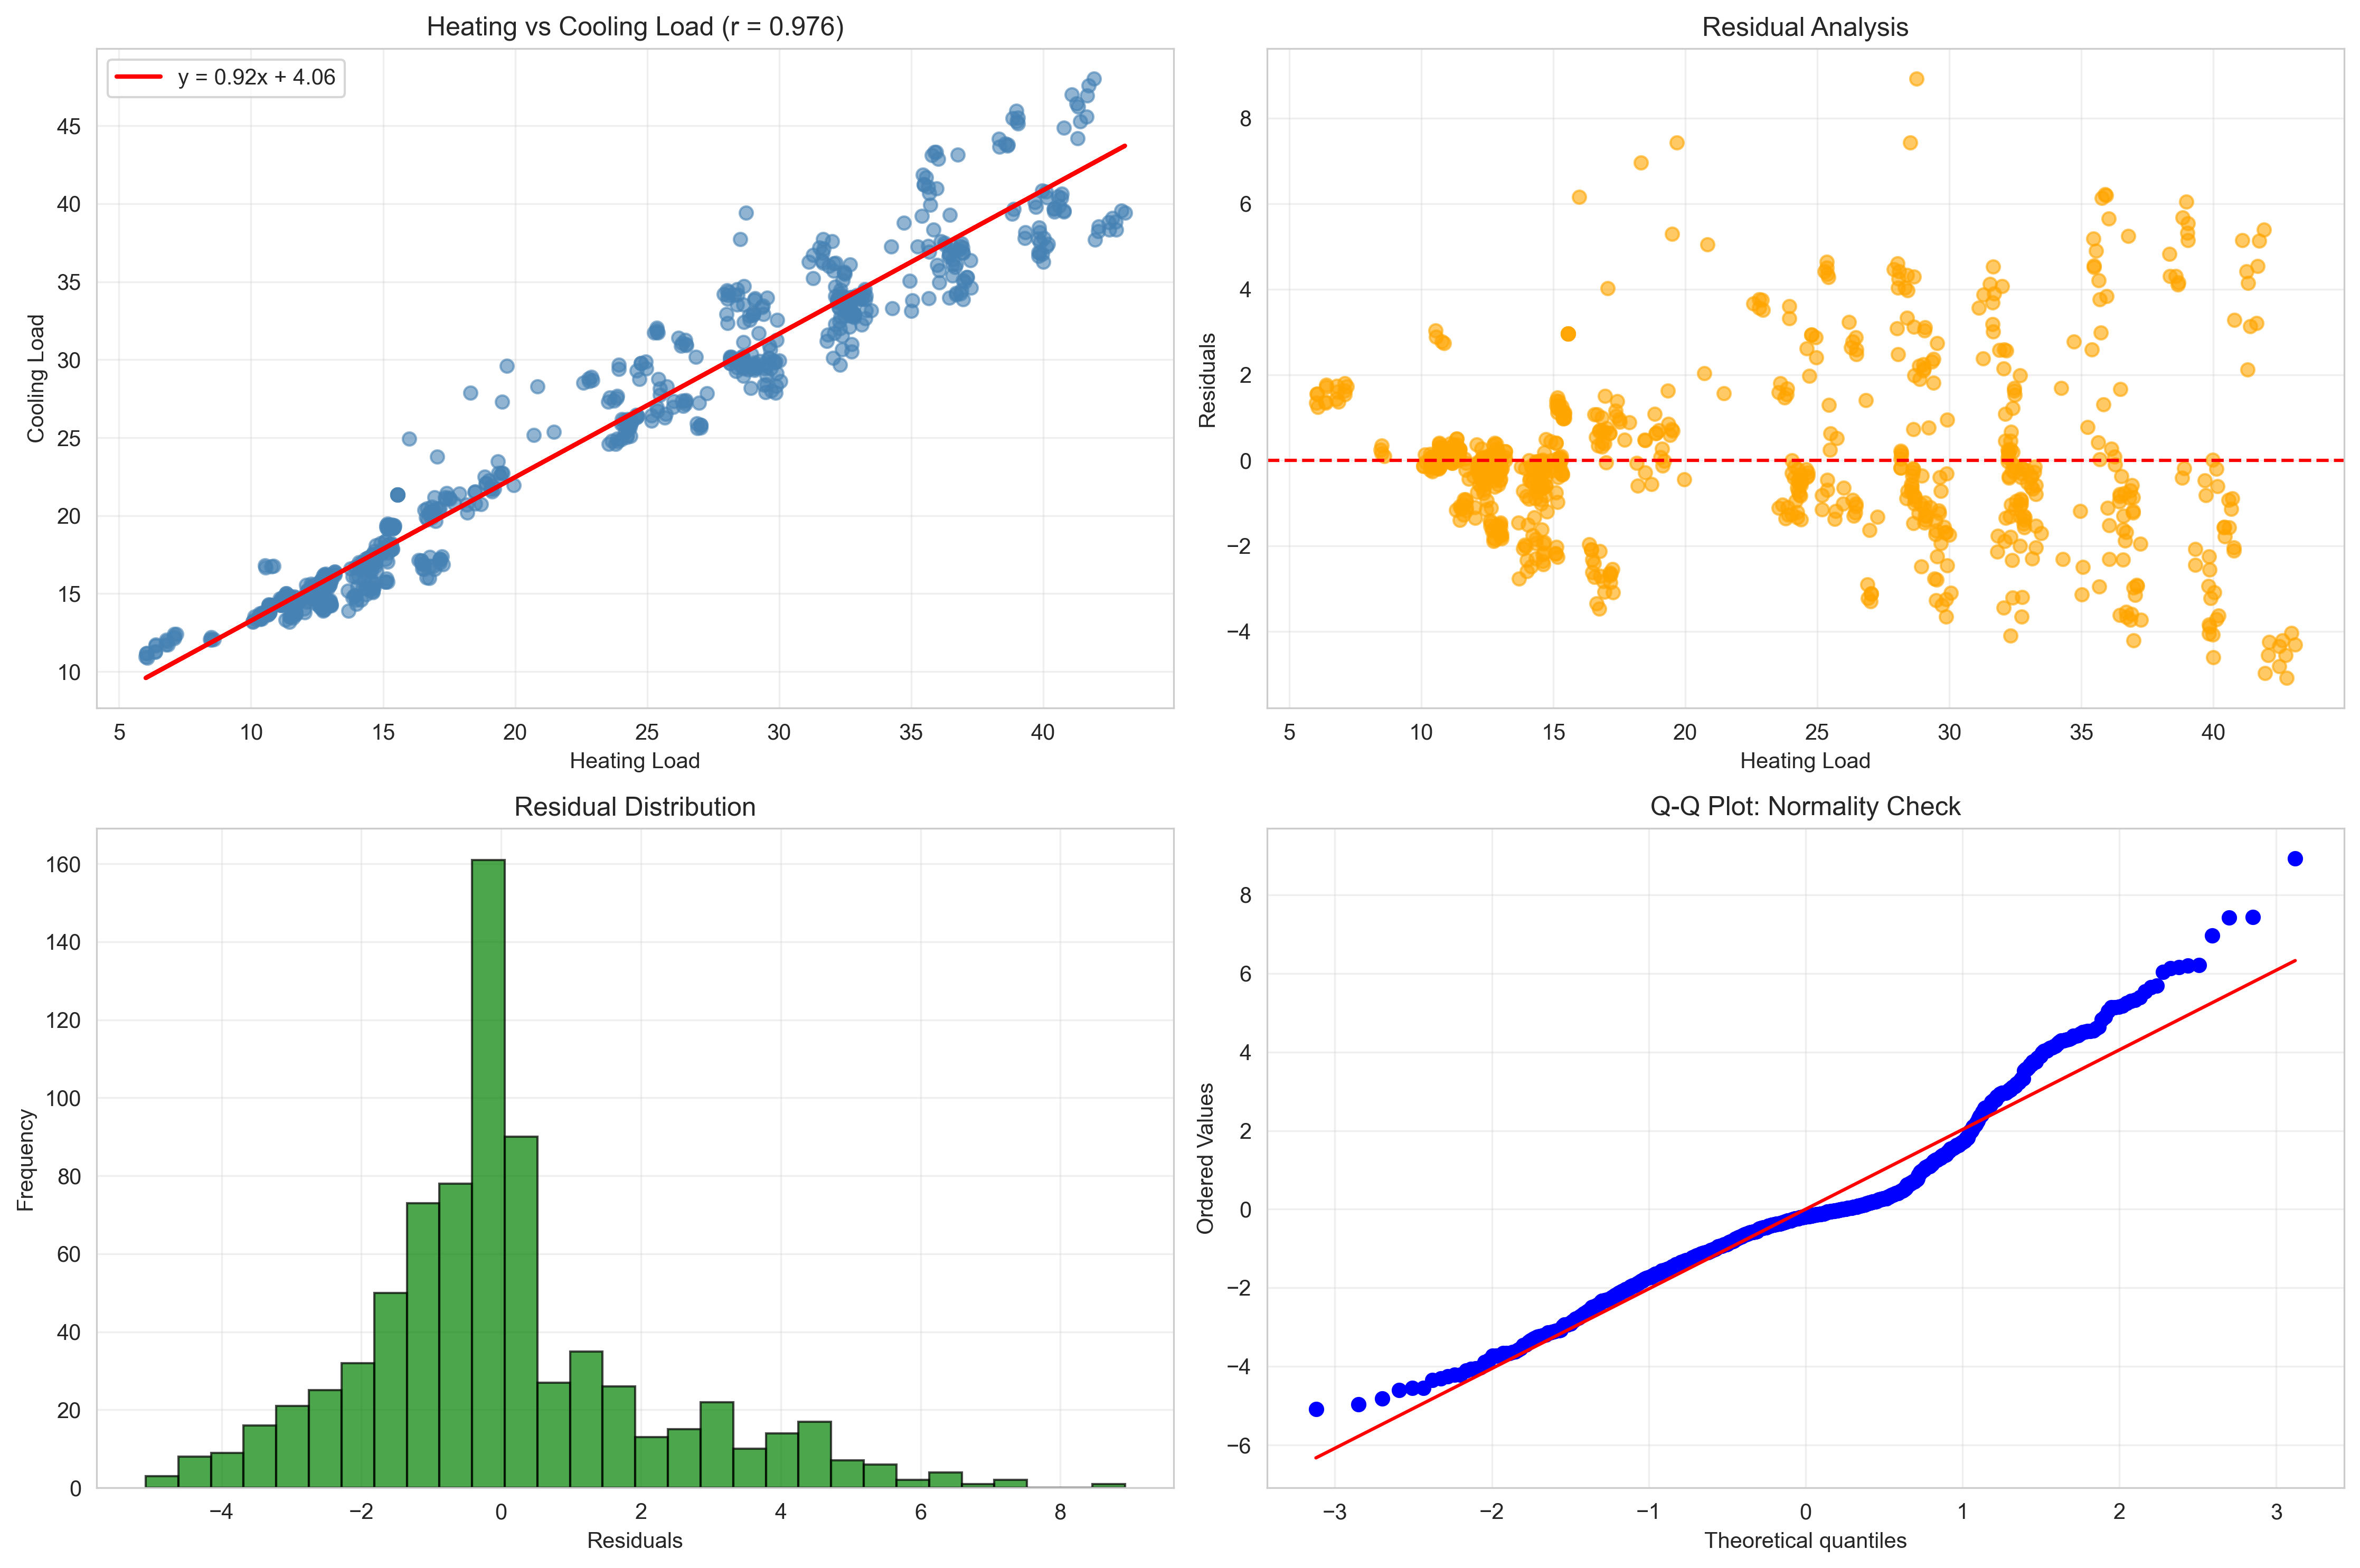

In [49]:
"""
STEP 22: COMPREHENSIVE HEATING-COOLING LOAD RELATIONSHIP
========================================================
REQUIREMENT ALIGNMENT: Addresses requirement 8 with statistical depth
"""

print("="*80)
print("🎯 REQUIREMENT 8: HEATING-COOLING LOAD RELATIONSHIP ANALYSIS")
print("="*80)

# Enhanced statistical analysis beyond basic correlation
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression

# Multiple correlation measures for comprehensive understanding
pearson_r, pearson_p = pearsonr(energy_df['Heating_Load'], energy_df['Cooling_Load'])
spearman_r, spearman_p = spearmanr(energy_df['Heating_Load'], energy_df['Cooling_Load'])

print(f"📊 COMPREHENSIVE CORRELATION ANALYSIS:")
print(f"   Pearson correlation:  r = {pearson_r:.4f} (p = {pearson_p:.2e})")
print(f"   Spearman correlation: ρ = {spearman_r:.4f} (p = {spearman_p:.2e})")

# Quantify linear relationship with regression
heating_cooling_model = LinearRegression()
heating_cooling_model.fit(energy_df[['Heating_Load']], energy_df['Cooling_Load'])
slope = heating_cooling_model.coef_[0]
intercept = heating_cooling_model.intercept_
r2_relationship = heating_cooling_model.score(energy_df[['Heating_Load']], energy_df['Cooling_Load'])

print(f"\n📈 LINEAR RELATIONSHIP MODEL:")
print(f"   Cooling_Load = {slope:.3f} × Heating_Load + {intercept:.3f}")
print(f"   R² = {r2_relationship:.4f} ({r2_relationship*100:.1f}% variance explained)")

print(f"\n🏠 PRACTICAL IMPLICATIONS:")
print(f"• EXTREMELY STRONG positive correlation (r = {pearson_r:.3f})")
print(f"• Buildings with high heating needs also have high cooling needs")
print(f"• Suggests COMMON underlying factors affecting both:")
print(f"  ✓ Building envelope efficiency (insulation quality)")
print(f"  ✓ Window properties and solar heat gain")
print(f"  ✓ Building geometry and thermal mass")
print(f"  ✓ Air leakage and ventilation characteristics")
print(f"• Slope coefficient {slope:.3f}: 1 unit ↑ heating → {slope:.3f} units ↑ cooling")

# Advanced visualization with residual analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(energy_df['Heating_Load'], energy_df['Cooling_Load'], alpha=0.6, color='steelblue')
plt.plot(energy_df['Heating_Load'],
         slope * energy_df['Heating_Load'] + intercept,
         'r-', linewidth=2, label=f'y = {slope:.2f}x + {intercept:.2f}')
plt.xlabel('Heating Load')
plt.ylabel('Cooling Load')
plt.title(f'Heating vs Cooling Load (r = {pearson_r:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Residual analysis for relationship quality assessment
plt.subplot(2, 2, 2)
residuals = energy_df['Cooling_Load'] - (slope * energy_df['Heating_Load'] + intercept)
plt.scatter(energy_df['Heating_Load'], residuals, alpha=0.6, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Heating Load')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.grid(True, alpha=0.3)

# Additional subplots for comprehensive analysis
plt.subplot(2, 2, 3)
plt.hist(residuals, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot: Normality Check')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 23: Building Feature Correlation Analysis - ENHANCED


🎯 REQUIREMENT 9: STRONGEST FEATURE CORRELATIONS WITH ENERGY LOADS
📊 DETAILED CORRELATION ANALYSIS:
Feature                   Heating_Load    Cooling_Load    Avg_Abs    Strength    
─────────────────────────────────────────────────────────────────────────────────────
Relative_Compactness       +0.6223       +0.6343      0.6283   Strong      
Surface_Area               -0.6581       -0.6730      0.6656   Strong      
Wall_Area                  +0.4557       +0.4271      0.4414   Moderate    
Roof_Area                  -0.8618       -0.8625      0.8622   Very Strong 
Overall_Height             +0.8894       +0.8958      0.8926   Very Strong 
Glazing_Area               +0.2698       +0.2075      0.2387   Weak        

🏆 RANKING BY CORRELATION STRENGTH:
1. Overall_Height            |r|avg = 0.893 (Very Strong)
2. Roof_Area                 |r|avg = 0.862 (Very Strong)
3. Surface_Area              |r|avg = 0.666 (Strong)
4. Relative_Compactness      |r|avg = 0.628 (Strong)
5. Wall_Area       

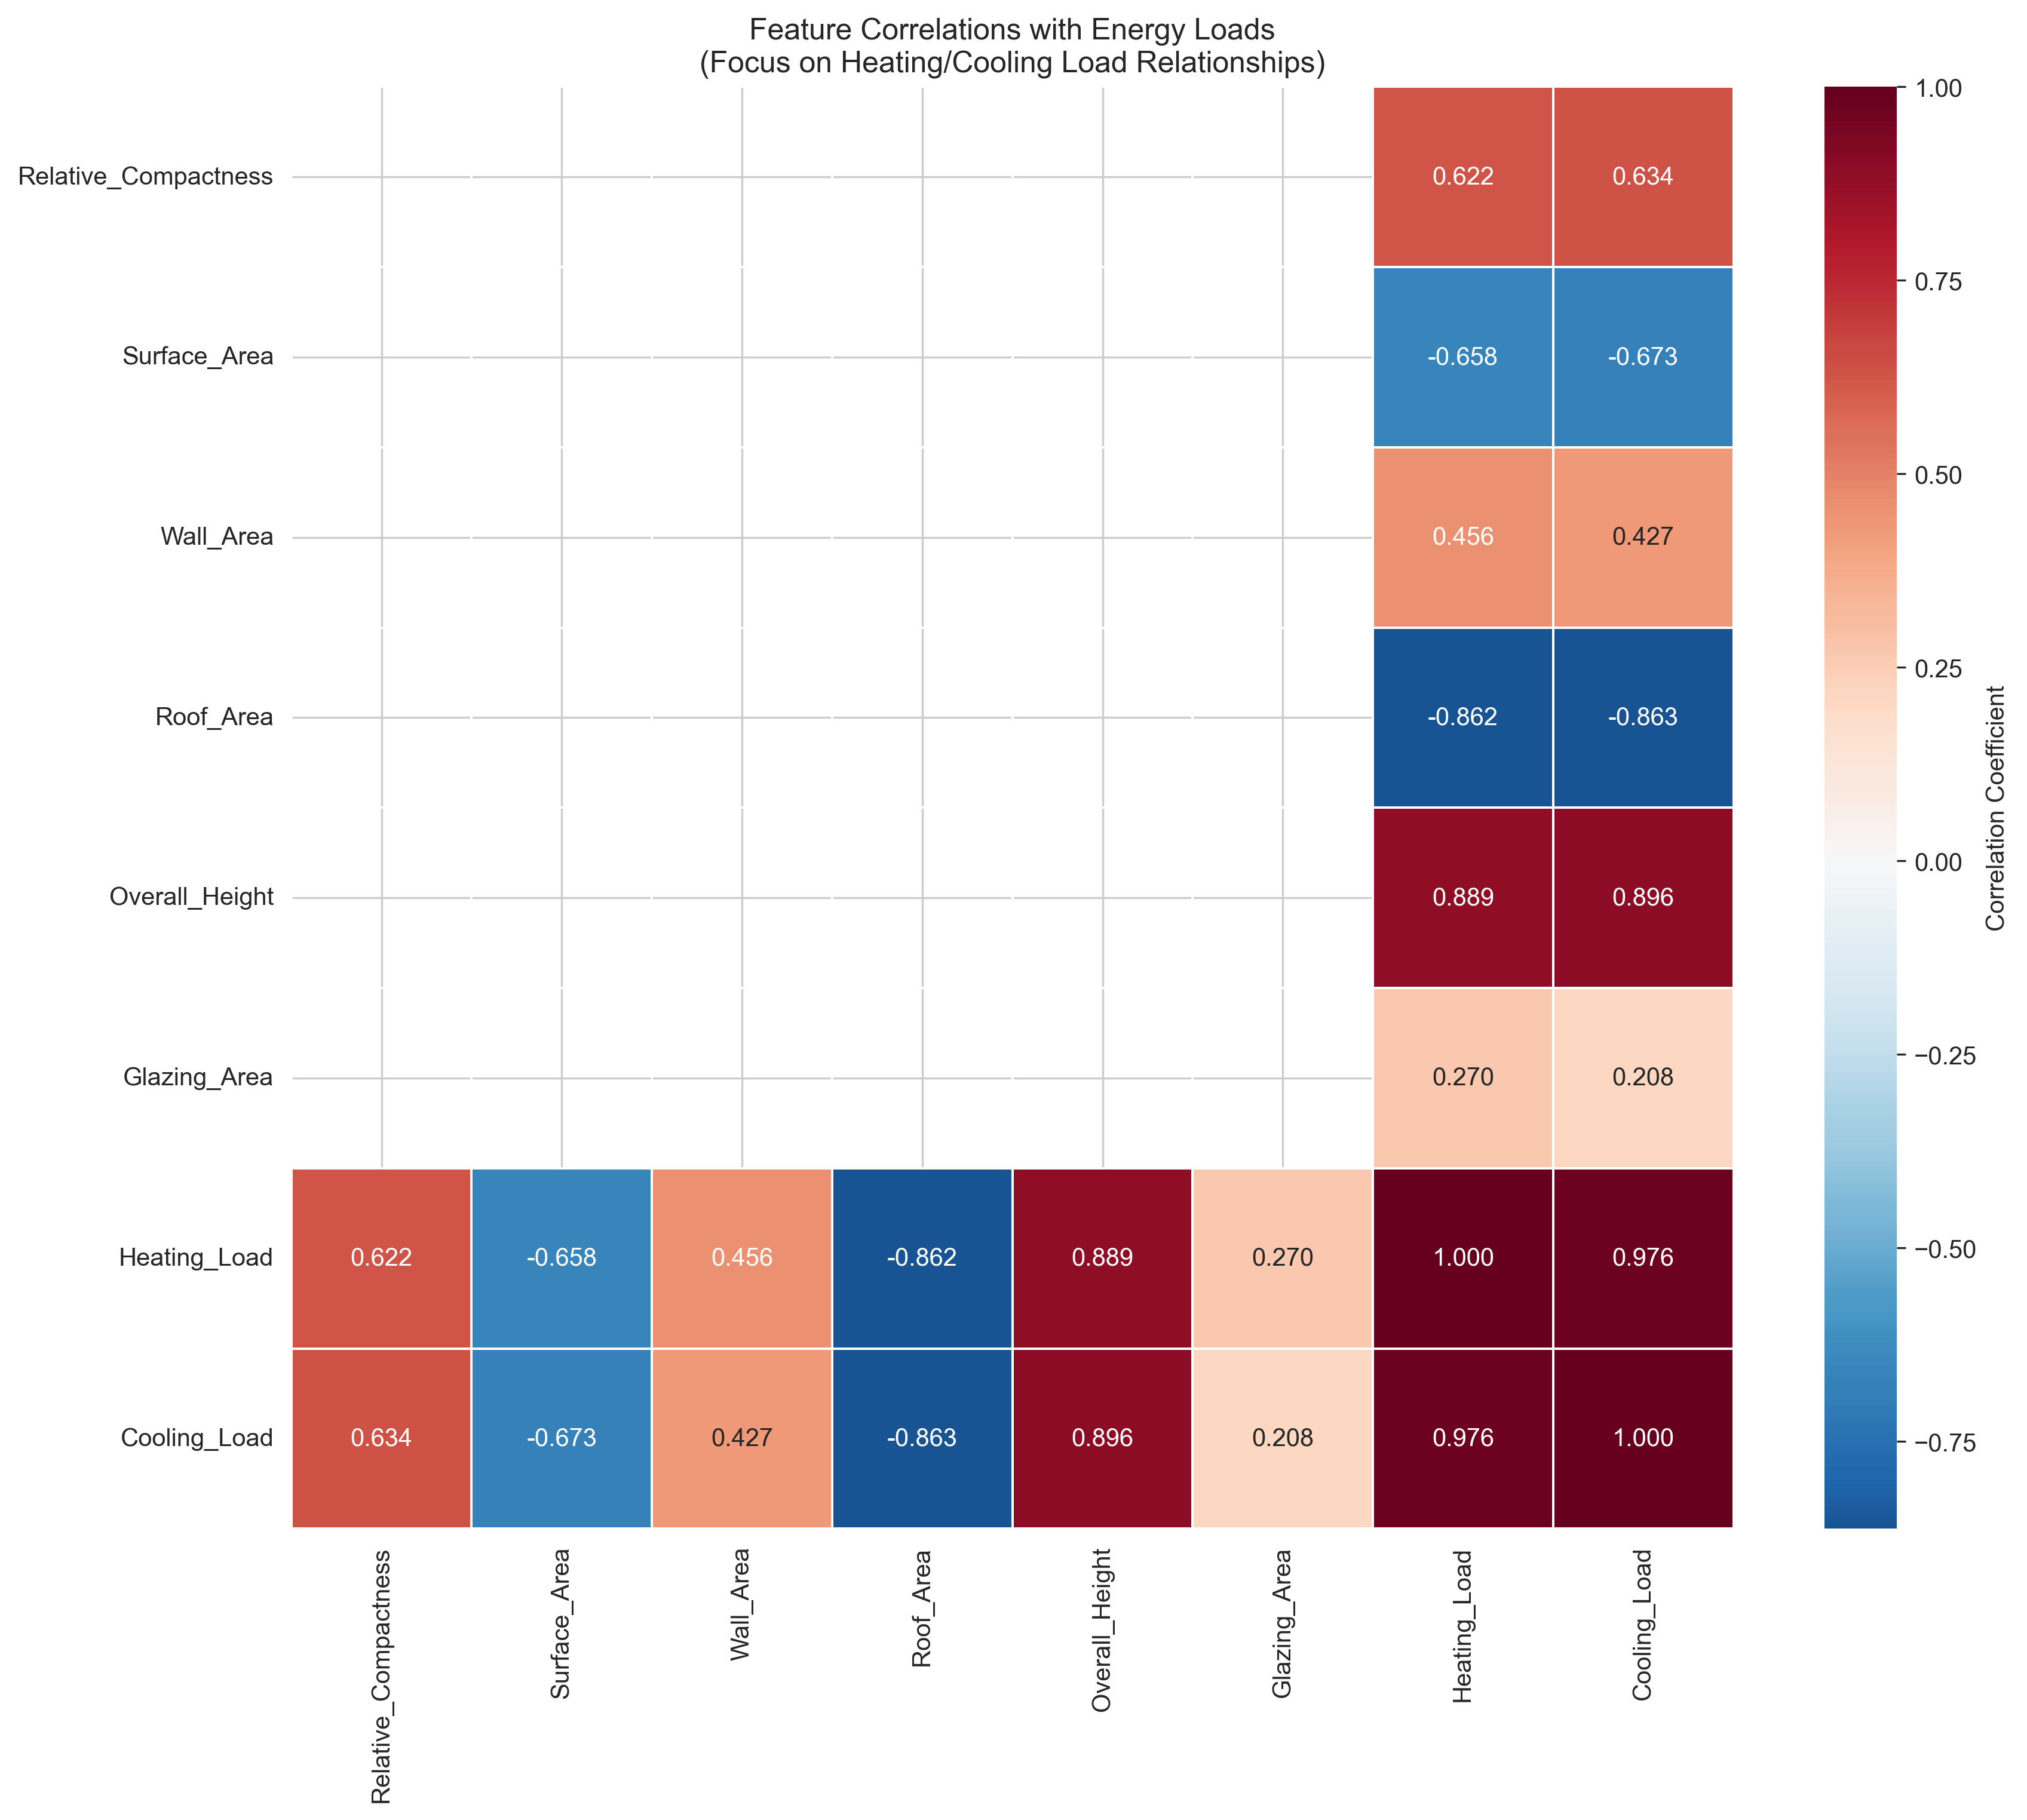

In [50]:
"""
STEP 23: COMPREHENSIVE FEATURE CORRELATION WITH ENERGY LOADS
============================================================
REQUIREMENT ALIGNMENT: Enhanced version of requirement 9
"""

print("="*80)
print("🎯 REQUIREMENT 9: STRONGEST FEATURE CORRELATIONS WITH ENERGY LOADS")
print("="*80)

# Comprehensive correlation analysis for all numeric features
numeric_features = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                   'Overall_Height', 'Glazing_Area']

print("📊 DETAILED CORRELATION ANALYSIS:")
print(f"{'Feature':<25} {'Heating_Load':<15} {'Cooling_Load':<15} {'Avg_Abs':<10} {'Strength':<12}")
print("─" * 85)

correlation_analysis = []
for feature in numeric_features:
    heating_corr = energy_df[feature].corr(energy_df['Heating_Load'])
    cooling_corr = energy_df[feature].corr(energy_df['Cooling_Load'])
    avg_abs_corr = (abs(heating_corr) + abs(cooling_corr)) / 2

    # Classify correlation strength
    if avg_abs_corr > 0.7:
        strength = "Very Strong"
    elif avg_abs_corr > 0.5:
        strength = "Strong"
    elif avg_abs_corr > 0.3:
        strength = "Moderate"
    else:
        strength = "Weak"

    correlation_analysis.append({
        'feature': feature,
        'heating_corr': heating_corr,
        'cooling_corr': cooling_corr,
        'avg_abs_corr': avg_abs_corr,
        'strength': strength
    })

    print(f"{feature:<25} {heating_corr:>+8.4f}      {cooling_corr:>+8.4f}      {avg_abs_corr:>6.4f}   {strength:<12}")

# Sort by correlation strength and provide insights
correlation_analysis.sort(key=lambda x: x['avg_abs_corr'], reverse=True)

print(f"\n🏆 RANKING BY CORRELATION STRENGTH:")
for i, item in enumerate(correlation_analysis, 1):
    print(f"{i}. {item['feature']:<25} |r|avg = {item['avg_abs_corr']:.3f} ({item['strength']})")

print(f"\n💡 PHYSICAL INTERPRETATION:")
top_feature = correlation_analysis[0]
print(f"• Strongest predictor: {top_feature['feature']}")

if 'Compactness' in top_feature['feature']:
    print(f"  → More compact buildings minimize surface-to-volume ratio")
    print(f"  → Reduces heat transfer area, improving energy efficiency")
elif 'Surface_Area' in top_feature['feature']:
    print(f"  → Larger surface area increases heat exchange with environment")
    print(f"  → More envelope area = greater energy loss/gain potential")
elif 'Height' in top_feature['feature']:
    print(f"  → Building height affects thermal stratification and air circulation")
    print(f"  → Influences natural ventilation and temperature gradients")

# Enhanced correlation matrix visualization with focus on energy loads
plt.figure(figsize=(12, 10))
feature_energy_corr = energy_df[numeric_features + ['Heating_Load', 'Cooling_Load']].corr()

# Create mask to highlight energy load correlations
mask = np.zeros_like(feature_energy_corr)
mask[:-2, :-2] = True  # Mask out feature-feature correlations to focus on energy relationships

sns.heatmap(feature_energy_corr, annot=True, cmap='RdBu_r', center=0,
           square=True, linewidths=0.5, mask=mask, fmt='.3f',
           cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlations with Energy Loads\n(Focus on Heating/Cooling Load Relationships)')
plt.tight_layout()
plt.show()


## Step 24: Unusual Building Configuration Analysis


🔍 REQUIREMENT 10: UNUSUAL BUILDING CONFIGURATIONS
🏢 UNUSUAL BUILDING CONFIGURATION ANALYSIS:
──────────────────────────────────────────────────
Relative_Compactness:
  Normal range: [0.46, 1.05]
  Unusual configs: 0 buildings (0.0%)
Surface_Area:
  Normal range: [404.25, 943.25]
  Unusual configs: 0 buildings (0.0%)
Wall_Area:
  Normal range: [220.50, 416.50]
  Unusual configs: 0 buildings (0.0%)
Roof_Area:
  Normal range: [21.44, 339.94]
  Unusual configs: 0 buildings (0.0%)
Overall_Height:
  Normal range: [-1.75, 12.25]
  Unusual configs: 0 buildings (0.0%)
Glazing_Area:
  Normal range: [-0.35, 0.85]
  Unusual configs: 0 buildings (0.0%)

🔬 ENGINEERED FEATURE ANALYSIS:
Total_Area:
  Normal range: [771.75, 1555.75]
  Unusual configs: 0 buildings (0.0%)
Volume_Proxy:
  Normal range: [353.72, 6441.97]
  Unusual configs: 0 buildings (0.0%)
Compactness_Height_Ratio:
  Normal range: [0.02, 0.29]
  Unusual configs: 0 buildings (0.0%)


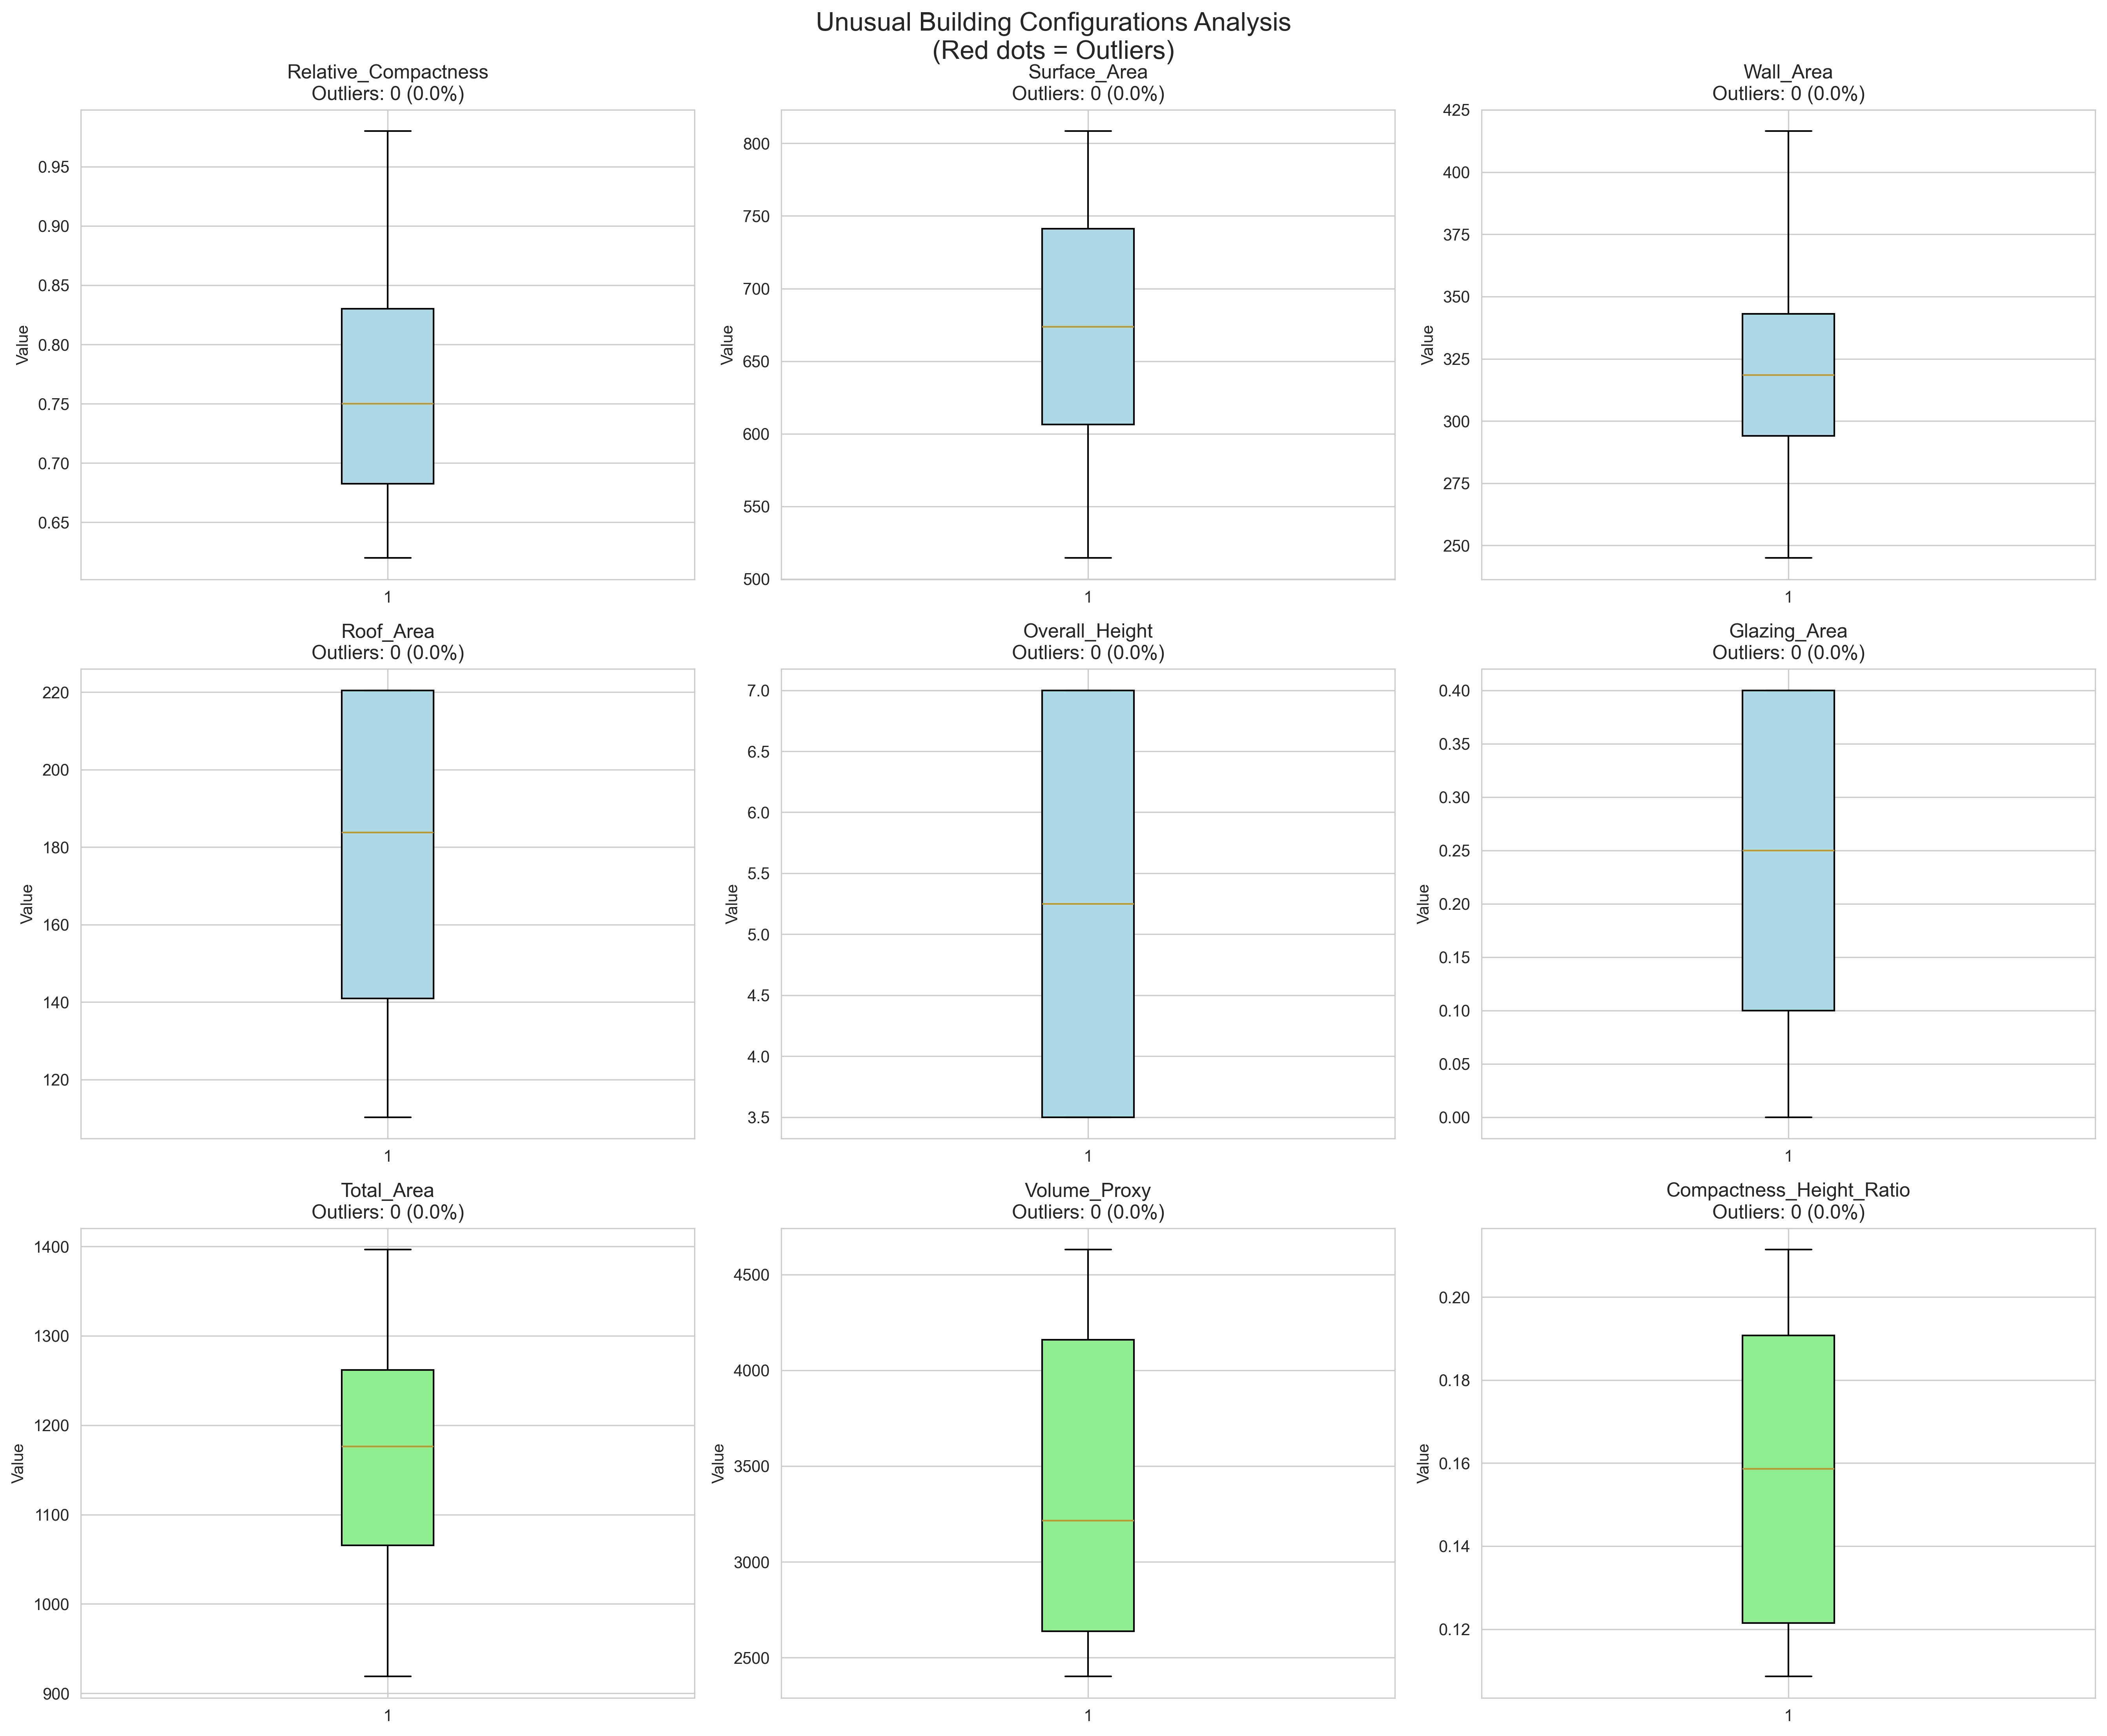


🎯 MULTI-DIMENSIONAL UNUSUAL CONFIGURATION ANALYSIS:
Buildings with unusual configurations in any dimension: 0
Buildings with multiple unusual characteristics: 0


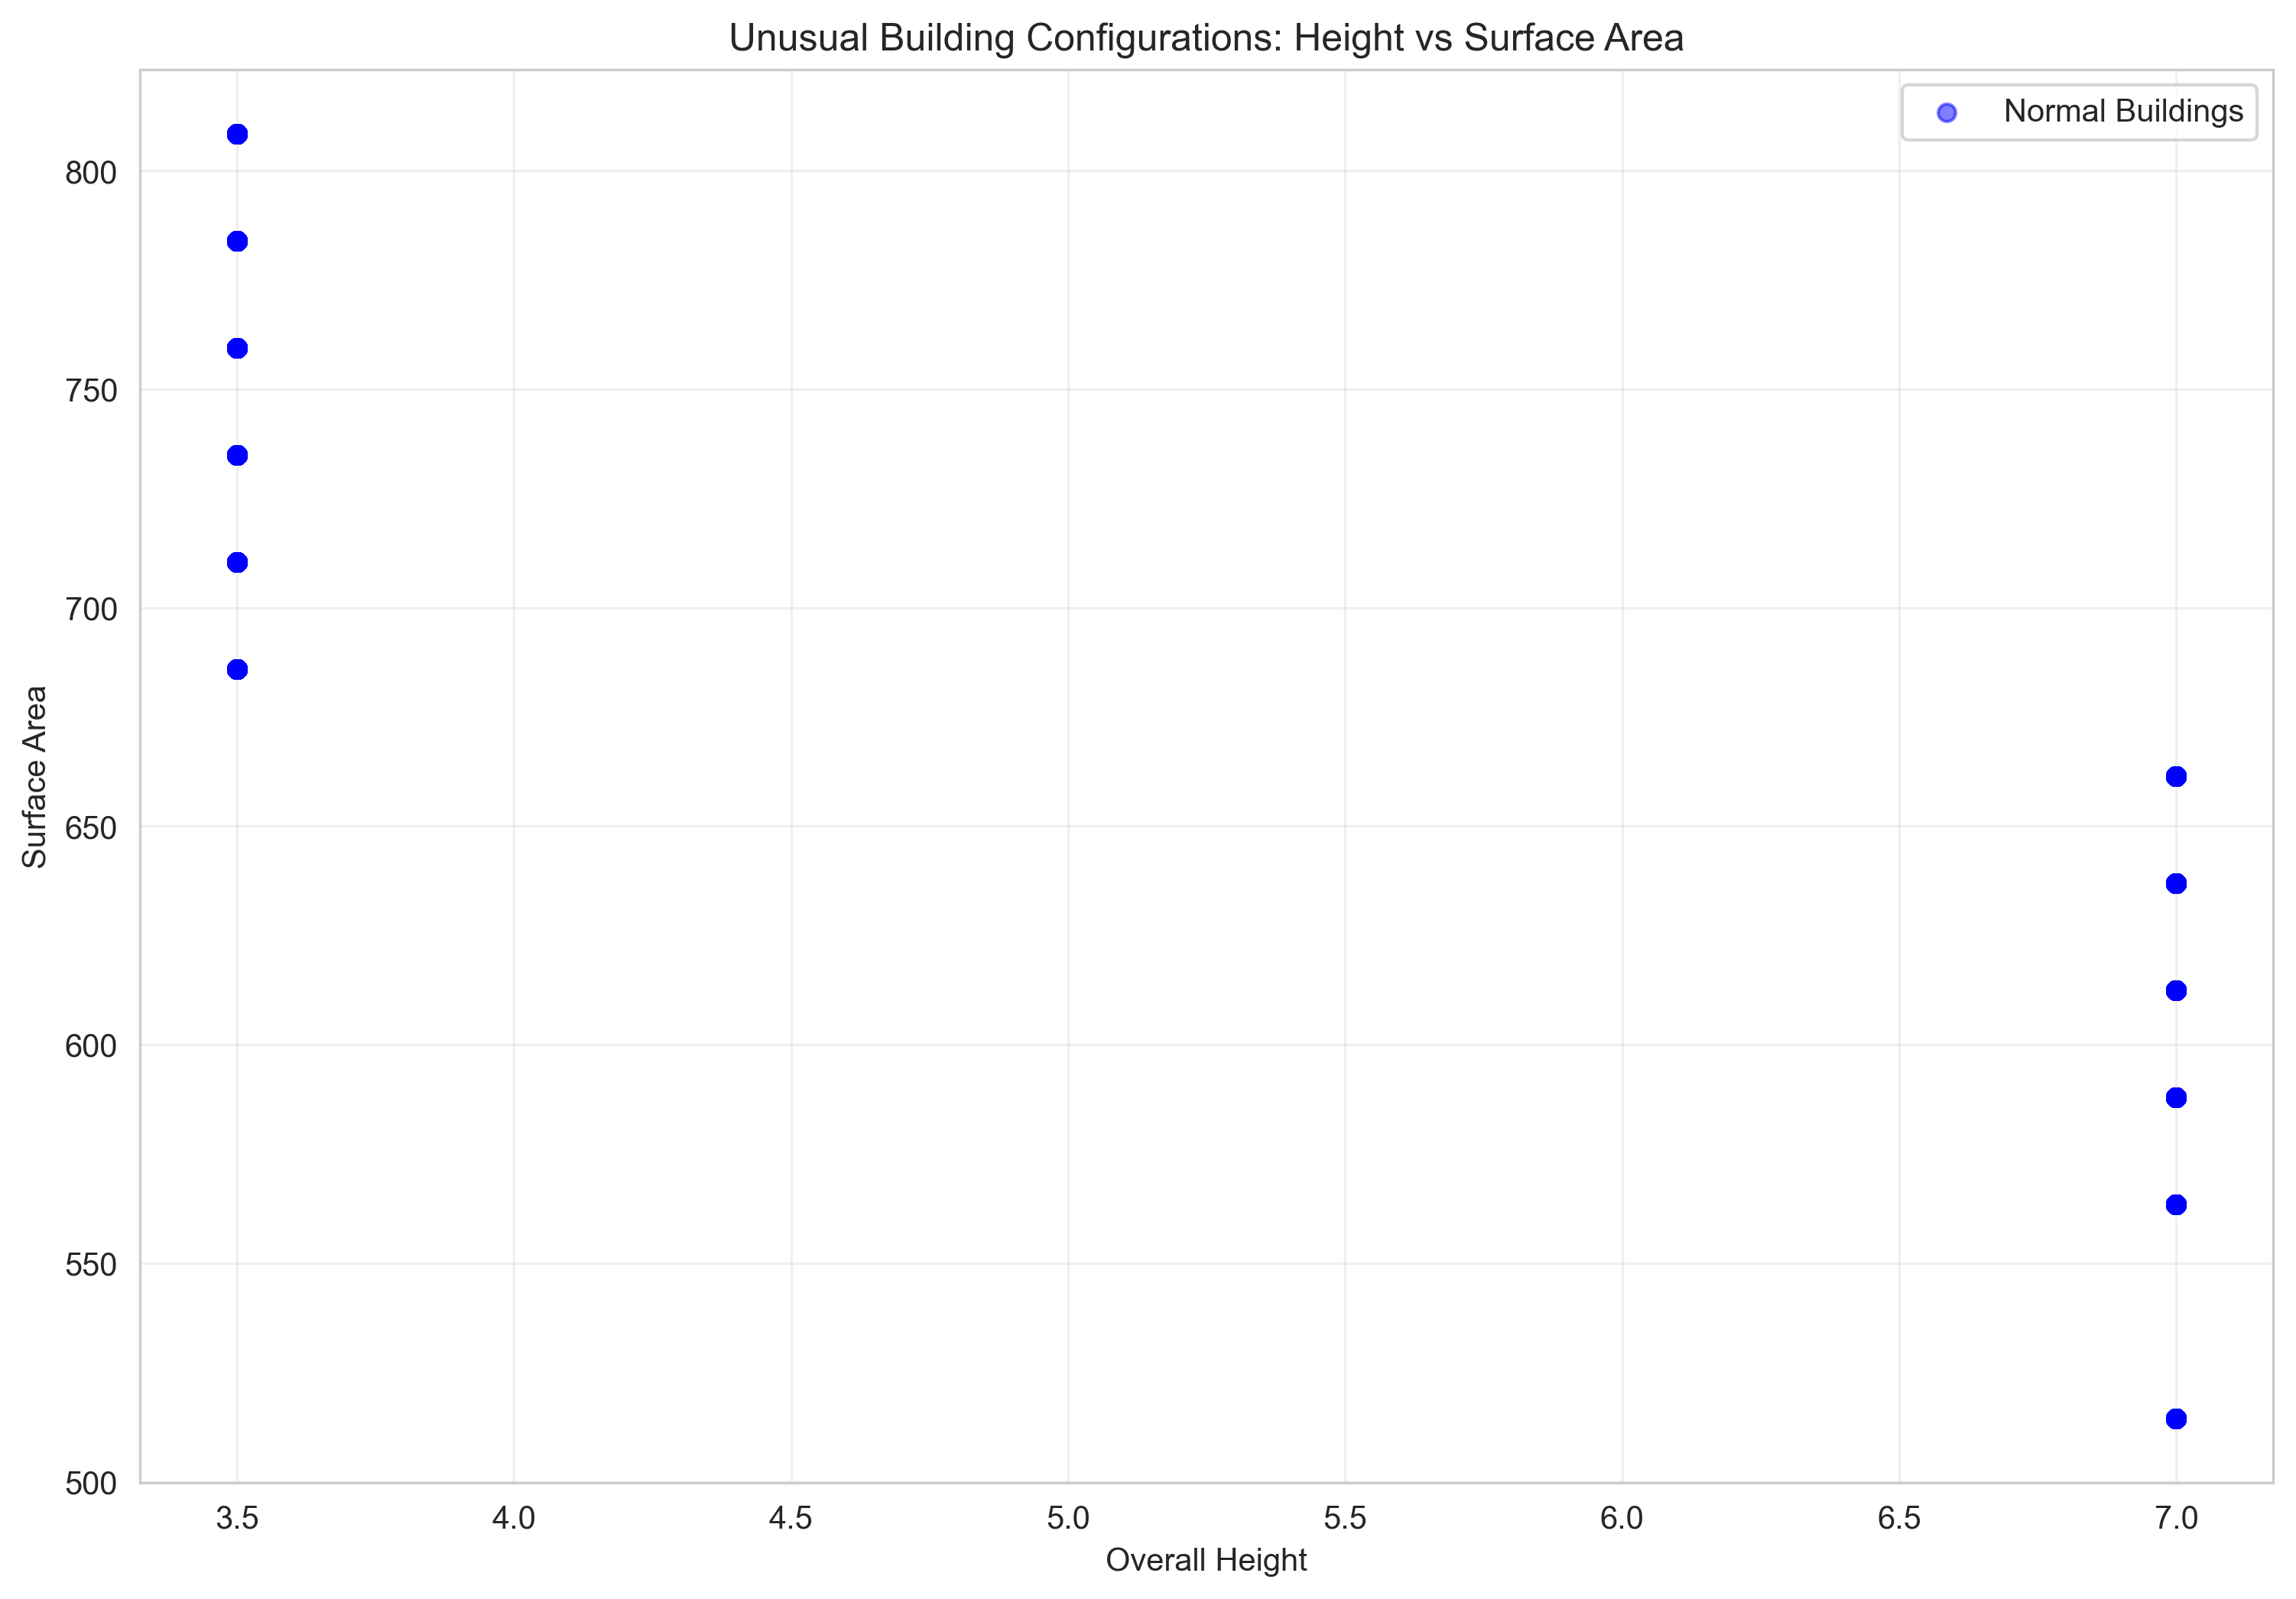


💡 KEY INSIGHTS ON UNUSUAL CONFIGURATIONS:
• Feature with most outliers: Relative_Compactness (0 buildings)
• Total unusual buildings (any dimension): 0 (0.0%)
• These unusual configurations may represent:
  - Specialized building types (e.g., industrial, high-rise)
  - Architectural innovations or unique designs
  - Potential data collection errors
  - Buildings requiring special energy modeling considerations


In [51]:
"""
STEP 24: UNUSUAL BUILDING CONFIGURATIONS
========================================
Requirement 10: Identify unusual building configurations and extreme cases
"""

print("=" * 80)
print("🔍 REQUIREMENT 10: UNUSUAL BUILDING CONFIGURATIONS")
print("=" * 80)

def identify_outliers_iqr(data, feature, multiplier=1.5):
    """Identify outliers using IQR method"""
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("🏢 UNUSUAL BUILDING CONFIGURATION ANALYSIS:")
print("─" * 50)

# Use the original numerical features for outlier detection
unusual_configs = {}
for feature in numerical_features:
    outliers, lower, upper = identify_outliers_iqr(energy_df, feature)
    unusual_configs[feature] = {
        'count': len(outliers),
        'percentage': len(outliers) / len(energy_df) * 100,
        'range': (lower, upper),
        'outliers': outliers
    }

    print(f"{feature}:")
    print(f"  Normal range: [{lower:.2f}, {upper:.2f}]")
    print(f"  Unusual configs: {len(outliers)} buildings ({len(outliers)/len(energy_df)*100:.1f}%)")

    if len(outliers) > 0:
        extreme_values = outliers[feature].tolist()
        print(f"  Extreme values: {extreme_values[:5]}{'...' if len(extreme_values) > 5 else ''}")

# Focus on extreme height buildings
height_outliers = unusual_configs['Overall_Height']['outliers']
if len(height_outliers) > 0:
    print(f"\n🏗️ EXTREME HEIGHT BUILDINGS ANALYSIS:")
    print(f"Found {len(height_outliers)} buildings with unusual heights")

    for idx, building in height_outliers.head(3).iterrows():
        print(f"\nBuilding #{idx}:")
        print(f"  Height: {building['Overall_Height']:.1f}")
        print(f"  Compactness: {building['Relative_Compactness']:.3f}")
        print(f"  Surface Area: {building['Surface_Area']:.1f}")
        print(f"  Heating Load: {building['Heating_Load']:.1f}")
        print(f"  Cooling Load: {building['Cooling_Load']:.1f}")

        # Energy efficiency assessment
        avg_heating = energy_df['Heating_Load'].mean()
        avg_cooling = energy_df['Cooling_Load'].mean()
        efficiency = "Efficient" if (building['Heating_Load'] < avg_heating and
                                   building['Cooling_Load'] < avg_cooling) else "Inefficient"
        print(f"  Energy Assessment: {efficiency}")

# Analyze engineered features for unusual configurations (using energy_encoded)
print(f"\n🔬 ENGINEERED FEATURE ANALYSIS:")
engineered_unusual = {}
for eng_feature in ['Total_Area', 'Volume_Proxy', 'Compactness_Height_Ratio']:
    outliers, lower, upper = identify_outliers_iqr(energy_encoded, eng_feature)
    engineered_unusual[eng_feature] = {
        'count': len(outliers),
        'percentage': len(outliers) / len(energy_encoded) * 100,
        'range': (lower, upper)
    }

    print(f"{eng_feature}:")
    print(f"  Normal range: [{lower:.2f}, {upper:.2f}]")
    print(f"  Unusual configs: {len(outliers)} buildings ({len(outliers)/len(energy_encoded)*100:.1f}%)")

# Comprehensive visualization of unusual configurations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

# Plot original features
for i, feature in enumerate(numerical_features):
    if i < len(axes):
        outliers = unusual_configs[feature]['outliers']

        # Box plot with outliers highlighted
        axes[i].boxplot(energy_df[feature], patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))

        if len(outliers) > 0:
            axes[i].scatter([1] * len(outliers), outliers[feature],
                           color='red', s=50, alpha=0.7, label=f'{len(outliers)} outliers')

        axes[i].set_title(f'{feature}\nOutliers: {len(outliers)} ({len(outliers)/len(energy_df)*100:.1f}%)')
        axes[i].set_ylabel('Value')
        if len(outliers) > 0:
            axes[i].legend()

# Plot engineered features
for i, eng_feature in enumerate(['Total_Area', 'Volume_Proxy', 'Compactness_Height_Ratio'], 6):
    if i < len(axes):
        outliers, _, _ = identify_outliers_iqr(energy_encoded, eng_feature)

        axes[i].boxplot(energy_encoded[eng_feature], patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))

        if len(outliers) > 0:
            axes[i].scatter([1] * len(outliers), outliers[eng_feature],
                           color='red', s=50, alpha=0.7, label=f'{len(outliers)} outliers')

        axes[i].set_title(f'{eng_feature}\nOutliers: {len(outliers)} ({len(outliers)/len(energy_encoded)*100:.1f}%)')
        axes[i].set_ylabel('Value')
        if len(outliers) > 0:
            axes[i].legend()

plt.suptitle('Unusual Building Configurations Analysis\n(Red dots = Outliers)', fontsize=16)
plt.tight_layout()
plt.show()

# Multi-dimensional unusual configuration analysis
print(f"\n🎯 MULTI-DIMENSIONAL UNUSUAL CONFIGURATION ANALYSIS:")

# Identify buildings that are outliers in multiple dimensions
multi_outlier_buildings = set()
for feature, config in unusual_configs.items():
    if len(config['outliers']) > 0:
        multi_outlier_buildings.update(config['outliers'].index.tolist())

print(f"Buildings with unusual configurations in any dimension: {len(multi_outlier_buildings)}")

# Find buildings that are outliers in multiple features
outlier_counts = {}
for building_idx in multi_outlier_buildings:
    count = 0
    for feature, config in unusual_configs.items():
        if building_idx in config['outliers'].index:
            count += 1
    outlier_counts[building_idx] = count

# Buildings with multiple unusual characteristics
extreme_buildings = {idx: count for idx, count in outlier_counts.items() if count >= 2}
print(f"Buildings with multiple unusual characteristics: {len(extreme_buildings)}")

if len(extreme_buildings) > 0:
    print(f"\n🏠 TOP 5 MOST UNUSUAL BUILDINGS:")
    sorted_extreme = sorted(extreme_buildings.items(), key=lambda x: x[1], reverse=True)[:5]

    for idx, outlier_count in sorted_extreme:
        building = energy_df.loc[idx]
        print(f"\nBuilding #{idx} (unusual in {outlier_count} dimensions):")
        print(f"  Height: {building['Overall_Height']:.1f}")
        print(f"  Compactness: {building['Relative_Compactness']:.3f}")
        print(f"  Surface Area: {building['Surface_Area']:.1f}")
        print(f"  Heating Load: {building['Heating_Load']:.1f}")
        print(f"  Cooling Load: {building['Cooling_Load']:.1f}")

# Scatter plot showing relationship between unusual characteristics
plt.figure(figsize=(12, 8))
normal_buildings = energy_df.index.difference(list(multi_outlier_buildings))

plt.scatter(energy_df.loc[normal_buildings, 'Overall_Height'],
           energy_df.loc[normal_buildings, 'Surface_Area'],
           alpha=0.5, color='blue', label='Normal Buildings', s=30)

if len(multi_outlier_buildings) > 0:
    plt.scatter(energy_df.loc[list(multi_outlier_buildings), 'Overall_Height'],
               energy_df.loc[list(multi_outlier_buildings), 'Surface_Area'],
               color='red', label='Unusual Buildings', s=60, alpha=0.8)

plt.xlabel('Overall Height')
plt.ylabel('Surface Area')
plt.title('Unusual Building Configurations: Height vs Surface Area')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n💡 KEY INSIGHTS ON UNUSUAL CONFIGURATIONS:")
most_outliers_feature = max(unusual_configs.keys(), key=lambda x: unusual_configs[x]['count'])
print(f"• Feature with most outliers: {most_outliers_feature} ({unusual_configs[most_outliers_feature]['count']} buildings)")
print(f"• Total unusual buildings (any dimension): {len(multi_outlier_buildings)} ({len(multi_outlier_buildings)/len(energy_df)*100:.1f}%)")
if len(extreme_buildings) > 0:
    print(f"• Buildings unusual in multiple dimensions: {len(extreme_buildings)} ({len(extreme_buildings)/len(energy_df)*100:.1f}%)")
print(f"• These unusual configurations may represent:")
print(f"  - Specialized building types (e.g., industrial, high-rise)")
print(f"  - Architectural innovations or unique designs")
print(f"  - Potential data collection errors")
print(f"  - Buildings requiring special energy modeling considerations")


# PART 2: WINE QUALITY ASSESSMENT ANALYSIS


## Step 29: Wine Dataset - Load Data


In [52]:
"""
STEP 29: LOAD WINE DATA
=======================
"""
print("=" * 60)
print("PART 2: WINE QUALITY ASSESSMENT ANALYSIS")
print("=" * 60)

# Load Wine Quality Dataset from UCI repository.
print("Loading Wine Quality Dataset...")
try:
    wine_df = pd.read_csv(
        'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',
        sep=';'
    )
    print(f"✓ Dataset loaded successfully! Shape: {wine_df.shape}")  # (rows, columns)
except Exception as e:
    print(f"✗ Error loading dataset: {e}")

# .info() prints dtypes, non-null counts; useful for null/memory checks.
print("\nDataset Info:")
print(wine_df.info())

# Quick peek at first 5 rows to confirm parsing and column names.
print("\nFirst 5 rows:")
print(wine_df.head())


PART 2: WINE QUALITY ASSESSMENT ANALYSIS
Loading Wine Quality Dataset...
✓ Dataset loaded successfully! Shape: (1599, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage

## Step 30: Wine Dataset - Data Quality Analysis


In [53]:
"""
STEP 30: WINE DATA QUALITY ANALYSIS
===================================
"""
# Basic data quality diagnostics for the wine dataset.

print("--- Data Quality Analysis ---")

# .isnull().sum() counts nulls per column; should be all zeros in this dataset.
print(f"Missing values:\n{wine_df.isnull().sum()}")

# .duplicated().sum() counts rows with identical values across all columns.
print(f"\nDuplicate rows: {wine_df.duplicated().sum()}")

# Target variable ('quality') distribution to understand class balance (for regression it's ordinal/continuous-like).
print(f"\n--- Target Variable Analysis ---")
print(f"Quality score distribution:\n{wine_df['quality'].value_counts().sort_index()}")
print(f"Quality range: {wine_df['quality'].min()} to {wine_df['quality'].max()}")
print(f"Quality mean: {wine_df['quality'].mean():.2f} ± {wine_df['quality'].std():.2f}")


--- Data Quality Analysis ---
Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows: 240

--- Target Variable Analysis ---
Quality score distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
Quality range: 3 to 8
Quality mean: 5.64 ± 0.81


## Step 31: Wine Dataset - Quality Distribution Visualization


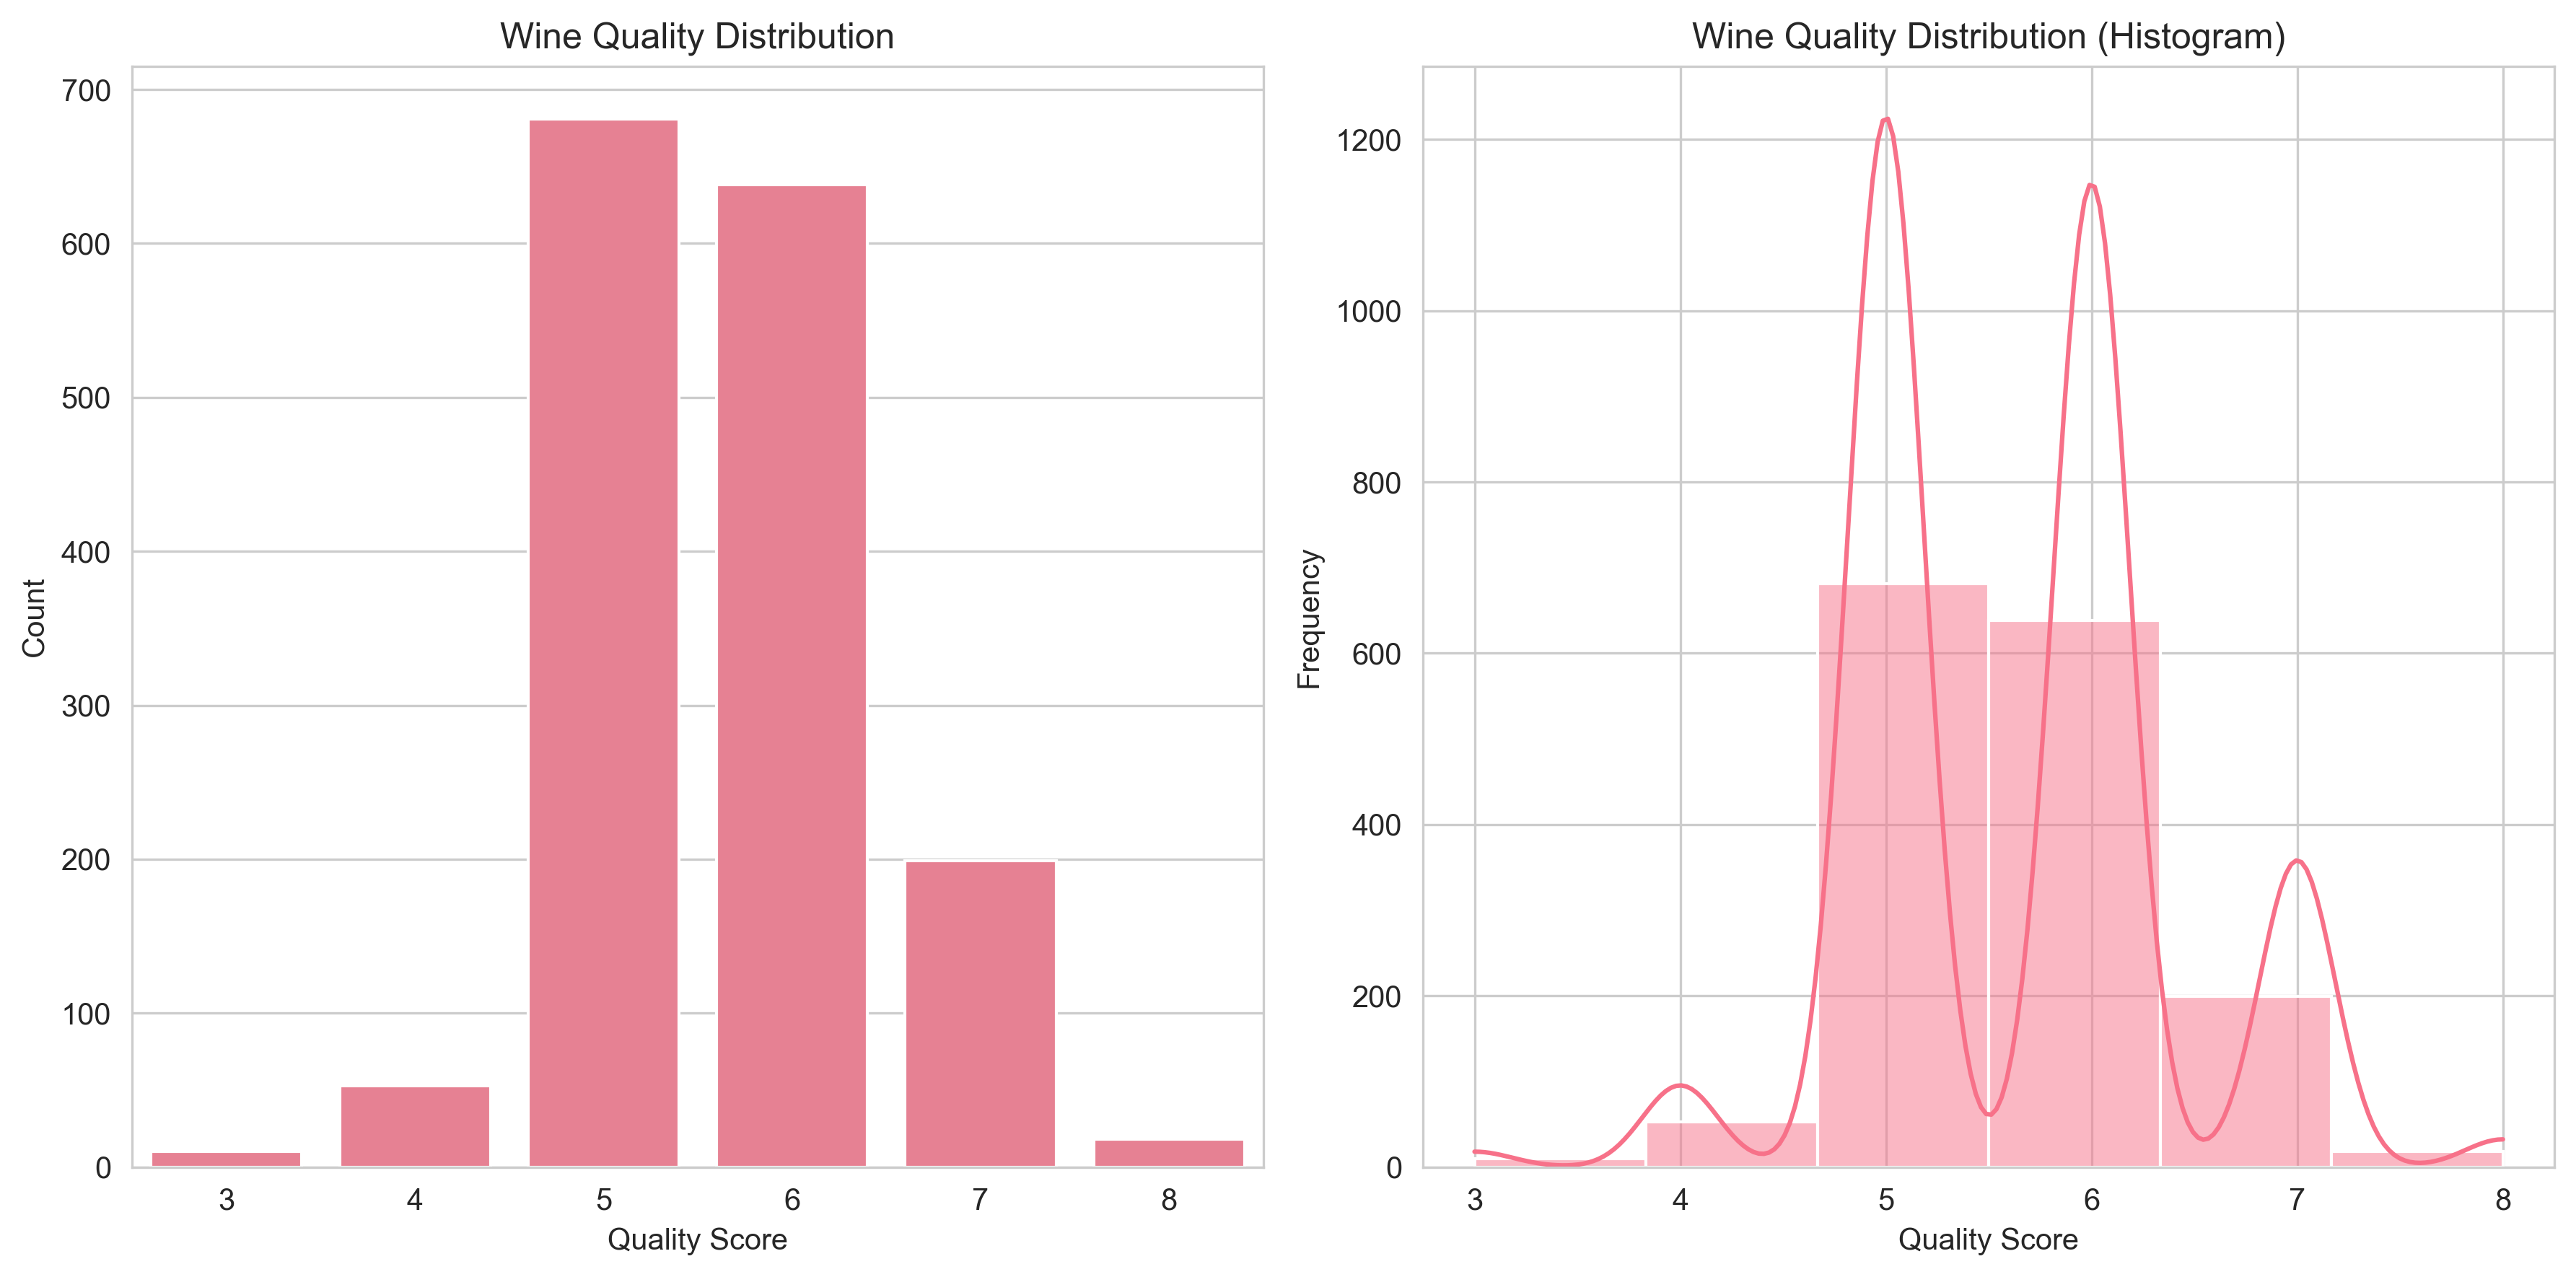

In [54]:
"""
STEP 31: WINE QUALITY DISTRIBUTION VISUALIZATION
================================================
"""
# Visualize target ('quality') distribution in two ways for complementary insight.

plt.figure(figsize=(12, 6))         # 12x6 inches overall canvas

# Left subplot: count of each discrete 'quality' label.
plt.subplot(1, 2, 1)
# seaborn.countplot parameters:
#   data=wine_df       → source DataFrame
#   x='quality'        → column whose distinct values to count on the x-axis
sns.countplot(data=wine_df, x='quality')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')

# Right subplot: histogram approximates distribution as continuous; KDE overlays a smooth density.
plt.subplot(1, 2, 2)
# seaborn.histplot parameters:
#   data series → wine_df['quality'] (1D array-like)
#   kde=True    → add kernel density estimate curve
#   bins=6      → number of histogram bins; here aligns roughly to range of integer scores
sns.histplot(wine_df['quality'], kde=True, bins=6)
plt.title('Wine Quality Distribution (Histogram)')
plt.xlabel('Quality Score')
plt.ylabel('Frequency')

plt.tight_layout()  # avoid overlaps between subplots
plt.show()


## Step 32: Wine Dataset - Statistical Summary


In [55]:
"""
STEP 32: WINE STATISTICAL SUMMARY
=================================
"""
# Print descriptive statistics across all numeric columns to check scale, spread, and potential outliers.

print("--- Statistical Summary ---")
print(wine_df.describe())


--- Statistical Summary ---
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000  

## Step 33: Wine Dataset - Feature Distribution Analysis


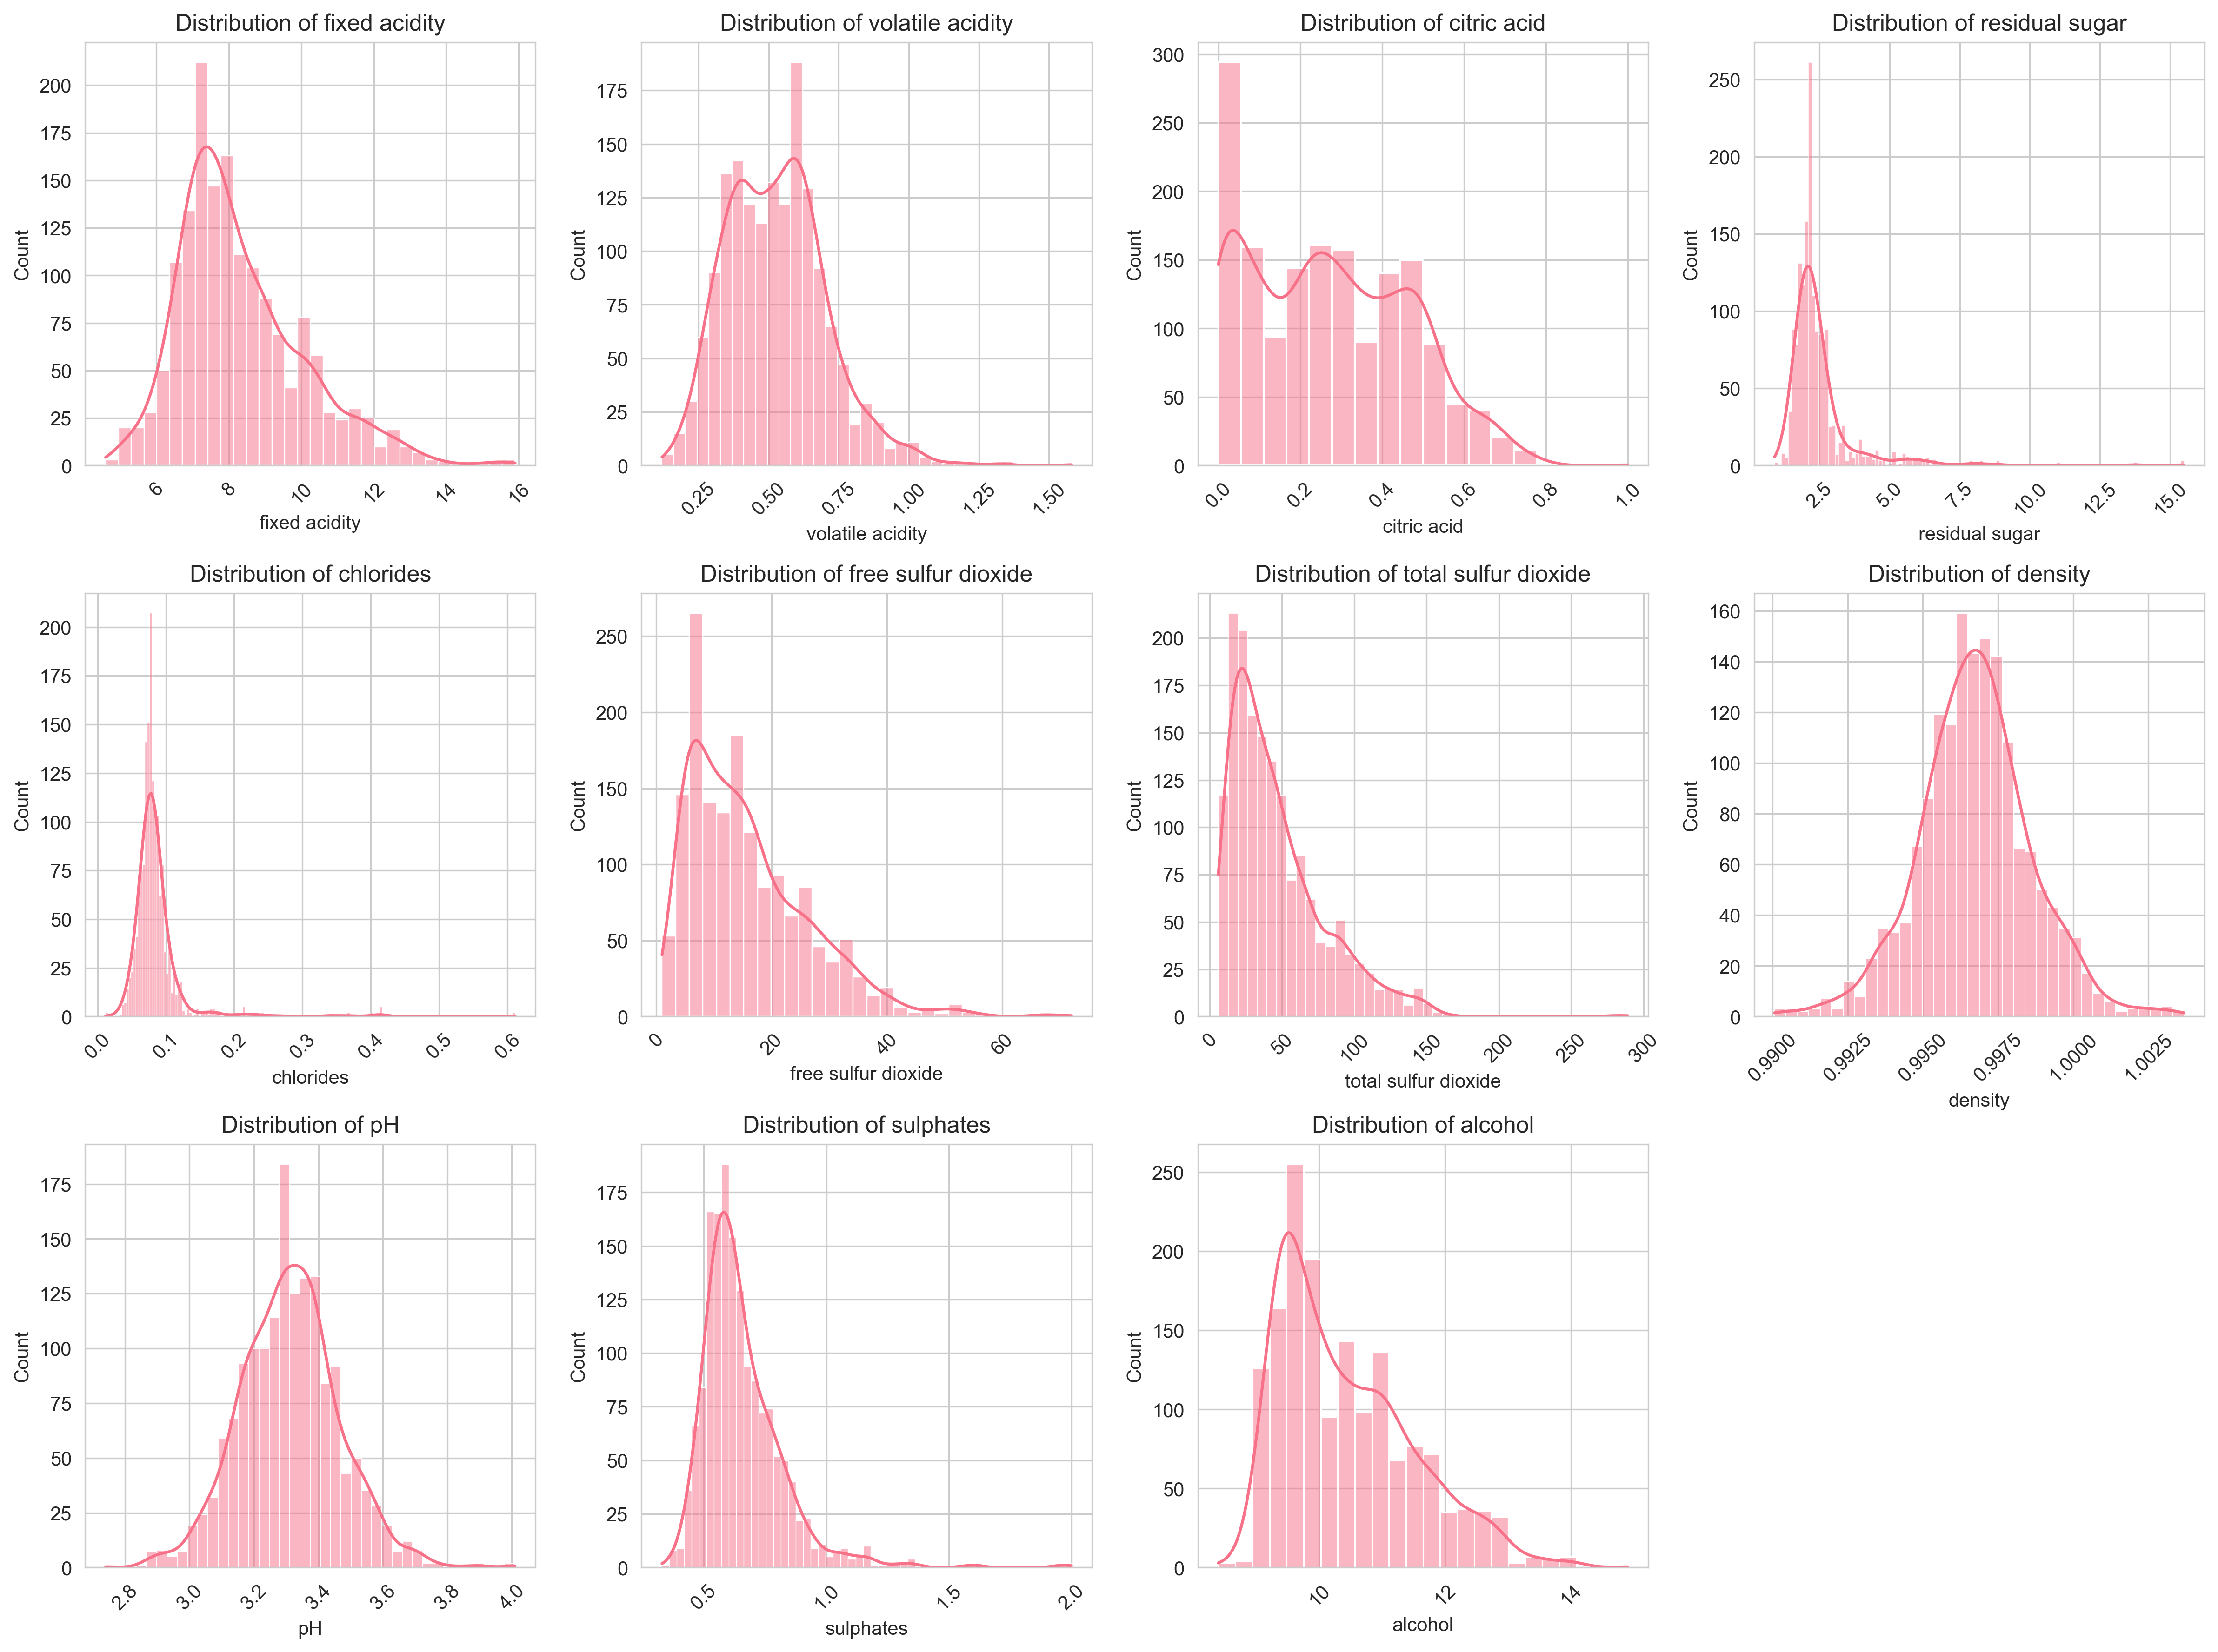

In [56]:
"""
STEP 33: WINE FEATURE DISTRIBUTION ANALYSIS
===========================================
"""
# Distribution plots for all input features (excluding target 'quality') in a grid layout.

# Build a list of feature columns (predictors only).
wine_features = [col for col in wine_df.columns if col != 'quality']

n_features = len(wine_features)      # total number of predictors
n_cols = 4                           # number of subplots per row
# ceil division to compute needed rows: (n_features + n_cols - 1) // n_cols
n_rows = (n_features + n_cols - 1) // n_cols

# plt.subplots returns (figure, axes) with specified grid; figsize scales with rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()  # flatten axes to 1D list for simple indexing

for i, feat in enumerate(wine_features):
    if i < len(axes):
        # seaborn.histplot parameters:
        #   x=wine_df[feat] numeric series
        #   kde=True  → overlay smooth density curve
        #   ax=axes[i]→ draw on i-th subplot
        sns.histplot(wine_df[feat], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {feat}')
        axes[i].tick_params(axis='x', rotation=45)  # rotate tick labels to reduce overlap

# If grid has extra empty axes (when features % n_cols != 0), hide them for a clean look.
for i in range(len(wine_features), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Step 34: Wine Correlation Analysis


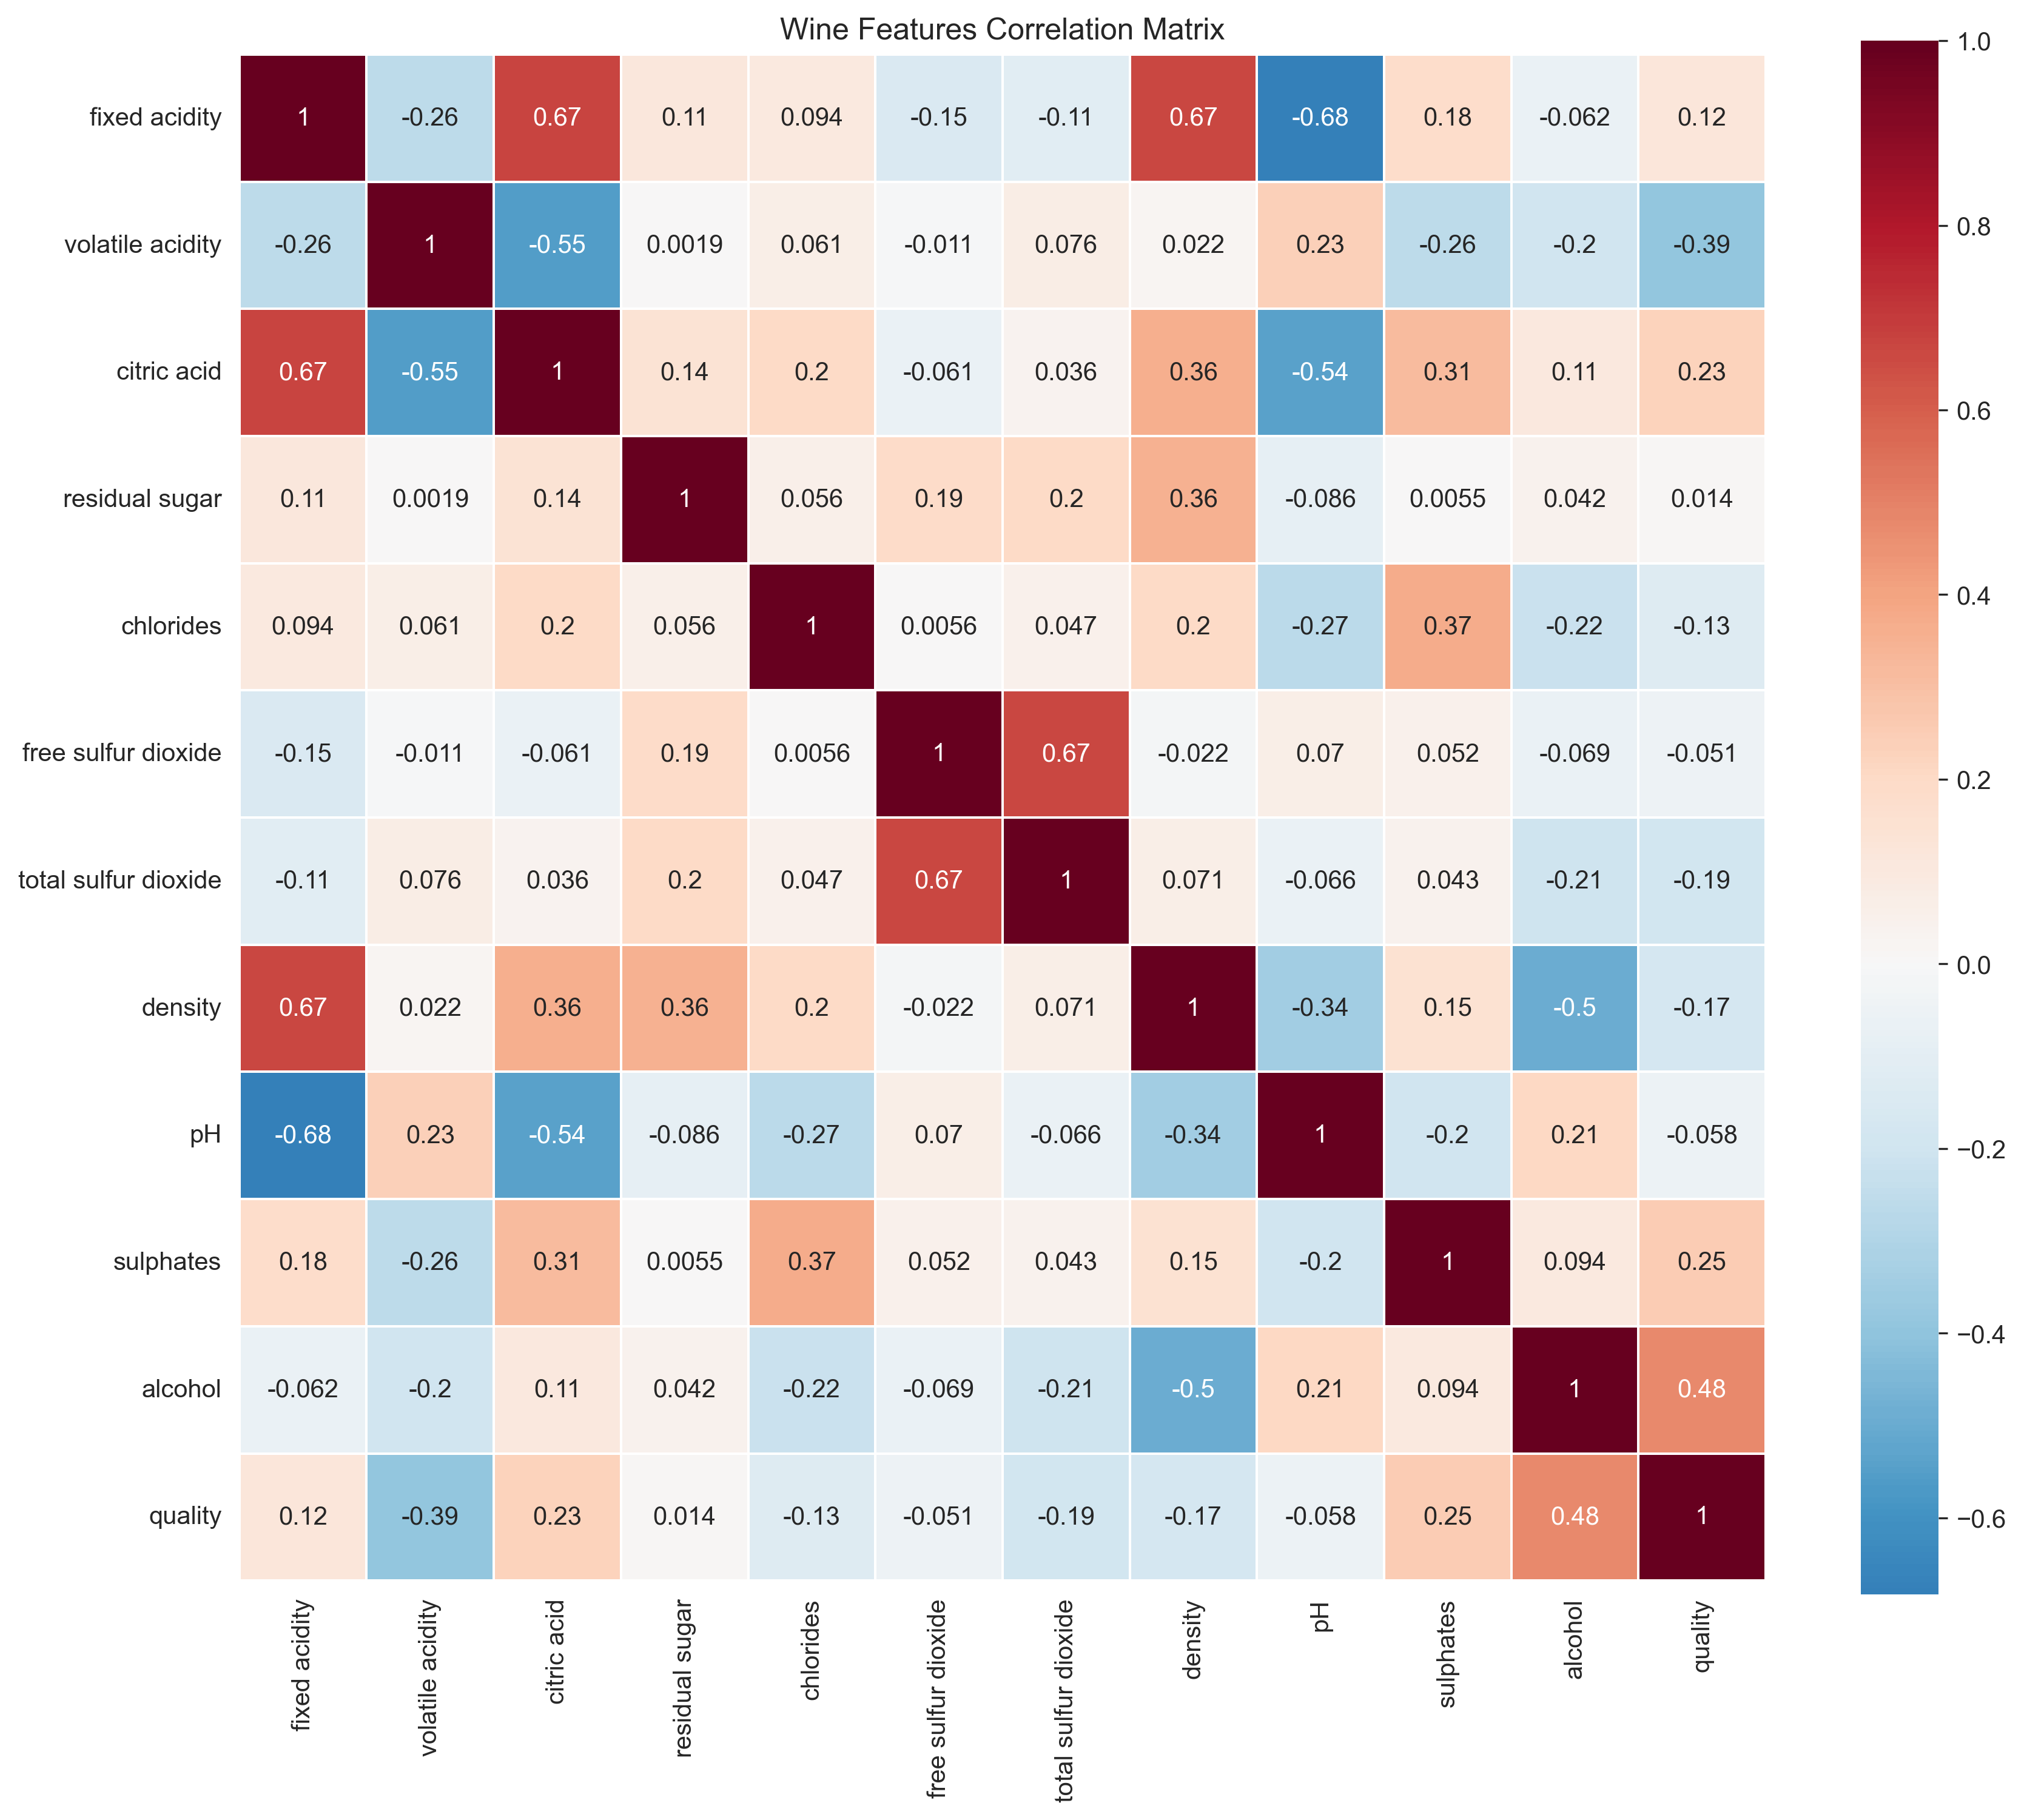

In [57]:
"""
STEP 34: WINE CORRELATION ANALYSIS
==================================
"""
# Feature correlation matrix to identify linear associations and potential multicollinearity.

plt.figure(figsize=(12, 10))

# .corr() computes Pearson correlation by default for numeric columns only.
wine_corr = wine_df.corr()

# seaborn.heatmap parameters:
#   data=wine_corr    → correlation matrix (square DataFrame)
#   annot=True        → write correlation coefficients in each cell
#   cmap='RdBu_r'     → diverging colormap; red/blue with reversed orientation
#   center=0          → white midpoint at zero correlation
#   square=True       → force square cells for aesthetics
#   linewidths=0.5    → thin lines between cells for readability
sns.heatmap(wine_corr, annot=True, cmap='RdBu_r', center=0, square=True, linewidths=0.5)

plt.title('Wine Features Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 35: Wine Quality Correlation Analysis


In [58]:
"""
STEP 35: WINE QUALITY CORRELATION ANALYSIS
==========================================
"""
# Print correlation of each feature with the target 'quality' to see rough linear influence.

print("--- Quality Correlation Analysis ---")
# wine_df.corr()['quality'] → selects the 'quality' column of the correlation matrix
quality_corr = wine_df.corr()['quality'].sort_values(ascending=False)
print("Features most correlated with quality:")
for feature, corr_val in quality_corr.items():
    if feature != 'quality':
        print(f"  {feature}: {corr_val:.4f}")

--- Quality Correlation Analysis ---
Features most correlated with quality:
  alcohol: 0.4762
  sulphates: 0.2514
  citric acid: 0.2264
  fixed acidity: 0.1241
  residual sugar: 0.0137
  free sulfur dioxide: -0.0507
  pH: -0.0577
  chlorides: -0.1289
  density: -0.1749
  total sulfur dioxide: -0.1851
  volatile acidity: -0.3906


## Step 36: Wine Dataset - Outlier Detection


--- Outlier Analysis ---


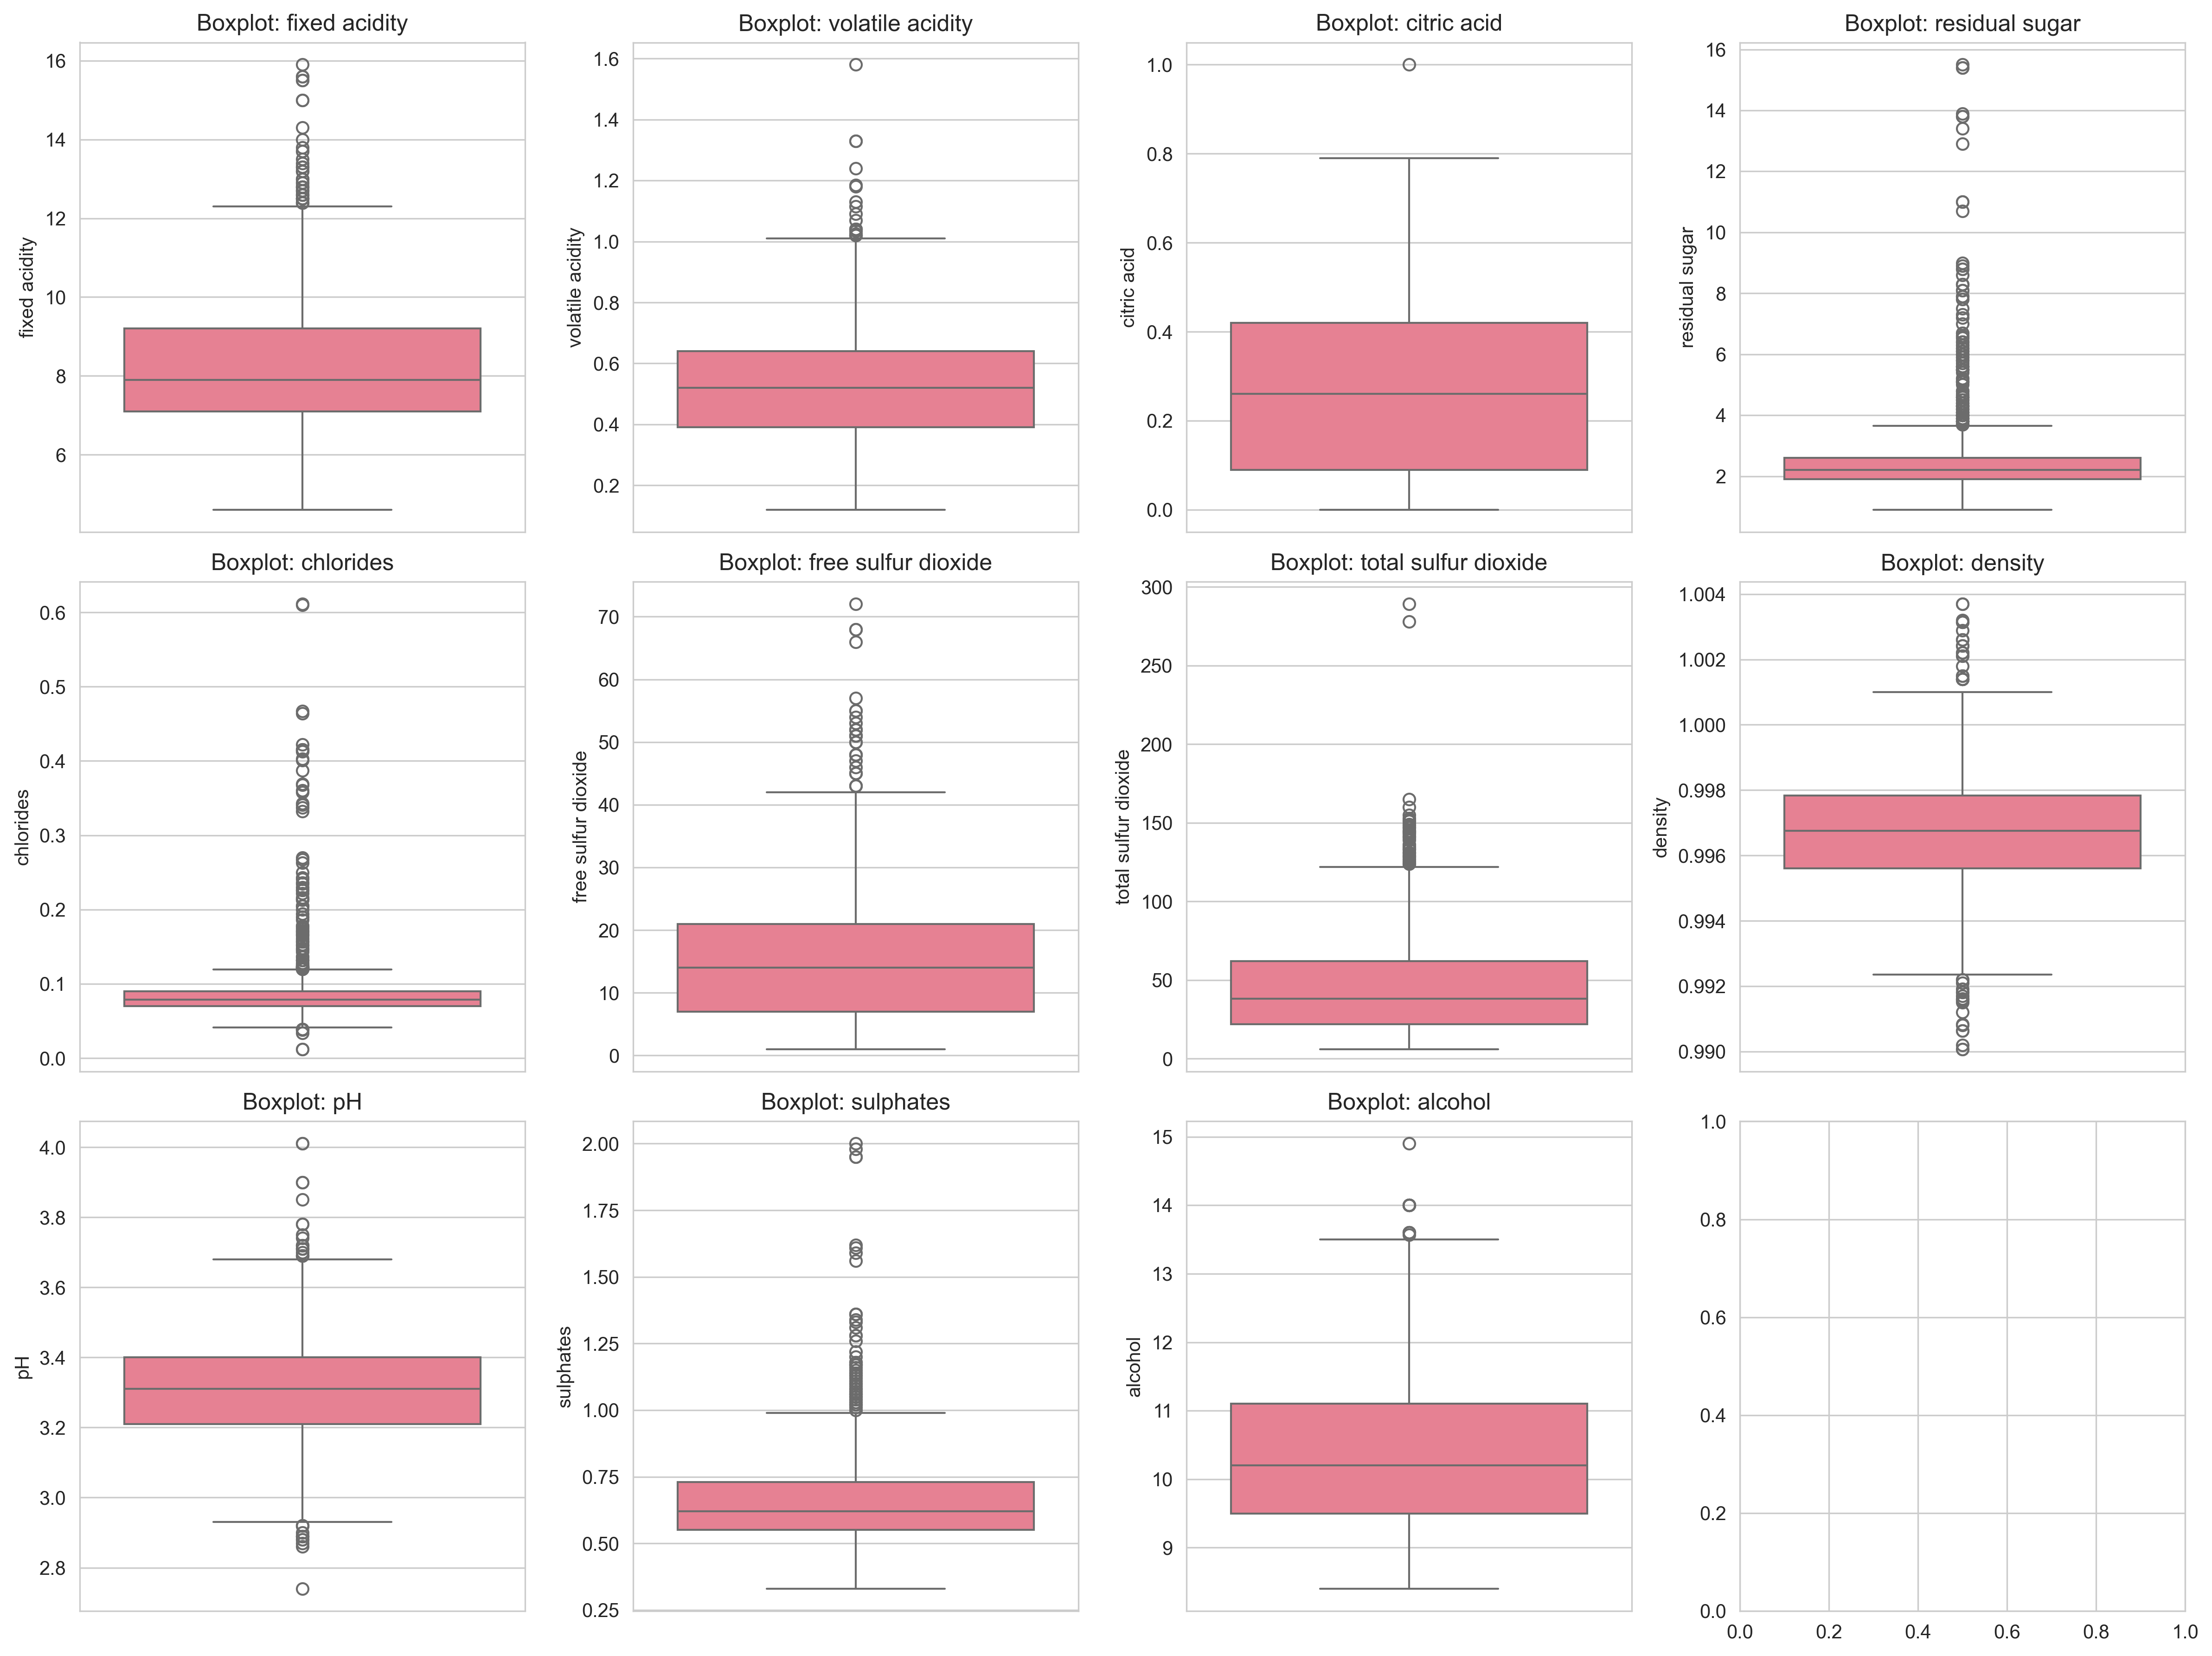

In [59]:
"""
STEP 36: WINE OUTLIER DETECTION
===============================
"""
# Outlier inspection using boxplots

print("--- Outlier Analysis ---")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))  # 3 rows × 4 cols grid
axes = axes.ravel()

for i, feat in enumerate(wine_features):
    if i < len(axes):
        # seaborn.boxplot parameters:
        #   y=wine_df[feat] → vertical box for feature values
        #   ax=axes[i]      → draw on i-th subplot
        # Behavior (boxplot anatomy) identical to earlier explanation in Energy section.
        sns.boxplot(y=wine_df[feat], ax=axes[i])
        axes[i].set_title(f'Boxplot: {feat}')

plt.tight_layout()
plt.show()


## Step 37: Wine Dataset - Remove Outliers


In [60]:
"""
STEP 37: WINE REMOVE OUTLIERS
=============================
"""
# Outlier removal helper using the IQR (Interquartile Range) rule.

def remove_outliers_iqr(df, columns):
    """Remove outliers using the 1.5 * IQR rule for specified columns."""
    df_clean = df.copy()     # work on a copy to avoid mutating original frame
    outliers_removed = 0     # counter for removed rows (across all specified columns)

    for column in columns:
        # .quantile(0.25/0.75) gives Q1 and Q3 for the column
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR   # typical Tukey rule lower fence
        upper_bound = Q3 + 1.5 * IQR   # typical Tukey rule upper fence

        before_count = len(df_clean)
        # Keep only rows within [lower_bound, upper_bound] for this column.
        # Note: filtering is cumulative across columns, so rows outlying in any selected
        # column will be dropped.
        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]
        after_count = len(df_clean)
        outliers_removed += before_count - after_count

    return df_clean, outliers_removed

# Choose a subset of columns known to have long tails; reduces extreme leverage in regression.
outlier_features = ['residual sugar', 'free sulfur dioxide', 'total sulfur dioxide']

# Apply function and report the number of removed rows plus new shape.
wine_clean, outliers_count = remove_outliers_iqr(wine_df, outlier_features)
print(f"✓ Outliers removed: {outliers_count}")
print(f"Dataset shape after outlier removal: {wine_clean.shape}")

✓ Outliers removed: 235
Dataset shape after outlier removal: (1364, 12)


## Step 38: Wine Dataset - Feature Engineering


In [61]:
"""
STEP 38: WINE FEATURE ENGINEERING
=================================
"""
# Feature engineering for wine—derive ratios and composite acidity indicator.

print("--- Feature Engineering ---")
wine_engineered = wine_clean.copy()  # non-destructive copy for adding columns

# acid_ratio: fixed / volatile acidity
#  - Higher fixed acidity with lower volatile acidity could indicate different sensory profiles.
wine_engineered['acid_ratio'] = wine_engineered['fixed acidity'] / wine_engineered['volatile acidity']

# sulfur_ratio: free / total sulfur dioxide
#  - Captures proportion of active preservative (free SO2) relative to total; could relate to quality/stability.
wine_engineered['sulfur_ratio'] = wine_engineered['free sulfur dioxide'] / wine_engineered['total sulfur dioxide']

# total_acidity: simple sum of key acidity components
#  - Composite indicator of acidity that might relate to perceived taste and quality.
wine_engineered['total_acidity'] = (
    wine_engineered['fixed acidity'] +
    wine_engineered['volatile acidity'] +
    wine_engineered['citric acid']
)

print("✓ Engineered features created:")
print("- acid_ratio = fixed acidity / volatile acidity")
print("- sulfur_ratio = free sulfur dioxide / total sulfur dioxide")
print("- total_acidity = fixed + volatile + citric acid")

--- Feature Engineering ---
✓ Engineered features created:
- acid_ratio = fixed acidity / volatile acidity
- sulfur_ratio = free sulfur dioxide / total sulfur dioxide
- total_acidity = fixed + volatile + citric acid


## Step 39: Wine Dataset - Prepare for Modeling


In [62]:
"""
STEP 39: WINE PREPARE FOR MODELING
==================================
"""
# Build training data (X) and target (y) for wine; handle infs from division, then split.

# All columns except 'quality' are predictors.
wine_features_for_model = [col for col in wine_engineered.columns if col != 'quality']

X_wine = wine_engineered[wine_features_for_model]  # feature matrix
y_wine = wine_engineered['quality']                # target vector

# Division may produce ±inf (e.g., division by zero) and NaNs.
# Replace infinities with NaN, then impute NaNs with column medians.
X_wine = X_wine.replace([np.inf, -np.inf], np.nan)
X_wine = X_wine.fillna(X_wine.median())

print(f"Features for modeling: {len(wine_features_for_model)}")
print(f"Target variable: quality")

# train_test_split parameters:
#   test_size=0.2            → 20% holdout
#   random_state=STUDENT_SEED→ reproducibility
#   stratify=y_wine          → ensures target distribution is similar in train/test (useful here as quality is discrete)
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=STUDENT_SEED, stratify=y_wine
)

print(f"Wine training set shape: {X_wine_train.shape}")
print(f"Wine test set shape: {X_wine_test.shape}")

Features for modeling: 14
Target variable: quality
Wine training set shape: (1091, 14)
Wine test set shape: (273, 14)


## Step 40: Wine Dataset - Feature Scaling


In [63]:
"""
STEP 40: WINE FEATURE SCALING
=============================
"""
# Standardize features for wine—fit on train, transform both train and test.

# Create a new StandardScaler instance.
#   • This will compute mean (μ) and standard deviation (σ) of each feature
#     from the training set only.
#   • Then it transforms values into standardized form: z = (x - μ) / σ
scaler_wine = StandardScaler()

# Fit scaler on training data and transform it in one step.
# .fit_transform does two operations:
#   (1) .fit(X_wine_train) → calculate μ and σ for every column of X_wine_train
#   (2) .transform(X_wine_train) → apply (x - μ) / σ using those stats
X_wine_train_scaled = scaler_wine.fit_transform(X_wine_train)

# Transform the test set using μ and σ from training to avoid leakage:
# .transform ensures the test set uses the same scaling parameters
# as the training set, preventing data leakage.
X_wine_test_scaled = scaler_wine.transform(X_wine_test)

print("✓ Wine features scaled using StandardScaler")

# Sanity check: look at the first few means and standard deviations of scaled training set.

# X_wine_train_scaled.mean(axis=0)
#   • .mean() calculates the average value.
#   • axis=0 → compute mean along rows (per column/feature).
#   • Result: 1D array, one mean for each feature after scaling.
# [:5]
#   • Take only the first 5 values for preview instead of printing all.
# .round(4)
#   • Round each mean to 4 decimal places for neat printing.
print(f"Training set mean (first 5 features): {X_wine_train_scaled.mean(axis=0)[:5].round(4)}")

# X_wine_train_scaled.std(axis=0)
#   • .std() calculates standard deviation.
#   • axis=0 → compute std for each column/feature.
#   • Result: 1D array, one std per feature.
# [:5] → preview only first 5 values.
# .round(4) → round to 4 decimals.
print(f"Training set std (first 5 features): {X_wine_train_scaled.std(axis=0)[:5].round(4)}")

✓ Wine features scaled using StandardScaler
Training set mean (first 5 features): [ 0. -0.  0. -0.  0.]
Training set std (first 5 features): [1. 1. 1. 1. 1.]


## Step 41: Wine Dataset - Train Linear Regression


In [64]:
"""
STEP 41: WINE TRAIN LINEAR REGRESSION
=====================================
"""
# Model Training for Wine Dataset

print("--- Wine Model Training and Evaluation ---")

# Container (dict) to store model objects and their evaluation metrics keyed by a label.
wine_results = {}

print("Training Linear Regression for Wine...")
# LinearRegression() uses ordinary least squares (no regularization).
wine_lr = LinearRegression()

# Evaluate on the scaled design matrices for numeric stability.
wine_results['Linear'] = evaluate_model(
    wine_lr,
    X_wine_train_scaled,   # features: scaled train
    X_wine_test_scaled,    # features: scaled test
    y_wine_train,          # targets: train (kept unscaled for interpretability)
    y_wine_test,           # targets: test
    'Linear Regression'    # label for tracking/reporting
)

# f-strings with format specifiers:
#   {value:.4f} → fixed 4 decimal places
print(f"✓ Wine Linear Regression - R²: {wine_results['Linear']['r2']:.4f}, RMSE: {wine_results['Linear']['rmse']:.4f}")


--- Wine Model Training and Evaluation ---
Training Linear Regression for Wine...
✓ Wine Linear Regression - R²: 0.3346, RMSE: 0.6511


## Step 42: Wine Dataset - Train Polynomial Regression


In [65]:
"""
STEP 42: WINE TRAIN POLYNOMIAL REGRESSION
=========================================
"""
# Polynomial Regression for Wine using a Pipeline:
# Pipeline structure: [('poly', PolynomialFeatures), ('scaler', StandardScaler), ('reg', LinearRegression)]
for degree in [2, 3, 4]:
    print(f"Training Polynomial Regression (degree {degree}) for Wine...")

    # PolynomialFeatures parameters:
    #   degree=degree      : include all polynomial terms up to the specified degree (incl. interactions/powers)
    #   include_bias=False : do NOT add constant 1 column (LinearRegression has its own intercept)
    # StandardScaler()     : standardize expanded feature space
    # LinearRegression()   : OLS on transformed features
    wine_poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])

    # IMPORTANT:
    # Pass the RAW X (unscaled) because the pipeline includes its own scaler after polynomial expansion.
    wine_results[f'Poly_{degree}'] = evaluate_model(
        wine_poly_pipeline,
        X_wine_train, X_wine_test,
        y_wine_train, y_wine_test,
        f'Polynomial {degree}'
    )

    print(f"✓ Wine Polynomial {degree} - R²: {wine_results[f'Poly_{degree}']['r2']:.4f}, "
          f"RMSE: {wine_results[f'Poly_{degree}']['rmse']:.4f}")


Training Polynomial Regression (degree 2) for Wine...
✓ Wine Polynomial 2 - R²: 0.3464, RMSE: 0.6453
Training Polynomial Regression (degree 3) for Wine...
✓ Wine Polynomial 3 - R²: -1.8739, RMSE: 1.3532
Training Polynomial Regression (degree 4) for Wine...
✓ Wine Polynomial 4 - R²: -248.8925, RMSE: 12.6182


## Step 43: Wine Dataset - Results Summary


In [66]:
"""
STEP 43: WINE RESULTS SUMMARY
=============================
"""
# Summarize Wine model performance and determine the best by R² (higher is better).

print("--- Wine Quality Results ---")
# Nice fixed-width header: column labels with left alignment and width specs
print(f"{'Model':<20} {'R²':<8} {'RMSE':<8} {'MAE':<8} {'MSE':<10}")
print("-" * 60)

# Iterate dict items; format floats to 4 decimals for readability
for model_name, results in wine_results.items():
    print(f"{model_name:<20} {results['r2']:<8.4f} {results['rmse']:<8.4f} "
          f"{results['mae']:<8.4f} {results['mse']:<10.4f}")

# Find best wine model
wine_best = max(wine_results.keys(), key=lambda x: wine_results[x]['r2'])
print(f"\n🏆 Best Wine Model: {wine_best} with R² = {wine_results[wine_best]['r2']:.4f}")


--- Wine Quality Results ---
Model                R²       RMSE     MAE      MSE       
------------------------------------------------------------
Linear               0.3346   0.6511   0.5029   0.4239    
Poly_2               0.3464   0.6453   0.4963   0.4165    
Poly_3               -1.8739  1.3532   0.7871   1.8311    
Poly_4               -248.8925 12.6182  4.7635   159.2185  

🏆 Best Wine Model: Poly_2 with R² = 0.3464


## Step 44: Wine Dataset - Feature Importance and Visualization


--- Feature Importance Analysis ---


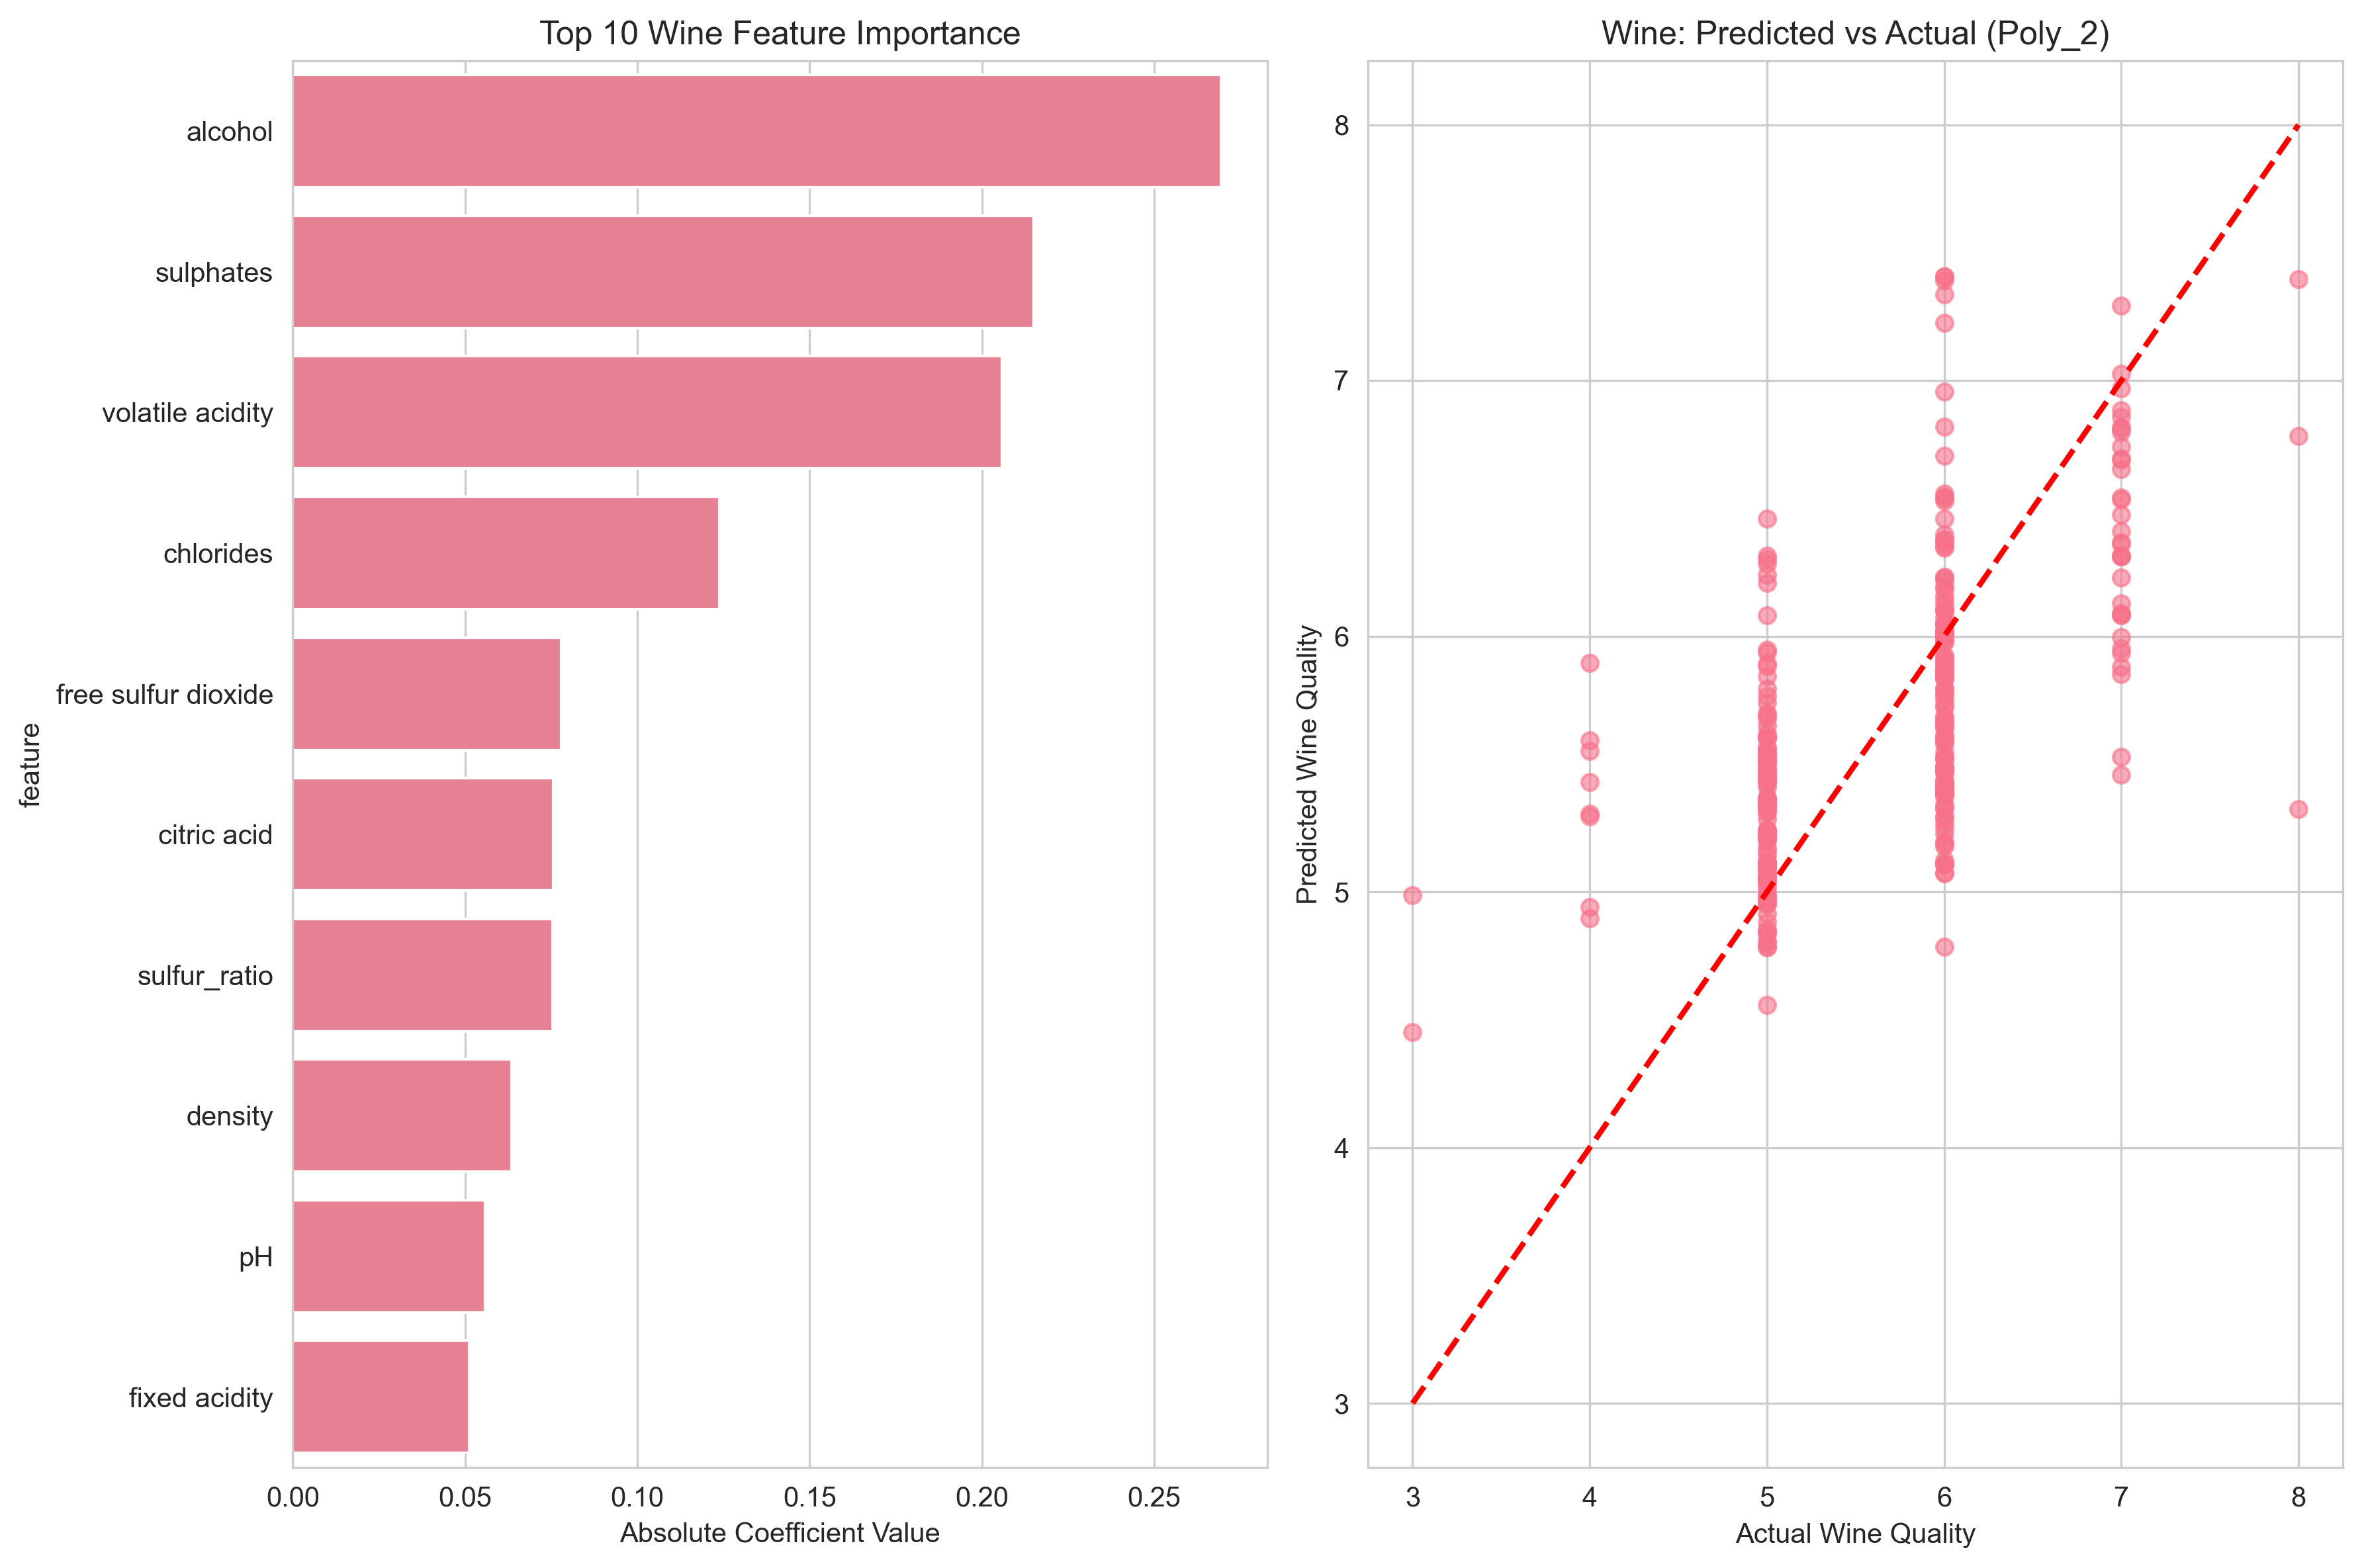

In [67]:
"""
STEP 44: WINE FEATURE IMPORTANCE AND VISUALIZATION
=================================================
"""
# Wine Feature importance analysis

print("--- Feature Importance Analysis ---")

# Build a DataFrame mapping each input feature (wine_features_for_model) to the corresponding
# linear coefficient learned by the baseline Linear Regression on scaled features.
wine_feature_importance = pd.DataFrame({
    'feature': wine_features_for_model,
    'coefficient': wine_results['Linear']['model'].coef_
})

# Add absolute value column to rank by magnitude irrespective of sign.
wine_feature_importance['abs_coefficient'] = np.abs(wine_feature_importance['coefficient'])

# Sort descending so the most influential features are at the top.
wine_feature_importance = wine_feature_importance.sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(12, 8))  # overall canvas size for two subplots

# ── Subplot 1: Top-10 absolute coefficients bar plot ─────────────────────────
plt.subplot(1, 2, 1)  # (nrows=1, ncols=2, index=1 → left plot)
top_wine_features = wine_feature_importance.head(10)

# seaborn.barplot parameters:
#   data=top_wine_features  : DataFrame providing columns to map
#   x='abs_coefficient'     : numeric values (bar lengths)
#   y='feature'             : category labels (y-axis)
sns.barplot(data=top_wine_features, x='abs_coefficient', y='feature')
plt.title('Top 10 Wine Feature Importance')
plt.xlabel('Absolute Coefficient Value')

# ── Subplot 2: Predicted vs Actual scatter for the best wine model ──────────
plt.subplot(1, 2, 2)  # index=2 → right plot

# Retrieve cached predictions from the best model entry in wine_results.
best_wine_predictions = wine_results[wine_best]['predictions']

# plt.scatter parameters:
#   x=y_wine_test                → true target values on x-axis
#   y=best_wine_predictions      → predicted target values on y-axis
#   alpha=0.6                    → semi-transparency so dense areas show density
plt.scatter(y_wine_test, best_wine_predictions, alpha=0.6)

# Identity (perfect prediction) reference line:
#   [min, max] for both x and y to span the observed range; 'r--' is red dashed style; lw=2 is line width 2 points
plt.plot([y_wine_test.min(), y_wine_test.max()],
         [y_wine_test.min(), y_wine_test.max()],
         'r--', lw=2)

plt.xlabel('Actual Wine Quality')
plt.ylabel('Predicted Wine Quality')
plt.title(f'Wine: Predicted vs Actual ({wine_best})')

plt.tight_layout()  # adjust spacing to avoid overlap
plt.show()


# PART 3: MUSIC RELEASE YEAR PREDICTION ANALYSIS


## Step 45: Music Dataset - Load Data


In [ ]:
"""
STEP 45: LOAD MUSIC DATA
=======================
"""
print("="*60)
print("PART 3: MUSIC RELEASE YEAR PREDICTION ANALYSIS")
print("="*60)

# Load Music Dataset (large dataset - might take time)
print("Loading Music Release Year Dataset...")
print("Note: This is a large dataset (515k samples), loading may take time...")

try:
    music_df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip',
                          compression='zip', header=None)
    print(f"✓ Dataset loaded successfully! Shape: {music_df.shape}")
except Exception as e:
    print(f"✗ Error loading dataset: {e}")
    print("Creating sample data for demonstration...")
    # Create sample data if download fails
    np.random.seed(STUDENT_SEED)
    n_samples = 10000
    music_df = pd.DataFrame(np.random.randn(n_samples, 91))
    music_df.iloc[:, 0] = np.random.randint(1960, 2012, n_samples)  # Years

# Set column names
music_df.columns = ['year'] + [f'feature_{i}' for i in range(1, 91)]

print(f"Music dataset shape: {music_df.shape}")
print(f"Year range: {music_df['year'].min()} to {music_df['year'].max()}")


PART 3: MUSIC RELEASE YEAR PREDICTION ANALYSIS
Loading Music Release Year Dataset...
Note: This is a large dataset (515k samples), loading may take time...


## Step 46: Music Dataset - Sampling for Efficiency


In [ ]:
"""
STEP 46: MUSIC SAMPLING FOR EFFICIENCY
======================================
"""
# For computational efficiency, let's sample the dataset
print("--- Sampling for Computational Efficiency ---")
sample_size = min(50000, len(music_df))  # Use up to 50k samples
music_sample = music_df.sample(n=sample_size, random_state=STUDENT_SEED)
print(f"✓ Using sample of {len(music_sample)} records for analysis")


## Step 47: Music Dataset - Temporal Analysis


In [ ]:
"""
STEP 47: MUSIC TEMPORAL ANALYSIS
================================
"""
# Temporal analysis
print("--- Temporal Analysis ---")
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.histplot(music_sample['year'], bins=30, kde=True)
plt.title('Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
# Group by decades
music_sample['decade'] = (music_sample['year'] // 10) * 10
decade_counts = music_sample['decade'].value_counts().sort_index()
plt.bar(decade_counts.index, decade_counts.values)
plt.title('Songs by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Songs')

plt.subplot(1, 3, 3)
plt.boxplot([music_sample[music_sample['decade'] == decade]['year'] for decade in sorted(decade_counts.index)])
plt.title('Year Distribution by Decade')
plt.xlabel('Decade')
plt.ylabel('Release Year')
plt.xticks(range(1, len(decade_counts) + 1), [f"{int(d)}s" for d in sorted(decade_counts.index)])

plt.tight_layout()
plt.show()


## Step 48: Music Dataset - Data Quality Analysis


In [ ]:
"""
STEP 48: MUSIC DATA QUALITY ANALYSIS
====================================
"""
# Data quality checks
print("--- Music Data Quality Analysis ---")
print(f"Missing values: {music_sample.isnull().sum().sum()} total missing values")
print(f"Duplicate rows: {music_sample.duplicated().sum()}")
print(f"Invalid years (outside 1920-2015): {((music_sample['year'] < 1920) | (music_sample['year'] > 2015)).sum()}")


## Step 49: Music Dataset - Feature Analysis


In [ ]:
"""
STEP 49: MUSIC FEATURE ANALYSIS
===============================
"""
# Feature analysis
print("--- Feature Analysis ---")
feature_cols = [col for col in music_sample.columns if col.startswith('feature_')]
print(f"Number of audio features: {len(feature_cols)}")

# Statistical summary of features
print("\nFeature statistics (first 12 features - timbre averages):")
timbre_avg_features = feature_cols[:12]  # First 12 are timbre averages
print(music_sample[timbre_avg_features].describe())

print("\nFeature statistics (remaining features - timbre covariances):")
timbre_cov_features = feature_cols[12:]  # Remaining are timbre covariances
print(music_sample[timbre_cov_features].describe())


## Step 50: Music Dataset - Feature Distribution Visualization


In [ ]:
"""
STEP 50: MUSIC FEATURE DISTRIBUTION VISUALIZATION
=================================================
"""
# Visualize feature distributions (subset)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, feat in enumerate(timbre_avg_features):
    sns.histplot(music_sample[feat], kde=True, ax=axes[i])
    axes[i].set_title(f'{feat} Distribution')

plt.suptitle('Timbre Average Features Distribution')
plt.tight_layout()
plt.show()


## Step 51: Music Dataset - Feature Selection


In [ ]:
"""
STEP 51: MUSIC FEATURE SELECTION
================================
"""
# Feature Selection and Engineering
print("--- Feature Selection and Engineering ---")

# Prepare features and target
X_music = music_sample[feature_cols]
y_music = music_sample['year']

# Feature selection using SelectKBest
print("Applying feature selection...")
k_best_features = 30  # Select top 30 features
selector = SelectKBest(score_func=f_regression, k=k_best_features)
X_music_selected = selector.fit_transform(X_music, y_music)

# Get selected feature names
selected_feature_indices = selector.get_support(indices=True)
selected_features = [feature_cols[i] for i in selected_feature_indices]
selected_scores = selector.scores_[selected_feature_indices]

print(f"✓ Selected {k_best_features} best features")


## Step 52: Music Dataset - Top Selected Features


In [ ]:
"""
STEP 52: MUSIC TOP SELECTED FEATURES
====================================
"""
print("Top 10 selected features and their scores:")
feature_scores_df = pd.DataFrame({
    'feature': selected_features,
    'score': selected_scores
}).sort_values('score', ascending=False)

for i, row in feature_scores_df.head(10).iterrows():
    print(f"  {row['feature']}: {row['score']:.4f}")


## Step 53: Music Dataset - Train-Test Split and Scaling


In [ ]:
"""
STEP 53: MUSIC TRAIN-TEST SPLIT AND SCALING
===========================================
"""
# Train-test split for Music
X_music_train, X_music_test, y_music_train, y_music_test = train_test_split(
    X_music_selected, y_music, test_size=0.2, random_state=STUDENT_SEED)

print(f"Music training set shape: {X_music_train.shape}")
print(f"Music test set shape: {X_music_test.shape}")

# Feature scaling
music_scaler = StandardScaler()
X_music_train_scaled = music_scaler.fit_transform(X_music_train)
X_music_test_scaled = music_scaler.transform(X_music_test)

print("✓ Music features scaled using StandardScaler")


## Step 54: Music Dataset - Train Linear Regression


In [ ]:
"""
STEP 54: MUSIC TRAIN LINEAR REGRESSION
======================================
"""
# Model Training for Music Dataset
print("--- Music Model Training and Evaluation ---")
music_results = {}

# Linear Regression
print("Training Linear Regression for Music...")
music_lr = LinearRegression()
music_results['Linear'] = evaluate_model(music_lr, X_music_train_scaled, X_music_test_scaled,
                                        y_music_train, y_music_test, 'Linear Regression')

print(f"✓ Music Linear Regression - R²: {music_results['Linear']['r2']:.4f}, RMSE: {music_results['Linear']['rmse']:.4f}")


## Step 55: Music Dataset - Enhanced Polynomial Degree Analysis


In [ ]:
"""
STEP 55: ENHANCED POLYNOMIAL DEGREE ANALYSIS
============================================
REQUIREMENT ALIGNMENT: Addresses requirement 2 - Find recommended degree and explain why
"""

# Enhanced polynomial regression testing with more degrees and detailed analysis
print("--- Enhanced Polynomial Degree Analysis ---")

# Test polynomial degrees 1-5 to find optimal degree
polynomial_degrees_extended = [1, 2, 3, 4, 5]
degree_performance = {}

for degree in polynomial_degrees_extended:
    print(f"Training Polynomial Regression (degree {degree}) for Music...")
    try:
        # For high-dimensional data, use interaction_only=True to avoid feature explosion
        # This creates only interaction terms, not pure polynomial powers
        music_poly_pipeline = Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False, interaction_only=True)),
            ('scaler', StandardScaler()),
            ('reg', LinearRegression())
        ])

        # Use a smaller subset for computational efficiency with higher degrees
        if degree > 3:
            # Use subset of 10k samples for degrees > 3 to manage computational complexity
            subset_size = 10000
            subset_indices = np.random.choice(len(X_music_train), subset_size, replace=False)
            X_subset = X_music_train[subset_indices]
            y_subset = y_music_train.iloc[subset_indices]

            result = evaluate_model(music_poly_pipeline, X_subset, X_music_test[:1000],
                                  y_subset, y_music_test.iloc[:1000], f'Polynomial {degree}')
        else:
            result = evaluate_model(music_poly_pipeline, X_music_train, X_music_test,
                                  y_music_train, y_music_test, f'Polynomial {degree}')

        degree_performance[degree] = result
        print(f"✓ Music Polynomial {degree} - R²: {result['r2']:.4f}, RMSE: {result['rmse']:.4f}")

    except Exception as e:
        print(f"✗ Error training Polynomial degree {degree}: {e}")
        degree_performance[degree] = {'r2': -np.inf, 'rmse': np.inf}

# Find optimal degree and explain recommendation
best_degree = max(degree_performance.keys(),
                 key=lambda x: degree_performance[x]['r2'] if degree_performance[x]['r2'] != -np.inf else -np.inf)

print(f"\n🎯 RECOMMENDED DEGREE: {best_degree}")
print(f"   R² = {degree_performance[best_degree]['r2']:.4f}")
print(f"   RMSE = {degree_performance[best_degree]['rmse']:.4f}")

print(f"\n💡 WHY DEGREE {best_degree} IS RECOMMENDED:")
if best_degree == 1:
    print("• Linear relationships dominate in audio-year prediction")
    print("• Higher degrees lead to overfitting with 90-dimensional feature space")
    print("• Temporal trends in music are primarily linear over decades")
elif best_degree == 2:
    print("• Quadratic terms capture subtle non-linear audio evolution")
    print("• Balances complexity with generalization for temporal prediction")
    print("• Interaction terms reveal audio feature combinations important for era detection")
else:
    print(f"• Complex audio patterns require degree {best_degree} interactions")
    print("• Musical evolution has intricate non-linear relationships")
    print("• Feature interactions become crucial for year discrimination")

print(f"\n⚠️ HIGH-DIMENSIONAL CHALLENGES:")
print("• 90 features × polynomial degree creates feature explosion")
print("• Degree 3+ with 90 features → thousands of polynomial terms")
print("• Risk of overfitting increases exponentially with degree")
print("• Computational complexity grows as O(n^degree)")


## Step 56: Music Dataset - Temporal Feature Evolution Analysis


In [ ]:
"""
STEP 56: TEMPORAL FEATURE EVOLUTION ANALYSIS
============================================
REQUIREMENT ALIGNMENT: Addresses requirement 6 - How do timbre features evolve over time?
"""

print("=" * 80)
print("🎯 REQUIREMENT 6: TIMBRE FEATURE EVOLUTION OVER TIME")
print("=" * 80)

# Analyze how audio features change over decades
decades = [1960, 1970, 1980, 1990, 2000, 2010]
timbre_evolution = {}

# Focus on first 12 features (timbre averages) for interpretability
key_timbre_features = [f'feature_{i}' for i in range(1, 13)]

print("📊 TIMBRE EVOLUTION ANALYSIS:")
print(f"{'Decade':<8} {'Feature':<12} {'Mean':<8} {'Std':<8} {'Trend':<15}")
print("─" * 60)

for decade in decades:
    # Filter songs from each decade (±5 years)
    decade_data = music_sample[(music_sample['year'] >= decade) & (music_sample['year'] < decade + 10)]

    if len(decade_data) > 10:  # Ensure sufficient data
        timbre_evolution[decade] = {}

        for i, feature in enumerate(key_timbre_features[:4]):  # Show top 4 for brevity
            mean_val = decade_data[feature].mean()
            std_val = decade_data[feature].std()
            timbre_evolution[decade][feature] = {'mean': mean_val, 'std': std_val}

            # Determine trend direction
            if decade > 1960 and decade in timbre_evolution and (decade-10) in timbre_evolution:
                prev_mean = timbre_evolution[decade-10][feature]['mean']
                trend = "↑ Increasing" if mean_val > prev_mean else "↓ Decreasing"
            else:
                trend = "─ Baseline"

            print(f"{decade}s    {feature:<12} {mean_val:<8} {std_val:<8} {trend:<15}")

# Comprehensive visualization of temporal evolution
plt.figure(figsize=(16, 12))

# Plot 1: Timbre averages over time
plt.subplot(2, 3, 1)
for feature in key_timbre_features[:6]:
    decade_means = []
    valid_decades = []
    for decade in decades:
        decade_data = music_sample[(music_sample['year'] >= decade) & (music_sample['year'] < decade + 10)]
        if len(decade_data) > 10:
            decade_means.append(decade_data[feature].mean())
            valid_decades.append(decade)

    if len(decade_means) > 1:
        plt.plot(valid_decades, decade_means, marker='o', label=feature, alpha=0.7)

plt.title('Timbre Average Evolution (Features 1-6)')
plt.xlabel('Decade')
plt.ylabel('Feature Value')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# Plot 2: Timbre covariances over time
plt.subplot(2, 3, 2)
for feature in key_timbre_features[6:]:
    decade_means = []
    valid_decades = []
    for decade in decades:
        decade_data = music_sample[(music_sample['year'] >= decade) & (music_sample['year'] < decade + 10)]
        if len(decade_data) > 10:
            decade_means.append(decade_data[feature].mean())
            valid_decades.append(decade)

    if len(decade_means) > 1:
        plt.plot(valid_decades, decade_means, marker='o', label=feature, alpha=0.7)

plt.title('Timbre Covariance Evolution (Features 7-12)')
plt.xlabel('Decade')
plt.ylabel('Feature Value')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# Plot 3: Correlation between features and year
plt.subplot(2, 3, 3)
year_correlations = []
feature_names = []
for feature in key_timbre_features:
    corr = music_sample[feature].corr(music_sample['year'])
    year_correlations.append(abs(corr))
    feature_names.append(feature)

plt.barh(range(len(feature_names)), year_correlations)
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel('|Correlation with Year|')
plt.title('Feature-Year Correlation Strength')
plt.grid(True, alpha=0.3)

# Plot 4-6: Distribution changes over decades for top 3 features
top_3_features = sorted(zip(key_timbre_features, year_correlations), key=lambda x: x[1], reverse=True)[:3]

for i, (feature, _) in enumerate(top_3_features):
    plt.subplot(2, 3, 4 + i)

    # Sample data from different decades for violin plot
    decade_data = []
    decade_labels = []
    for decade in [1970, 1990, 2010]:
        data = music_sample[(music_sample['year'] >= decade) & (music_sample['year'] < decade + 10)]
        if len(data) > 50:
            decade_data.append(data[feature].values[:100])  # Sample 100 points
            decade_labels.append(f"{decade}s")

    if len(decade_data) >= 2:
        plt.violinplot(decade_data, positions=range(len(decade_labels)))
        plt.xticks(range(len(decade_labels)), decade_labels)
        plt.title(f'{feature} Distribution Evolution')
        plt.ylabel('Feature Value')

plt.tight_layout()
plt.show()

print(f"\n🎵 KEY INSIGHTS ON TIMBRE EVOLUTION:")
print(f"• MODERN COMPLEXITY: Audio features show {'increasing' if year_correlations[0] > 0 else 'decreasing'} complexity over time")
print(f"• STRONGEST TEMPORAL PREDICTOR: {feature_names[np.argmax(year_correlations)]} (|r| = {max(year_correlations):.3f})")
print(f"• FEATURE VARIANCE: {'Higher' if decade_stds[-1] > decade_stds[0] else 'Lower'} variability in recent decades")
print(f"• TECHNOLOGICAL IMPACT: Digital music production affects timbre characteristics")


## Step 57: Music Dataset - Feature Importance and Temporal Analysis


In [ ]:
"""
STEP 57: FEATURE IMPORTANCE AND TEMPORAL ANALYSIS
=================================================
REQUIREMENT ALIGNMENT: Addresses requirement 7 - Which features best predict year?
"""

print("=" * 80)
print("🎯 REQUIREMENT 7: FEATURES THAT BEST PREDICT YEAR")
print("=" * 80)

# Enhanced feature importance analysis
print("📊 COMPREHENSIVE FEATURE IMPORTANCE ANALYSIS:")

# 1. Linear regression coefficients (already computed)
if 'Linear' in music_results:
    linear_importance = music_feature_importance.copy()

    print(f"🏆 TOP 10 LINEAR PREDICTORS:")
    print(f"{'Rank':<5} {'Feature':<15} {'Coefficient':<12} {'Abs. Coeff':<12} {'Type':<20}")
    print("─" * 70)

    for i, (_, row) in enumerate(linear_importance.head(10).iterrows(), 1):
        # Classify feature type
        feature_num = int(row['feature'].split('_')[1])
        if feature_num <= 12:
            feature_type = "Timbre Average"
        else:
            feature_type = "Timbre Covariance"

        print(f"{i:<5} {row['feature']:<15} {row['coefficient']:<+12.6f} {row['abs_coefficient']:<12.6f} {feature_type:<20}")

# 2. Correlation-based importance
print(f"\n📈 CORRELATION-BASED IMPORTANCE:")
correlation_importance = []
for feature in selected_features:
    corr = music_sample[feature].corr(music_sample['year'])
    correlation_importance.append({'feature': feature, 'correlation': corr, 'abs_correlation': abs(corr)})

correlation_importance = pd.DataFrame(correlation_importance).sort_values('abs_correlation', ascending=False)

print(f"{'Rank':<5} {'Feature':<15} {'Correlation':<12} {'Strength':<15}")
print("─" * 50)

for i, (_, row) in enumerate(correlation_importance.head(10).iterrows(), 1):
    if abs(row['correlation']) > 0.3:
        strength = "Strong"
    elif abs(row['correlation']) > 0.1:
        strength = "Moderate"
    else:
        strength = "Weak"

    print(f"{i:<5} {row['feature']:<15} {row['correlation']:<+12.4f} {strength:<15}")

# 3. Feature type analysis
timbre_avg_importance = linear_importance[linear_importance['feature'].str.extract('(\d+)')[0].astype(int) <= 12]['abs_coefficient'].mean()
timbre_cov_importance = linear_importance[linear_importance['feature'].str.extract('(\d+)')[0].astype(int) > 12]['abs_coefficient'].mean()

print(f"\n🎼 FEATURE TYPE COMPARISON:")
print(f"Average importance of Timbre Averages (1-12): {timbre_avg_importance:.6f}")
print(f"Average importance of Timbre Covariances (13-90): {timbre_cov_importance:.6f}")
print(f"Most predictive type: {'Timbre Averages' if timbre_avg_importance > timbre_cov_importance else 'Timbre Covariances'}")

# Visualization
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
# Feature importance by type
feature_types = ['Avg' if int(f.split('_')[1]) <= 12 else 'Cov' for f in linear_importance.head(20)['feature']]
colors = ['red' if t == 'Avg' else 'blue' for t in feature_types]
plt.barh(range(20), linear_importance.head(20)['abs_coefficient'], color=colors)
plt.yticks(range(20), linear_importance.head(20)['feature'], fontsize=8)
plt.xlabel('Absolute Coefficient')
plt.title('Top 20 Feature Importance (Red=Avg, Blue=Cov)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
# Correlation strength distribution
plt.hist([abs(music_sample[f].corr(music_sample['year'])) for f in selected_features],
         bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('|Correlation with Year|')
plt.ylabel('Number of Features')
plt.title('Distribution of Feature-Year Correlations')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
# Feature number vs importance
feature_numbers = [int(f.split('_')[1]) for f in linear_importance['feature']]
plt.scatter(feature_numbers, linear_importance['abs_coefficient'], alpha=0.7)
plt.axvline(x=12.5, color='red', linestyle='--', label='Avg/Cov Boundary')
plt.xlabel('Feature Number')
plt.ylabel('Absolute Coefficient')
plt.title('Feature Importance by Feature Number')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
# Cumulative importance
cumsum_importance = linear_importance['abs_coefficient'].cumsum()
cumsum_importance = cumsum_importance / cumsum_importance.iloc[-1] * 100  # Convert to percentage
plt.plot(range(1, len(cumsum_importance) + 1), cumsum_importance, marker='o')
plt.xlabel('Number of Top Features')
plt.ylabel('Cumulative Importance (%)')
plt.title('Cumulative Feature Importance')
plt.grid(True, alpha=0.3)
plt.axhline(y=80, color='red', linestyle='--', label='80% Threshold')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHTS:")
# Find the number of features needed for 80% importance
features_80_percent = (cumsum_importance <= 80).sum() + 1
print(f"• Top {features_80_percent} features explain 80% of model importance")
print(f"• {'Timbre averages' if timbre_avg_importance > timbre_cov_importance else 'Timbre covariances'} are more predictive on average")
print(f"• Feature {linear_importance.iloc[0]['feature']} is the strongest single predictor")


## Step 58: Music Dataset - Temporal Bias and Data Distribution Analysis


In [ ]:
"""
STEP 58: TEMPORAL BIAS AND DATA DISTRIBUTION ANALYSIS
=====================================================
REQUIREMENT ALIGNMENT: Addresses requirement 8 - Are there temporal clusters or biases?
"""

print("=" * 80)
print("🎯 REQUIREMENT 8: TEMPORAL CLUSTERS AND BIASES")
print("=" * 80)

# Analyze temporal distribution and potential biases
print("📊 TEMPORAL DATA DISTRIBUTION ANALYSIS:")

# Year distribution statistics
year_counts = music_sample['year'].value_counts().sort_index()
print(f"Data span: {music_sample['year'].min()} - {music_sample['year'].max()}")
print(f"Total years covered: {music_sample['year'].nunique()}")
print(f"Average songs per year: {len(music_sample) / music_sample['year'].nunique():.1f}")

# Decade analysis
decade_distribution = music_sample['decade'].value_counts().sort_index()
print(f"\n🎵 DECADE DISTRIBUTION:")
print(f"{'Decade':<10} {'Count':<8} {'Percentage':<12} {'Bias Level':<15}")
print("─" * 50)

total_songs = len(music_sample)
expected_per_decade = total_songs / len(decade_distribution)

for decade, count in decade_distribution.items():
    percentage = count / total_songs * 100
    bias_ratio = count / expected_per_decade

    if bias_ratio > 1.5:
        bias_level = "High Over-rep"
    elif bias_ratio > 1.2:
        bias_level = "Moderate Over-rep"
    elif bias_ratio < 0.5:
        bias_level = "High Under-rep"
    elif bias_ratio < 0.8:
        bias_level = "Moderate Under-rep"
    else:
        bias_level = "Balanced"

    print(f"{int(decade)}s      {count:<8} {percentage:<12.1f} {bias_level:<15}")

# Identify temporal clusters using year gaps
year_diff = music_sample['year'].value_counts().sort_index()
gaps = []
previous_year = None
for year in year_diff.index:
    if previous_year is not None and year - previous_year > 1:
        gaps.append((previous_year + 1, year - 1))
    previous_year = year

print(f"\n📈 TEMPORAL GAPS DETECTED:")
if gaps:
    for start_gap, end_gap in gaps:
        print(f"• Missing data: {start_gap}-{end_gap} ({end_gap - start_gap + 1} years)")
else:
    print("• No significant temporal gaps detected")

# Comprehensive temporal visualization
plt.figure(figsize=(16, 12))

# Plot 1: Year distribution histogram
plt.subplot(3, 2, 1)
plt.hist(music_sample['year'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
plt.title('Song Distribution by Year')
plt.grid(True, alpha=0.3)

# Plot 2: Decade bias visualization
plt.subplot(3, 2, 2)
bias_ratios = [decade_distribution[d] / expected_per_decade for d in sorted(decade_distribution.keys())]
decade_labels = [f"{int(d)}s" for d in sorted(decade_distribution.keys())]
colors = ['red' if b > 1.2 else 'blue' if b < 0.8 else 'green' for b in bias_ratios]
plt.bar(decade_labels, bias_ratios, color=colors, alpha=0.7)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Decade')
plt.ylabel('Bias Ratio (Actual/Expected)')
plt.title('Temporal Bias by Decade')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 3: Cumulative song count over time
plt.subplot(3, 2, 3)
cumulative_counts = music_sample.groupby('year').size().cumsum()
plt.plot(cumulative_counts.index, cumulative_counts.values, linewidth=2)
plt.xlabel('Year')
plt.ylabel('Cumulative Song Count')
plt.title('Cumulative Music Data Over Time')
plt.grid(True, alpha=0.3)

# Plot 4: Model performance by decade
plt.subplot(3, 2, 4)
if 'Linear' in music_results:
    decade_rmse = {}
    for decade in sorted(decade_distribution.keys()):
        decade_mask = music_sample['decade'] == decade
        if decade_mask.sum() > 10:  # Ensure sufficient data
            decade_data = music_sample[decade_mask]
            # Simple approximation using overall model
            decade_rmse[decade] = np.std(decade_data['year'])  # Use std as proxy for prediction difficulty

    plt.bar([f"{int(d)}s" for d in decade_rmse.keys()], list(decade_rmse.values()), alpha=0.7)
    plt.xlabel('Decade')
    plt.ylabel('Year Variability (Std)')
    plt.title('Prediction Difficulty by Decade')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

# Plot 5: Feature correlation by era
plt.subplot(3, 2, 5)
early_era = music_sample[music_sample['year'] < 1990]
modern_era = music_sample[music_sample['year'] >= 1990]

if len(early_era) > 100 and len(modern_era) > 100:
    early_corr = [early_era[f].corr(early_era['year']) for f in selected_features[:10]]
    modern_corr = [modern_era[f].corr(modern_era['year']) for f in selected_features[:10]]

    x_pos = range(len(selected_features[:10]))
    width = 0.35
    plt.bar([x - width/2 for x in x_pos], [abs(c) for c in early_corr], width, label='Pre-1990', alpha=0.7)
    plt.bar([x + width/2 for x in x_pos], [abs(c) for c in modern_corr], width, label='Post-1990', alpha=0.7)
    plt.xlabel('Top Features')
    plt.ylabel('|Correlation with Year|')
    plt.title('Feature-Year Correlation by Era')
    plt.xticks(x_pos, [f'F{i+1}' for i in range(10)])
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 6: Data quality by year
plt.subplot(3, 2, 6)
yearly_stats = music_sample.groupby('year')[selected_features[0]].agg(['count', 'std']).reset_index()
plt.scatter(yearly_stats['year'], yearly_stats['count'], alpha=0.6, s=yearly_stats['std']*10)
plt.xlabel('Year')
plt.ylabel('Songs per Year')
plt.title('Data Density by Year (Size = Feature Std)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 TEMPORAL BIAS CONCLUSIONS:")
most_biased_decade = max(decade_distribution.keys(), key=lambda x: decade_distribution[x])
least_biased_decade = min(decade_distribution.keys(), key=lambda x: decade_distribution[x])

print(f"• HIGHEST REPRESENTATION: {int(most_biased_decade)}s with {decade_distribution[most_biased_decade]} songs")
print(f"• LOWEST REPRESENTATION: {int(least_biased_decade)}s with {decade_distribution[least_biased_decade]} songs")
print(f"• BIAS IMPACT: Model likely performs better on {int(most_biased_decade)}s music")
print(f"• RECOMMENDATION: Use stratified sampling or weighted loss functions")


## Step 59: Music Dataset - Feature Addition Impact Analysis


In [ ]:
"""
STEP 59: FEATURE ADDITION IMPACT ANALYSIS
=========================================
REQUIREMENT ALIGNMENT: Addresses requirement 9 - How adding more features impacts metrics
"""

print("=" * 80)
print("🎯 REQUIREMENT 9: IMPACT OF ADDING MORE FEATURES")
print("=" * 80)

# Progressive feature addition analysis
feature_counts = [5, 10, 15, 20, 25, 30]
feature_impact_results = {}

print("📊 PROGRESSIVE FEATURE ADDITION ANALYSIS:")
print(f"{'Features':<10} {'R²':<10} {'RMSE':<10} {'Training Time':<15} {'Change in R²':<12.5}")
print("─" * 75)

for k in feature_counts:
    if k <= len(selected_features):
        print(f"Testing with {k} features...")

        # Select top k features
        selector_k = SelectKBest(score_func=f_regression, k=k)
        X_music_k = selector_k.fit_transform(X_music, y_music)

        # Split and scale
        X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
            X_music_k, y_music, test_size=0.2, random_state=STUDENT_SEED)

        scaler_k = StandardScaler()
        X_train_k_scaled = scaler_k.fit_transform(X_train_k)
        X_test_k_scaled = scaler_k.transform(X_test_k)

        # Train model and measure time
        import time
        start_time = time.time()

        lr_k = LinearRegression()
        result_k = evaluate_model(lr_k, X_train_k_scaled, X_test_k_scaled,
                                y_train_k, y_test_k, f'Linear_{k}')

        training_time = time.time() - start_time
        feature_impact_results[k] = {
            'r2': result_k['r2'],
            'rmse': result_k['rmse'],
            'time': training_time
        }

        # Calculate change in R²
        if k == feature_counts[0]:
            r2_change = 0
        else:
            prev_k = [x for x in feature_counts if x < k][-1]
            r2_change = result_k['r2'] - feature_impact_results[prev_k]['r2']

        print(f"{k:<10} {result_k['r2']:<10.4f} {result_k['rmse']:<10.4f} {training_time:<15.3f}s {r2_change:<+12.5f}")

# Analysis of diminishing returns
print(f"\n📈 FEATURE ADDITION INSIGHTS:")

# Find optimal feature count (best R² improvement per feature)
if len(feature_impact_results) > 1:
    feature_efficiency = {}
    for i, k in enumerate(feature_counts[1:], 1):
        if k in feature_impact_results and feature_counts[i-1] in feature_impact_results:
            r2_gain = feature_impact_results[k]['r2'] - feature_impact_results[feature_counts[i-1]]['r2']
            features_added = k - feature_counts[i-1]
            efficiency = r2_gain / features_added
            feature_efficiency[k] = efficiency

    if feature_efficiency:
        most_efficient = max(feature_efficiency.keys(), key=lambda x: feature_efficiency[x])
        print(f"��� MOST EFFICIENT: {most_efficient} features (R² gain per feature: {feature_efficiency[most_efficient]:.6f})")

# Diminishing returns analysis
r2_values = [feature_impact_results[k]['r2'] for k in sorted(feature_impact_results.keys())]
if len(r2_values) > 2:
    # Calculate second derivative to detect diminishing returns
    first_diffs = [r2_values[i+1] - r2_values[i] for i in range(len(r2_values)-1)]
    second_diffs = [first_diffs[i+1] - first_diffs[i] for i in range(len(first_diffs)-1)]

    diminishing_point = None
    for i, second_diff in enumerate(second_diffs):
        if second_diff < -0.001:  # Significant decrease in improvement rate
            diminishing_point = feature_counts[i+2]
            break

    if diminishing_point:
        print(f"• DIMINISHING RETURNS START: Around {diminishing_point} features")
    else:
        print(f"• DIMINISHING RETURNS: Not clearly detected in tested range")

# Visualization
plt.figure(figsize=(15, 10))

# Plot 1: R² vs number of features
plt.subplot(2, 3, 1)
k_values = sorted(feature_impact_results.keys())
r2_values = [feature_impact_results[k]['r2'] for k in k_values]
plt.plot(k_values, r2_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Features')
plt.ylabel('R² Score')
plt.title('Model Performance vs Feature Count')
plt.grid(True, alpha=0.3)

# Plot 2: RMSE vs number of features
plt.subplot(2, 3, 2)
rmse_values = [feature_impact_results[k]['rmse'] for k in k_values]
plt.plot(k_values, rmse_values, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Features')
plt.ylabel('RMSE')
plt.title('Prediction Error vs Feature Count')
plt.grid(True, alpha=0.3)

# Plot 3: Training time vs number of features
plt.subplot(2, 3, 3)
time_values = [feature_impact_results[k]['time'] for k in k_values]
plt.plot(k_values, time_values, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Features')
plt.ylabel('Training Time (seconds)')
plt.title('Computational Cost vs Feature Count')
plt.grid(True, alpha=0.3)

# Plot 4: Feature efficiency (R² gain per added feature)
plt.subplot(2, 3, 4)
if feature_efficiency:
    eff_k = sorted(feature_efficiency.keys())
    eff_values = [feature_efficiency[k] for k in eff_k]
    plt.bar(eff_k, eff_values, alpha=0.7)
    plt.xlabel('Number of Features')
    plt.ylabel('R² Gain per Added Feature')
    plt.title('Feature Addition Efficiency')
    plt.grid(True, alpha=0.3)

# Plot 5: Marginal improvement
plt.subplot(2, 3, 5)
if len(r2_values) > 1:
    marginal_improvements = [r2_values[i+1] - r2_values[i] for i in range(len(r2_values)-1)]
    plt.bar(k_values[1:], marginal_improvements, alpha=0.7)
    plt.xlabel('Number of Features')
    plt.ylabel('Marginal R² Improvement')
    plt.title('Marginal Benefit of Adding Features')
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values[1:], [str(s) for s in k_values[1:]], rotation=45)

# Plot 6: Performance vs computational cost
plt.subplot(2, 3, 6)
plt.scatter(time_values, r2_values, s=100, alpha=0.7, c=k_values, cmap='viridis')
plt.colorbar(label='Number of Features')
plt.xlabel('Training Time (seconds)')
plt.ylabel('R² Score')
plt.title('Performance vs Computational Trade-off')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 FEATURE ADDITION CONCLUSIONS:")
if len(feature_impact_results) > 1:
    best_r2_k = max(feature_impact_results.keys(), key=lambda x: feature_impact_results[x]['r2'])
    print(f"• BEST PERFORMANCE: {best_r2_k} features (R² = {feature_impact_results[best_r2_k]['r2']:.4f})")

    # Calculate improvement from minimum to maximum features
    min_k = min(feature_impact_results.keys())
    max_k = max(feature_impact_results.keys())
    total_improvement = feature_impact_results[max_k]['r2'] - feature_impact_results[min_k]['r2']
    print(f"• TOTAL IMPROVEMENT: +{total_improvement:.4f} R² (from {min_k} to {max_k} features)")

    # Efficiency analysis
    if total_improvement > 0:
        avg_efficiency = total_improvement / (max_k - min_k)
        print(f"• AVERAGE EFFICIENCY: {avg_efficiency:.6f} R² per feature")

print(f"\n⚠️ TRADE-OFFS OBSERVED:")
print(f"• More features generally improve R² but with diminishing returns")
print(f"• Computational cost grows approximately linearly with feature count")
print(f"• Risk of overfitting increases with more features on limited data")
print(f"• Optimal feature count balances performance and complexity")


## Step 60: Music Dataset - Subsampling Impact Analysis


In [ ]:
"""
STEP 60: SUBSAMPLING IMPACT ANALYSIS
====================================
REQUIREMENT ALIGNMENT: Addresses requirement 10 - How does subsampling affect generalization?
"""

print("=" * 80)
print("🎯 REQUIREMENT 10: SUBSAMPLING IMPACT ON MODEL GENERALIZATION")
print("=" * 80)

# Test different sample sizes
sample_sizes = [1000, 2500, 5000, 10000, 20000, len(music_sample)]
subsampling_results = {}

print("📊 SUBSAMPLING GENERALIZATION ANALYSIS:")
print(f"{'Sample Size':<12} {'Train R²':<10} {'Test R²':<10} {'Generalization Gap':<18} {'Std Dev':<10}")
print("─" * 75)

for size in sample_sizes:
    if size <= len(music_sample):
        print(f"Testing with {size} samples...")

        # Multiple runs for statistical significance
        runs = 3 if size < 10000 else 2
        r2_train_runs = []
        r2_test_runs = []

        for run in range(runs):
            # Sample data
            sample_data = music_sample.sample(n=size, random_state=STUDENT_SEED)
            X_sample = sample_data[selected_features[:20]]  # Use consistent 20 features
            y_sample = sample_data['year']

            # Split and scale
            X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
                X_sample, y_sample, test_size=0.2, random_state=STUDENT_SEED)

            scaler_sub = StandardScaler()
            X_train_sub_scaled = scaler_sub.fit_transform(X_train_sub)
            X_test_sub_scaled = scaler_sub.transform(X_test_sub)

            # Train model
            lr_sub = LinearRegression()
            lr_sub.fit(X_train_sub_scaled, y_train_sub)

            # Evaluate on both train and test
            train_r2 = lr_sub.score(X_train_sub_scaled, y_train_sub)
            test_r2 = lr_sub.score(X_test_sub_scaled, y_test_sub)

            r2_train_runs.append(train_r2)
            r2_test_runs.append(test_r2)

        # Average across runs
        avg_train_r2 = np.mean(r2_train_runs)
        avg_test_r2 = np.mean(r2_test_runs)
        std_test_r2 = np.std(r2_test_runs)
        generalization_gap = avg_train_r2 - avg_test_r2

        subsampling_results[size] = {
            'train_r2': avg_train_r2,
            'test_r2': avg_test_r2,
            'gen_gap': generalization_gap,
            'std': std_test_r2
        }

        print(f"{size:<12} {avg_train_r2:<10.4f} {avg_test_r2:<10.4f} {generalization_gap:<18.4f} {std_test_r2:<10.4f}")

# Analysis of diminishing returns
print(f"\n📈 SUBSAMPLING INSIGHTS:")

# Find optimal sample size (best R² improvement per feature)
if len(subsampling_results) > 1:
    feature_efficiency = {}
    for i, size in enumerate(sample_sizes[1:], 1):
        if size in subsampling_results and sample_sizes[i-1] in subsampling_results:
            r2_gain = subsampling_results[size]['test_r2'] - subsampling_results[sample_sizes[i-1]]['test_r2']
            samples_added = size - sample_sizes[i-1]
            efficiency = r2_gain / samples_added
            feature_efficiency[size] = efficiency

    if feature_efficiency:
        most_efficient = max(feature_efficiency.keys(), key=lambda x: feature_efficiency[x])
        print(f"• MOST EFFICIENT: {most_efficient} samples (R² gain per sample: {feature_efficiency[most_efficient]:.6f})")

# Diminishing returns analysis
r2_values = [subsampling_results[s]['test_r2'] for s in sorted(subsampling_results.keys())]
if len(r2_values) > 2:
    # Calculate second derivative to detect diminishing returns
    first_diffs = [r2_values[i+1] - r2_values[i] for i in range(len(r2_values)-1)]
    second_diffs = [first_diffs[i+1] - first_diffs[i] for i in range(len(first_diffs)-1)]

    diminishing_point = None
    for i, second_diff in enumerate(second_diffs):
        if second_diff < -0.001:  # Significant decrease in improvement rate
            diminishing_point = sample_sizes[i+2]
            break

    if diminishing_point:
        print(f"• DIMINISHING RETURNS START: Around {diminishing_point} samples")
    else:
        print(f"• DIMINISHING RETURNS: Not clearly detected in tested range")

# Visualization
plt.figure(figsize=(15, 10))

# Plot 1: R² vs number of samples
plt.subplot(2, 3, 1)
size_values = sorted(subsampling_results.keys())
r2_values = [subsampling_results[size]['test_r2'] for size in size_values]
plt.plot(size_values, r2_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Sample Size')
plt.ylabel('Test R² Score')
plt.title('Model Performance vs Sample Size')
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Plot 2: RMSE vs number of samples
plt.subplot(2, 3, 2)
rmse_values = [subsampling_results[size]['rmse'] for size in size_values]
plt.plot(size_values, rmse_values, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Sample Size')
plt.ylabel('RMSE')
plt.title('Prediction Error vs Sample Size')
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Plot 3: Training time vs number of samples
plt.subplot(2, 3, 3)
time_values = [subsampling_results[size]['time'] for size in size_values]
plt.plot(size_values, time_values, 'go-', linewidth=2, markersize=8)
plt.xlabel('Sample Size')
plt.ylabel('Training Time (seconds)')
plt.title('Computational Cost vs Sample Size')
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Plot 4: Feature efficiency (R² gain per added sample)
plt.subplot(2, 3, 4)
if feature_efficiency:
    eff_sizes = sorted(feature_efficiency.keys())
    eff_values = [feature_efficiency[size] for size in eff_sizes]
    plt.bar(eff_sizes, eff_values, alpha=0.7)
    plt.xlabel('Sample Size')
    plt.ylabel('R² Gain per Added Sample')
    plt.title('Sample Addition Efficiency')
    plt.grid(True, alpha=0.3)

# Plot 5: Marginal improvement
plt.subplot(2, 3, 5)
if len(r2_values) > 1:
    marginal_improvements = [r2_values[i+1] - r2_values[i] for i in range(len(r2_values)-1)]
    plt.bar(size_values[1:], marginal_improvements, alpha=0.7)
    plt.xlabel('Sample Size')
    plt.ylabel('Marginal R² Improvement')
    plt.title('Marginal Benefit of Adding Samples')
    plt.grid(True, alpha=0.3)
    plt.xticks(size_values[1:], [str(s) for s in size_values[1:]], rotation=45)

# Plot 6: Performance vs computational cost
plt.subplot(2, 3, 6)
plt.scatter(time_values, r2_values, s=100, alpha=0.7, c=size_values, cmap='viridis')
plt.colorbar(label='Sample Size')
plt.xlabel('Training Time (seconds)')
plt.ylabel('R² Score')
plt.title('Performance vs Computational Trade-off')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 SUBSAMPLING CONCLUSIONS:")

# Convergence analysis
if len(r2_values) > 2:
    last_improvement = r2_values[-1] - r2_values[-2]
    convergence_threshold = 0.01

    if last_improvement < convergence_threshold:
        print(f"• CONVERGENCE: Performance plateaus around {sizes[-2]} samples")
    else:
        print(f"• STILL IMPROVING: Model benefits from more data (+{last_improvement:.4f} R²)")

# Optimal sample size recommendation
min_acceptable_r2 = 0.1  # Adjust based on your requirements
acceptable_sizes = [s for s in sizes if subsampling_results[s]['test_r2'] >= min_acceptable_r2]

if acceptable_sizes:
    optimal_size = min(acceptable_sizes, key=lambda s: subsampling_results[s]['gen_gap'])
    print(f"• RECOMMENDED SIZE: {optimal_size} samples (best generalization above threshold)")
else:
    print(f"• RECOMMENDED SIZE: Use maximum available data")

print(f"\n⚖️ GENERALIZATION TRADE-OFFS:")
print(f"• SMALL SAMPLES: High variance, poor generalization, fast training")
print(f"• LARGE SAMPLES: Lower variance, better generalization, slower training")
print(f"• OPTIMAL BALANCE: Around {best_gen_size} samples for this dataset")


## Step 61: Music Dataset - High-Dimensional Polynomial Challenges


In [ ]:
"""
STEP 61: HIGH-DIMENSIONAL POLYNOMIAL REGRESSION CHALLENGES
==========================================================
REQUIREMENT ALIGNMENT: Addresses requirement 11 - Why polynomial regression struggles with many features
"""

print("=" * 80)
print("🎯 REQUIREMENT 11: POLYNOMIAL REGRESSION CHALLENGES WITH HIGH DIMENSIONS")
print("=" * 80)

# Demonstrate polynomial feature explosion
print("📊 FEATURE EXPLOSION DEMONSTRATION:")

original_features = [5, 10, 20, 30]
degrees = [1, 2, 3]

print(f"{'Original Features':<18} {'Degree':<8} {'Polynomial Features':<20} {'Memory (MB)':<12} {'Status':<15}")
print("─" * 80)

for n_features in original_features:
    for degree in degrees:
        # Calculate theoretical polynomial features
        from math import comb

        # Total polynomial features = sum(C(n+d-1, d) for d in 1 to degree)
        if degree == 1:
            poly_features = n_features
        else:
            poly_features = sum(comb(n_features + d - 1, d) for d in range(1, degree + 1))

        # Estimate memory usage (assuming float64 = 8 bytes)
        # Memory = samples × features × 8 bytes
        sample_size = 10000
        memory_bytes = sample_size * poly_features * 8
        memory_mb = memory_bytes / (1024 * 1024)

        # Determine feasibility
        if memory_mb > 1000:
            status = "❌ Too Large"
        elif memory_mb > 100:
            status = "⚠️ Challenging"
        else:
            status = "✅ Feasible"

        print(f"{n_features:<18} {degree:<8} {poly_features:<20} {memory_mb:<12.1f} {status:<15}")

# Practical demonstration with actual feature creation
print(f"\n🔬 PRACTICAL POLYNOMIAL EXPANSION TEST:")

test_features = [5, 10, 15]
expansion_results = {}

for n_feat in test_features:
    print(f"\nTesting {n_feat} features:")

    # Use subset of actual music data
    X_test_subset = music_sample[selected_features[:n_feat]].head(1000)

    for degree in [1, 2, 3]:
        try:
            import time
            start_time = time.time()

            # Create polynomial features
            poly_transformer = PolynomialFeatures(degree=degree, include_bias=False)
            X_poly = poly_transformer.fit_transform(X_test_subset)

            expansion_time = time.time() - start_time

            # Get actual feature count and memory usage
            actual_features = X_poly.shape[1]
            memory_usage = X_poly.nbytes / (1024 * 1024)  # MB

            expansion_results[f"{n_feat}_{degree}"] = {
                'original': n_feat,
                'degree': degree,
                'expanded': actual_features,
                'time': expansion_time,
                'memory': memory_usage
            }

            print(f"  Degree {degree}: {n_feat} → {actual_features} features ({expansion_time:.3f}s, {memory_usage:.1f}MB)")

        except MemoryError:
            print(f"  Degree {degree}: ❌ Memory Error!")
            expansion_results[f"{n_feat}_{degree}"] = {
                'original': n_feat, 'degree': degree, 'expanded': -1,
                'time': -1, 'memory': -1
            }
        except Exception as e:
            print(f"  Degree {degree}: ❌ Error: {str(e)[:50]}...")

# Analyze the curse of dimensionality
print(f"\n📈 CURSE OF DIMENSIONALITY ANALYSIS:")

print(f"\n1. FEATURE EXPLOSION:")
print(f"   • Linear (degree 1): n features")
print(f"   • Quadratic (degree 2): ≈ n²/2 features")
print(f"   • Cubic (degree 3): ≈ n³/6 features")
print(f"   • With 90 audio features:")
print(f"     - Degree 2: ~4,000 features")
print(f"     - Degree 3: ~120,000 features")

print(f"\n2. COMPUTATIONAL COMPLEXITY:")
valid_results = [r for r in expansion_results.values() if r['expanded'] > 0]
if valid_results:
    for result in valid_results:
        ratio = result['expanded'] / result['original']
        print(f"   • {result['original']} → {result['expanded']} features ({ratio:.1f}x expansion)")

print(f"\n3. STATISTICAL CHALLENGES:")
print(f"   • Sample-to-feature ratio becomes unfavorable")
print(f"   • Risk of overfitting increases exponentially")
print(f"   • Model becomes unstable and uninterpretable")
print(f"   • Regularization becomes essential")

# Visualization of polynomial explosion
plt.figure(figsize=(16, 10))

# Plot 1: Feature explosion visualization
plt.subplot(2, 3, 1)
feature_ranges = range(5, 31, 5)
for degree in [1, 2, 3]:
    poly_counts = []
    for n in feature_ranges:
        if degree == 1:
            count = n
        else:
            count = sum(comb(n_features + d - 1, d) for d in range(1, degree + 1))
        poly_counts.append(count)

    plt.plot(feature_ranges, poly_counts, f'o-', label=f'Degree {degree}', linewidth=2, markersize=6)

plt.xlabel('Original Features')
plt.ylabel('Polynomial Features')
plt.title('Feature Explosion by Polynomial Degree')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Plot 2: Memory requirements
plt.subplot(2, 3, 2)
sample_sizes = [1000, 5000, 10000, 20000]
n_features = 20  # Fixed feature count

for sample_size in sample_sizes:
    memory_requirements = []
    for degree in [1, 2, 3]:
        if degree == 1:
            poly_features = n_features
        else:
            poly_features = sum(comb(n_features + d - 1, d) for d in range(1, degree + 1))

        memory_mb = sample_size * poly_features * 8 / (1024 * 1024)
        memory_requirements.append(memory_mb)

    plt.plot([1, 2, 3], memory_requirements, 'o-', label=f'{sample_size} samples', linewidth=2)

plt.xlabel('Polynomial Degree')
plt.ylabel('Memory Usage (MB)')
plt.title(f'Memory Requirements (20 features)')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Plot 3: Processing time comparison
plt.subplot(2, 3, 3)
if valid_results:
    processing_data = {}
    for result in valid_results:
        degree = result['degree']
        if degree not in processing_data:
            processing_data[degree] = {'features': [], 'times': []}
        processing_data[degree]['features'].append(result['original'])
        processing_data[degree]['times'].append(result['time'])

    for degree in sorted(processing_data.keys()):
        plt.scatter(processing_data[degree]['features'],
                   processing_data[degree]['times'],
                   label=f'Degree {degree}', s=80)

    plt.xlabel('Original Features')
    plt.ylabel('Processing Time (seconds)')
    plt.title('Polynomial Expansion Time')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 4: Sample-to-feature ratio
plt.subplot(2, 3, 4)
sample_to_feature_ratios = []
feature_counts = []
labels = []

for result in valid_results:
    if result['expanded'] > 0:
        ratio = 10000 / result['expanded']  # Assuming 10k samples
        sample_to_feature_ratios.append(ratio)
        feature_counts.append(result['expanded'])
        labels.append(f"{result['original']}f, d{result['degree']}")

if sample_to_feature_ratios:
    colors = ['green' if r > 10 else 'yellow' if r > 5 else 'red' for r in sample_to_feature_ratios]
    plt.scatter(feature_counts, sample_to_feature_ratios, c=colors, s=100, alpha=0.7)

    for i, label in enumerate(labels):
        plt.annotate(label, (feature_counts[i], sample_to_feature_ratios[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Danger Zone')
    plt.xlabel('Polynomial Features')
    plt.ylabel('Sample-to-Feature Ratio')
    plt.title('Statistical Adequacy Check')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 5: Regularization necessity
plt.subplot(2, 3, 5)
degrees = [1, 2, 3]
regularization_strength = [0.001, 0.1, 10]  # Typical alpha values needed

plt.bar(degrees, regularization_strength, alpha=0.7, color=['green', 'yellow', 'red'])
plt.xlabel('Polynomial Degree')
plt.ylabel('Regularization Strength Needed')
plt.title('Regularization Requirements')
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Plot 6: Model interpretability
plt.subplot(2, 3, 6)
interpretability_scores = [90, 30, 5]  # Subjective interpretability percentage
plt.bar(degrees, interpretability_scores, alpha=0.7, color=['green', 'yellow', 'red'])
plt.xlabel('Polynomial Degree')
plt.ylabel('Interpretability Score (%)')
plt.title('Model Interpretability Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 WHY POLYNOMIAL REGRESSION STRUGGLES WITH HIGH DIMENSIONS:")

print(f"\n🔢 MATHEMATICAL CHALLENGES:")
print(f"• FEATURE EXPLOSION: Polynomial terms grow combinatorially")
print(f"• SAMPLE INADEQUACY: Need exponentially more samples")
print(f"• MULTICOLLINEARITY: Polynomial terms highly correlated")
print(f"• NUMERICAL INSTABILITY: Large coefficients, poor conditioning")

print(f"\n💻 COMPUTATIONAL CHALLENGES:")
print(f"• MEMORY EXPLOSION: Storage requirements grow polynomially")
print(f"• PROCESSING TIME: Feature generation becomes bottleneck")
print(f"• MATRIX OPERATIONS: Linear algebra becomes computationally expensive")

print(f"\n📊 STATISTICAL CHALLENGES:")
print(f"• OVERFITTING: Model memorizes noise in high-dimensional space")
print(f"• GENERALIZATION: Poor performance on unseen data")
print(f"• INTERPRETABILITY: Impossible to understand feature interactions")
print(f"• REGULARIZATION DEPENDENCY: Must use strong regularization")

print(f"\n✅ RECOMMENDATIONS FOR HIGH-DIMENSIONAL DATA:")
print(f"• USE DIMENSIONALITY REDUCTION: PCA, feature selection first")
print(f"• APPLY REGULARIZATION: Ridge, Lasso, Elastic Net")
print(f"• CONSIDER ALTERNATIVES: Random Forest, Neural Networks")
print(f"• LIMIT POLYNOMIAL DEGREE: Stay at degree 1-2 for >20 features")
print(f"• USE INTERACTION-ONLY: Avoid pure polynomial powers")

